# 05 - EDA Before Feature Engineering

Purpose:
- Inspect merged canonical laptop dataset before feature engineering.
- Focus on target distribution, source bias, missingness, category coverage, price signal, duplicate/spec overlap, and leakage/audit column review.
- Produce a compact set of recommendations for the next notebook: `06_feature_engineering_preprocessing.ipynb`.

Explicit scope:
- This notebook is not a modeling notebook.
- This notebook does not train models.
- This notebook does not fit encoders/scalers.
- This notebook only informs FE/preprocessing decisions.

## 1. Setup

In [172]:
import json
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    sns = None
    plt.style.use("seaborn-v0_8-whitegrid")

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
np.random.seed(42)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() == "data" and PROJECT_ROOT.parent.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parents[1]
elif PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SAVE_PATH = PROJECT_ROOT / "data" / "intern" / "laptop_feature_selection_for_fe.csv"
MERGED_PATH = PROJECT_ROOT / "data" / "intern" / "laptop_merged_cleaned.csv"
MERGE_CONFIG_PATH = PROJECT_ROOT / "data" / "intern" / "laptop_merge_config.json"
MERGE_REPORT_PATH = PROJECT_ROOT / "data" / "intern" / "laptop_merged_report.csv"
EDA_OUTPUT_DIR = PROJECT_ROOT / "docs" / "eda"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures" / "eda"
EDA_SUMMARY_PATH = EDA_OUTPUT_DIR / "laptop_eda_summary.csv"
FE_RECOMMENDATION_PATH = EDA_OUTPUT_DIR / "laptop_eda_feature_recommendations.json"
EDA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

if not MERGED_PATH.exists():
    raise FileNotFoundError(f"Missing merged dataset: {MERGED_PATH}")
merge_config = {}
if MERGE_CONFIG_PATH.exists():
    with open(MERGE_CONFIG_PATH, "r", encoding="utf-8") as f:
        merge_config = json.load(f)
else:
    warnings.warn(f"Merge config not found: {MERGE_CONFIG_PATH}. Fallback column lists will be used.")

df = pd.read_csv(MERGED_PATH)
merge_report = pd.read_csv(MERGE_REPORT_PATH) if MERGE_REPORT_PATH.exists() else None
print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"Merged shape: {df.shape}")
print("\nDtypes:")
display(df.dtypes.to_frame("dtype"))
print("\nFirst 3 rows:")
display(df.head(3))

PROJECT_ROOT: y:\Python\Laptop-Price-Prediction
Merged shape: (10080, 48)

Dtypes:


,dtype
source,object
source_row_id,int64
merged_row_id,int64
url,object
title,object
target_price,float64
log_target_price,float64
target_price_source,object
target_price_is_outlier,bool
target_price_missing,bool



First 3 rows:


,source,source_row_id,merged_row_id,url,title,target_price,log_target_price,target_price_source,target_price_is_outlier,target_price_missing,brand_clean,brand_grouped,brand_is_rare,model_clean,model_grouped,model_is_rare,ram_gb,storage_gb,screen_size_inch,cpu_name_raw,cpu_type,cpu_model_clean,cpu_brand,cpu_tier,gpu_tier,gpu_tier_v2,storage_type_clean,condition_clean,warranty_months,warranty_status,has_warranty,origin_clean,ram_missing,storage_missing,screen_missing,cpu_missing,gpu_missing,ram_suspicious,storage_suspicious,screen_suspicious,potential_dedicated_gpu,repair_mismatch,price_spread_clean_pct,flag_price_spread_warn,flag_price_spread_critical,is_soft_duplicate_spec,merged_spec_key,is_cross_source_soft_duplicate
0,chotot,0,0,https://www.chotot.com/mua-ban-quan-tan-binh-t...,Laptop 2in1 Dell 7420 I7 1185G7/16G/256G,"9,990,000.000",16.117,listing_price,False,False,Dell,Dell,False,Latitude,Latitude,False,16.000,256.000,13.950,Unknown,NaN,NaN,Intel,Upper-mid,Integrated - Intel,NaN,SSD,Đã sử dụng (chưa sửa chữa),13.000,Active,True,Mỹ,False,False,False,False,False,False,False,False,False,False,NaN,False,False,False,Dell|Latitude|Intel|Upper-mid|16|256|13.9|Inte...,False
1,chotot,1,1,https://www.chotot.com/mua-ban-thanh-pho-thu-d...,Acer Aspire A315-58 i3-1115G4,"4,500,000.000",15.320,listing_price,False,False,Acer,Acer,False,Aspire A3,Other,True,8.000,127.000,15.950,Unknown,NaN,NaN,Intel,Entry,Integrated - Intel,NaN,SSD,Đã sử dụng (chưa sửa chữa),NaN,Manufacturer,True,Unknown,False,False,False,False,False,False,False,False,False,False,NaN,False,False,False,Acer|Other|Intel|Entry|8|127|15.9|Integrated -...,False
2,chotot,2,2,https://www.chotot.com/mua-ban-quan-ha-dong-ha...,Thanh lý Laptop HP Elite x2 1012G1 cảm ứng 2in1,"3,500,000.000",15.068,listing_price,False,False,HP,HP,False,Elite X2,Other,True,8.000,512.000,11.950,Unknown,NaN,NaN,Intel,Upper-mid,Integrated - Intel,NaN,SSD,Đã sử dụng (chưa sửa chữa),NaN,Manufacturer,True,Unknown,False,False,False,False,False,False,False,False,False,False,NaN,False,False,False,HP|Other|Intel|Upper-mid|8|512|11.9|Integrated...,False


## 2. Helper functions

In [173]:
SUMMARY_ROWS = []
MISSING_LIKE_TOKENS = {"unknown", "missing", "nan", "<na>", "none", ""}

def display_section(title):
    print("\n" + "=" * 90)
    print(title)
    print("=" * 90)

def safe_percent(s):
    return s.value_counts(dropna=False, normalize=True).mul(100).round(2)

def missing_like_rate(s):
    base = s.isna()
    if pd.api.types.is_object_dtype(s) or pd.api.types.is_string_dtype(s) or isinstance(s.dtype, pd.CategoricalDtype):
        normalized = s.astype("string").str.strip().str.lower()
        base = base | normalized.isin(MISSING_LIKE_TOKENS)
    return float(base.mean())

def numeric_summary_by_group(data, value_col, group_col):
    if value_col not in data or group_col not in data:
        return pd.DataFrame()
    tmp = data[[group_col, value_col]].copy()
    tmp[value_col] = pd.to_numeric(tmp[value_col], errors="coerce")
    return (tmp.groupby(group_col, dropna=False)[value_col]
        .agg(count="count", mean="mean", median="median", std="std", min="min",
             p05=lambda x: x.quantile(0.05), p25=lambda x: x.quantile(0.25),
             p75=lambda x: x.quantile(0.75), p95=lambda x: x.quantile(0.95), max="max")
        .reset_index())

def categorical_cardinality_by_source(data, cols):
    rows = []
    for col in cols:
        if col not in data:
            continue
        row = {"column": col, "nunique_overall": data[col].nunique(dropna=True)}
        if "source" in data:
            for src, part in data.groupby("source", dropna=False):
                row[f"nunique_{src}"] = part[col].nunique(dropna=True)
        rows.append(row)
    return pd.DataFrame(rows).sort_values("nunique_overall", ascending=False)

def top_values_table(data, col, source_col="source", top_n=15):
    if col not in data:
        return pd.DataFrame()
    frames = []
    overall = data[col].fillna("<NA>").astype(str).value_counts(dropna=False).head(top_n)
    frames.append(pd.DataFrame({"scope": "overall", "value": overall.index, "n": overall.values, "pct": overall.values / len(data)}))
    if source_col in data:
        for src, part in data.groupby(source_col, dropna=False):
            vc = part[col].fillna("<NA>").astype(str).value_counts(dropna=False).head(top_n)
            frames.append(pd.DataFrame({"scope": f"source={src}", "value": vc.index, "n": vc.values, "pct": vc.values / len(part)}))
    return pd.concat(frames, ignore_index=True)

def median_price_table(data, group_cols, min_n=20):
    cols = [c for c in group_cols if c in data.columns]
    if not cols or "target_price" not in data:
        return pd.DataFrame()
    agg_spec = {
        "n": ("target_price", "size"),
        "median_target_price": ("target_price", "median"),
        "mean_target_price": ("target_price", "mean"),
        "p25": ("target_price", lambda x: x.quantile(0.25)),
        "p75": ("target_price", lambda x: x.quantile(0.75)),
    }
    if "log_target_price" in data:
        agg_spec["median_log_target_price"] = ("log_target_price", "median")
    out = data.groupby(cols, dropna=False).agg(**agg_spec).reset_index()
    out = out[out["n"] >= min_n]
    sort_cols = [c for c in ["source", "median_target_price"] if c in out]
    return out.sort_values(sort_cols, ascending=[True, False][:len(sort_cols)]) if sort_cols else out.sort_values("median_target_price", ascending=False)

def save_current_fig(name):
    path = FIGURE_DIR / f"{name}.png"
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved figure: {path}")
    return path

def append_summary(section, metric, value, source=None, notes=None):
    SUMMARY_ROWS.append({"section": section, "metric": metric, "value": value, "source": source, "notes": notes})

def plot_bar(series, title, ylabel="", filename=None):
    ax = series.plot(kind="bar")
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=30)
    if filename:
        save_current_fig(filename)
    plt.show()

def numpy_safe(obj):
    if isinstance(obj, dict):
        return {str(k): numpy_safe(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple, set)):
        return [numpy_safe(v) for v in obj]
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return None if np.isnan(obj) or np.isinf(obj) else float(obj)
    if isinstance(obj, np.bool_):
        return bool(obj)
    try:
        if pd.isna(obj):
            return None
    except Exception:
        pass
    return obj

def display_insight(title, observations, modeling_implication, next_action):
    """Render a compact Vietnamese EDA decision note."""
    body = f"""### {title}

    **Quan sát chính:** {observations}

    **Ý nghĩa với modeling/feature engineering:** {modeling_implication}

    **Quyết định / hành động tiếp theo:** {next_action}
    """
    display(Markdown(body))

## 3. Column role definition

`source` is used for EDA and evaluation, not a default baseline feature.
`target_price` and `log_target_price` are labels, never features.
`target_price_source` is audit only.

In [174]:
fallback_label_columns = ["target_price", "log_target_price"]
fallback_audit_columns = ["source", "source_row_id", "merged_row_id", "url", "title", "target_price_source", "target_price_is_outlier", "target_price_missing", "merged_spec_key", "is_cross_source_soft_duplicate"]
label_columns = merge_config.get("label_columns", fallback_label_columns)
audit_columns = merge_config.get("audit_columns", fallback_audit_columns)
canonical_columns = merge_config.get("canonical_columns", list(df.columns))
leakage_columns = merge_config.get("leakage_columns", {})

numeric_candidates = ["ram_gb", "storage_gb", "screen_size_inch", "warranty_months"]
categorical_candidates = ["brand_clean", "brand_grouped", "model_clean", "model_grouped", "cpu_brand", "cpu_tier", "gpu_tier", "storage_type_clean", "condition_clean", "warranty_status", "origin_clean"]
boolean_candidates = ["brand_is_rare", "model_is_rare", "ram_missing", "storage_missing", "screen_missing", "cpu_missing", "gpu_missing", "ram_suspicious", "storage_suspicious", "screen_suspicious", "potential_dedicated_gpu", "repair_mismatch", "flag_price_spread_warn", "flag_price_spread_critical", "is_soft_duplicate_spec"]
existing_numeric_candidates = [c for c in numeric_candidates if c in df.columns]
existing_categorical_candidates = [c for c in categorical_candidates if c in df.columns]
existing_boolean_candidates = [c for c in boolean_candidates if c in df.columns]
existing_label_cols = [c for c in label_columns if c in df.columns]
existing_audit_cols = [c for c in audit_columns if c in df.columns]

print("Label columns:", existing_label_cols)
print("-" * 20)
print("Audit columns:", existing_audit_cols)
print("-" * 20)
print("Numeric candidates:", existing_numeric_candidates)
print("-" * 20)
print("Categorical candidates:", existing_categorical_candidates)
print("-" * 20)
print("Boolean candidates:", existing_boolean_candidates)

Label columns: ['target_price', 'log_target_price']
--------------------
Audit columns: ['source', 'source_row_id', 'merged_row_id', 'url', 'title', 'target_price_source', 'target_price_is_outlier', 'target_price_missing', 'merged_spec_key', 'is_cross_source_soft_duplicate']
--------------------
Numeric candidates: ['ram_gb', 'storage_gb', 'screen_size_inch', 'warranty_months']
--------------------
Categorical candidates: ['brand_clean', 'brand_grouped', 'model_clean', 'model_grouped', 'cpu_brand', 'cpu_tier', 'gpu_tier', 'storage_type_clean', 'condition_clean', 'warranty_status', 'origin_clean']
--------------------
Boolean candidates: ['brand_is_rare', 'model_is_rare', 'ram_missing', 'storage_missing', 'screen_missing', 'cpu_missing', 'gpu_missing', 'ram_suspicious', 'storage_suspicious', 'screen_suspicious', 'potential_dedicated_gpu', 'repair_mismatch', 'flag_price_spread_warn', 'flag_price_spread_critical', 'is_soft_duplicate_spec']


## 4. Basic data health

In [175]:
display_section("Basic data health")
required = ["target_price", "log_target_price", "source"]
missing_required = [c for c in required if c not in df.columns]
if missing_required:
    raise ValueError(f"Required columns are missing: {missing_required}")
health = {
    "rows": len(df),
    "columns": df.shape[1],
    "duplicate_rows": int(df.duplicated().sum()),
    "duplicated_merged_row_id": int(df["merged_row_id"].duplicated().sum()) if "merged_row_id" in df else None,
    "unique_sources": int(df["source"].nunique(dropna=True)),
    "source_values": sorted(df["source"].dropna().unique().tolist()),
    "target_missing_count": int(df["target_price"].isna().sum()),
    "target_non_positive_count": int((pd.to_numeric(df["target_price"], errors="coerce") <= 0).sum()),
}
numeric_cols_all = df.select_dtypes(include=[np.number]).columns.tolist()
health["numeric_infinite_values"] = int(np.isinf(df[numeric_cols_all].to_numpy()).sum()) if numeric_cols_all else 0
canonical_completeness = pd.Series({c: 1 - missing_like_rate(df[c]) for c in canonical_columns if c in df}).sort_values()
display(pd.DataFrame([health]).T.rename(columns={0: "value"}))
canonical_completeness_df = canonical_completeness.to_frame("completeness")

def get_column_group(col):
    groups = []

    if col in existing_label_cols:
        groups.append("label")

    if col in existing_audit_cols:
        groups.append("audit")

    if col in existing_numeric_candidates:
        groups.append("numeric")

    if col in existing_categorical_candidates:
        groups.append("categorical")

    if col in existing_boolean_candidates:
        groups.append("boolean")

    if not groups:
        groups.append("other")

    return ", ".join(groups)


canonical_completeness_df["column_group"] = canonical_completeness_df.index.map(get_column_group)
canonical_completeness_df["missing_rate"] = 1 - canonical_completeness_df["completeness"]

missing_completeness_df = canonical_completeness_df[
    canonical_completeness_df["completeness"] != 1
].sort_values(["column_group", "completeness"])

display(missing_completeness_df)

for metric, value in health.items():
    append_summary("basic_health", metric, value)
append_summary("basic_health", "lowest_canonical_completeness", canonical_completeness.head(10).to_dict())


Basic data health


,value
rows,10080
columns,48
duplicate_rows,0
duplicated_merged_row_id,0
unique_sources,2
source_values,"[chotot, websach]"
target_missing_count,0
target_non_positive_count,0
numeric_infinite_values,0


,completeness,column_group,missing_rate
url,0.565,audit,0.435
title,0.565,audit,0.435
model_is_rare,0.565,boolean,0.435
origin_clean,0.228,categorical,0.772
warranty_status,0.565,categorical,0.435
condition_clean,0.565,categorical,0.435
model_clean,0.565,categorical,0.435
model_grouped,0.565,categorical,0.435
gpu_tier,0.850,categorical,0.150
storage_type_clean,0.914,categorical,0.086


## Missing Value Analysis

Bảng trên chỉ hiển thị các cột có `completeness < 1`, tức là vẫn còn missing value.
Cột `column_group` cho biết mỗi biến thuộc nhóm nào: `audit`, `numeric`, `categorical`, `boolean` hoặc `other`.

### Key Findings

- `origin_clean` và `warranty_months` có missing rate rất cao, lần lượt khoảng **77.2%** và **75.7%**, nên không nên dùng trực tiếp nếu chưa xử lý.
- Một số cột như `url`, `title`, `model_clean`, `condition_clean`, `warranty_status` thiếu khoảng **43.5%** dữ liệu.
- Các feature quan trọng như `ram_gb`, `brand_clean`, `cpu_brand`, `cpu_tier`, `storage_gb` có completeness cao, phù hợp hơn để dùng cho model.
- Nhóm `audit` như `url`, `title` chủ yếu dùng để kiểm tra dữ liệu, không nên đưa trực tiếp vào mô hình.
- Các cột có liên quan đến giá hoặc kiểm tra dữ liệu như `price_spread_clean_pct` cần được xem xét kỹ để tránh data leakage.

### Decision

Ưu tiên sử dụng các cột có completeness cao như `ram_gb`, `brand_clean`, `brand_grouped`, `cpu_brand`, `cpu_tier`, `storage_gb`, `storage_type_clean`, `screen_size_inch`, `gpu_tier`.

Các cột thiếu nhiều sẽ được loại bỏ, hoặc xử lý missing bằng giá trị `"Unknown"`, median, hoặc indicator column tùy theo loại biến.

## 5. Source composition

In [176]:
display_section("Source composition")
source_counts = df["source"].value_counts(dropna=False).rename("n").to_frame()
source_counts["pct"] = source_counts["n"] / len(df)
target_source_counts = pd.crosstab(df["source"], df.get("target_price_source", pd.Series(index=df.index, dtype=object)), dropna=False)
price_summary_by_source = numeric_summary_by_group(df, "target_price", "source")
display(source_counts)
display(target_source_counts)
display(price_summary_by_source)
append_summary("source_composition", "row_count_by_source", source_counts["n"].to_dict())
append_summary("source_composition", "median_target_price_by_source", dict(zip(price_summary_by_source["source"], price_summary_by_source["median"])))


Source composition


,n,pct
source,,
chotot,5698,0.565
websach,4382,0.435


target_price_source,listing_price,shop_price_median
source,,
chotot,5698,0
websach,0,4382


,source,count,mean,median,std,min,p05,p25,p75,p95,max
0,chotot,5698,"10,078,167.952","7,890,000.000","7,922,539.147","1,000,000.000","1,900,000.000","4,700,000.000","13,000,000.000","25,990,000.000","59,900,000.000"
1,websach,4382,"26,036,207.526","21,195,000.000","17,395,915.145","3,470,000.000","9,790,000.000","15,200,000.000","30,990,000.000","57,588,550.000","179,400,000.000"


## Source Composition

Dataset gồm 2 nguồn dữ liệu chính:

- `chotot`: **5,698 dòng**, chiếm khoảng **56.5%**
- `websach`: **4,382 dòng**, chiếm khoảng **43.5%**

`target_price` được lấy từ các cột giá khác nhau theo từng nguồn:

- Với `chotot`, `target_price` được lấy từ `listing_price`.
- Với `websach`, `target_price` được lấy từ `shop_price_median`.

Điều này cho thấy dữ liệu được hợp nhất từ hai nguồn có bản chất giá khác nhau: giá rao bán cá nhân và giá trung vị từ shop.

## Price Distribution by Source

Phân phối giá giữa hai nguồn có sự khác biệt rõ rệt:

- `chotot` có mức giá thấp hơn, với khoảng giá từ **1,000,000** đến **59,900,000**.
- `websach` có mức giá cao hơn, với khoảng giá từ **3,470,000** đến **179,400,000**.
- Giá ở `websach` biến động mạnh hơn, thể hiện qua độ lệch chuẩn cao hơn.
- Các mốc phân vị như `p25`, `p75`, `p95` của `websach` đều cao hơn đáng kể so với `chotot`.

## Key Insight

Có khả năng tồn tại `source bias`, vì cùng là giá laptop nhưng hai nguồn phản ánh hai loại thị trường khác nhau.
Do đó, khi train model cần cân nhắc xử lý biến `source`, hoặc đánh giá model riêng theo từng nguồn để tránh mô hình bị lệch theo nguồn dữ liệu.

Saved figure: y:\Python\Laptop-Price-Prediction\reports\figures\eda\source_row_count.png


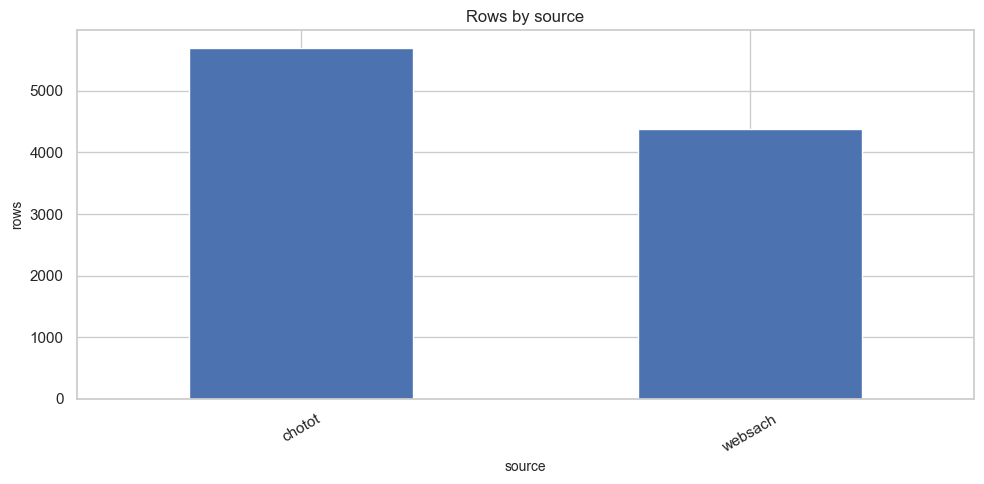

Saved figure: y:\Python\Laptop-Price-Prediction\reports\figures\eda\source_median_target_price.png


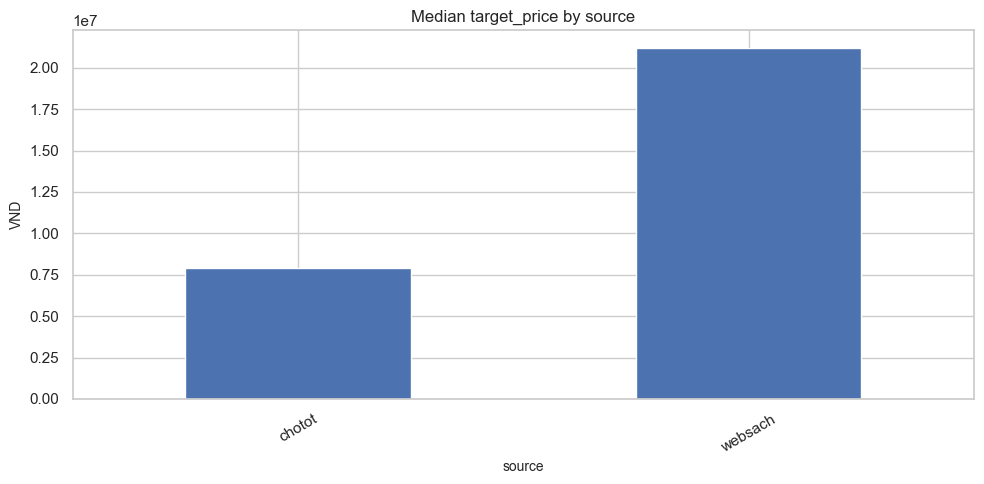

In [177]:
plt.figure(); plot_bar(source_counts["n"], "Rows by source", "rows", "source_row_count")
plt.figure(); median_by_source = price_summary_by_source.set_index("source")["median"]; plot_bar(median_by_source, "Median target_price by source", "VND", "source_median_target_price")
max_source_share = float(source_counts["pct"].max())
if max_source_share > 0.70:
    append_summary("source_composition", "source_imbalance_warning", max_source_share, notes="One source contributes more than 70% of rows.")
    print("Warning: one source contributes more than 70% of rows.")
if len(median_by_source.dropna()) >= 2:
    med_ratio = float(median_by_source.max() / median_by_source.min())
    append_summary("source_composition", "source_median_price_ratio", med_ratio)
    if med_ratio > 1.30:
        append_summary("source_composition", "source_price_shift_warning", med_ratio, notes="Median target differs by more than 30% between sources.")
        print("Warning: median target_price differs by more than 30% between sources.")

## Source Bias Check

Biểu đồ cho thấy số lượng dữ liệu giữa hai nguồn tương đối cân bằng:

- `chotot`: khoảng **5,698 dòng**
- `websach`: khoảng **4,382 dòng**

Tuy nhiên, median `target_price` giữa hai nguồn khác biệt rất lớn:

- `chotot` có median price thấp hơn rõ rệt.
- `websach` có median price cao hơn nhiều so với `chotot`.

Sự khác biệt này hợp lý vì hai nguồn có bản chất dữ liệu khác nhau:

- `chotot` chủ yếu là các tin rao bán laptop cũ hoặc đã qua sử dụng.
- `websach` chủ yếu phản ánh giá laptop mới từ shop.

Notebook cũng cảnh báo rằng median `target_price` giữa các nguồn lệch nhau hơn **30%**.
Điều này cho thấy khả năng tồn tại `source bias`.

### Decision

Khi huấn luyện model, cần cân nhắc:

- đánh giá model riêng theo từng `source`;
- kiểm tra phân phối giá sau khi train/test split;
- sử dụng biến `condition_clean` nếu có, vì tình trạng máy cũ/mới ảnh hưởng mạnh đến giá;
- cân nhắc giữ hoặc loại bỏ `source` tùy mục tiêu dự đoán.

Nếu mục tiêu là dự đoán giá thị trường chung, cần xử lý sự khác biệt giữa hai nguồn để model không bị lệch về một nguồn dữ liệu cụ thể.

## 6. Target distribution

In [178]:
display_section("Target distribution")
percentiles = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
target_desc = df[["target_price", "log_target_price"]].describe(percentiles=percentiles).T
target_skew = df[["target_price", "log_target_price"]].skew(numeric_only=True).rename("skew")
target_desc = target_desc.join(target_skew)
display(target_desc)
target_by_source = []
for src, part in df.groupby("source", dropna=False):
    desc = part[["target_price", "log_target_price"]].describe(percentiles=percentiles).T
    desc["source"] = src
    desc["skew"] = part[["target_price", "log_target_price"]].skew(numeric_only=True)
    target_by_source.append(desc.reset_index().rename(columns={"index": "column"}))
target_by_source = pd.concat(target_by_source, ignore_index=True)
display(target_by_source)


Target distribution


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew
target_price,"10,080.000","17,015,482.378","15,152,604.579","1,000,000.000","1,350,000.000","2,500,000.000","6,900,000.000","13,499,000.000","21,990,000.000","45,490,000.000","74,800,400.000","179,400,000.000",2.746
log_target_price,"10,080.000",16.311,0.862,13.816,14.116,14.732,15.747,16.418,16.906,17.633,18.130,19.005,-0.334


,column,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,source,skew
0,target_price,"5,698.000","10,078,167.952","7,922,539.147","1,000,000.000","1,200,000.000","1,900,000.000","4,700,000.000","7,890,000.000","13,000,000.000","25,990,000.000","38,490,300.000","59,900,000.000",chotot,1.943
1,log_target_price,"5,698.000",15.848,0.768,13.816,13.998,14.457,15.363,15.881,16.380,17.073,17.466,17.908,chotot,-0.208
2,target_price,"4,382.000","26,036,207.526","17,395,915.145","3,470,000.000","6,686,700.000","9,790,000.000","15,200,000.000","21,195,000.000","30,990,000.000","57,588,550.000","98,313,500.000","179,400,000.000",websach,2.646
3,log_target_price,"4,382.000",16.913,0.550,15.060,15.716,16.097,16.537,16.869,17.249,17.869,18.404,19.005,websach,0.369


## Target Price Distribution

Bảng thống kê cho thấy `target_price` có phân phối lệch phải khá mạnh:

- Tổng số quan sát hợp lệ: **10,080**
- Giá trung bình khoảng **17.0 triệu VND**
- Giá trung vị khoảng **13.5 triệu VND**
- Giá thấp nhất là **1.0 triệu VND**
- Giá cao nhất lên tới **179.4 triệu VND**
- `skew = 2.74`, cho thấy phân phối giá bị kéo lệch bởi các laptop giá rất cao.

Sau khi log-transform, `log_target_price` có phân phối ổn định hơn:

- Mean khoảng **16.31**
- Median khoảng **16.42**
- Skew giảm còn khoảng **-0.33**

Điều này cho thấy việc dùng `log_target_price` làm target khi train regression là hợp lý hơn so với dùng trực tiếp `target_price`.

## Distribution by Source

Phân phối giá giữa hai nguồn khác nhau rõ rệt:

- `chotot`: median khoảng **7.89 triệu VND**, phù hợp với đặc điểm đa số là laptop cũ hoặc đã qua sử dụng.
- `websach`: median khoảng **21.16 triệu VND**, phù hợp với đặc điểm chủ yếu là laptop mới từ shop.

Ngoài ra, `websach` có khoảng giá rộng hơn và giá cao nhất lên tới **179.4 triệu VND**, trong khi `chotot` cao nhất khoảng **59.9 triệu VND**.

## Key Insight

Dữ liệu giá có sự lệch phải mạnh và có khác biệt lớn giữa hai nguồn.
Do đó, nên sử dụng `log_target_price` để giảm ảnh hưởng của outlier và cần chú ý `source bias` khi train/test split cũng như khi đánh giá model.

Saved figure: y:\Python\Laptop-Price-Prediction\reports\figures\eda\target_price_hist.png


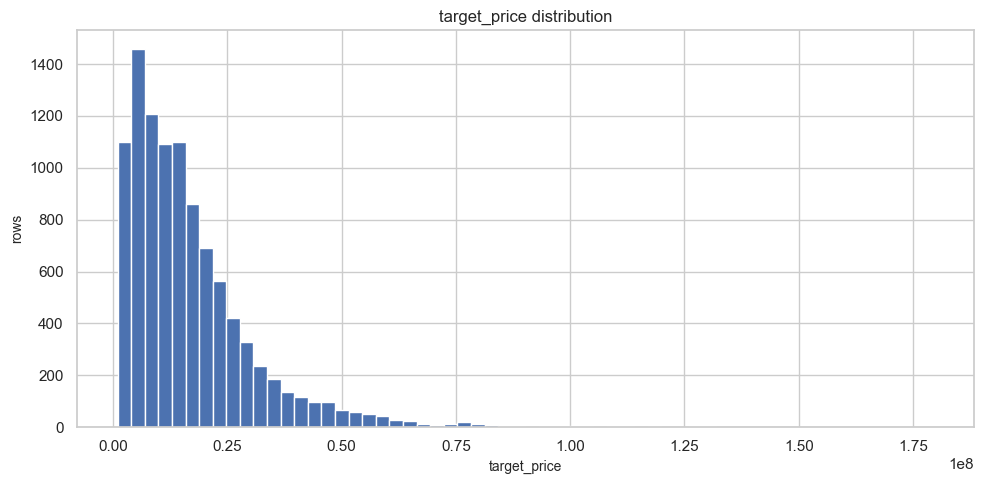

Saved figure: y:\Python\Laptop-Price-Prediction\reports\figures\eda\target_price_box_by_source.png


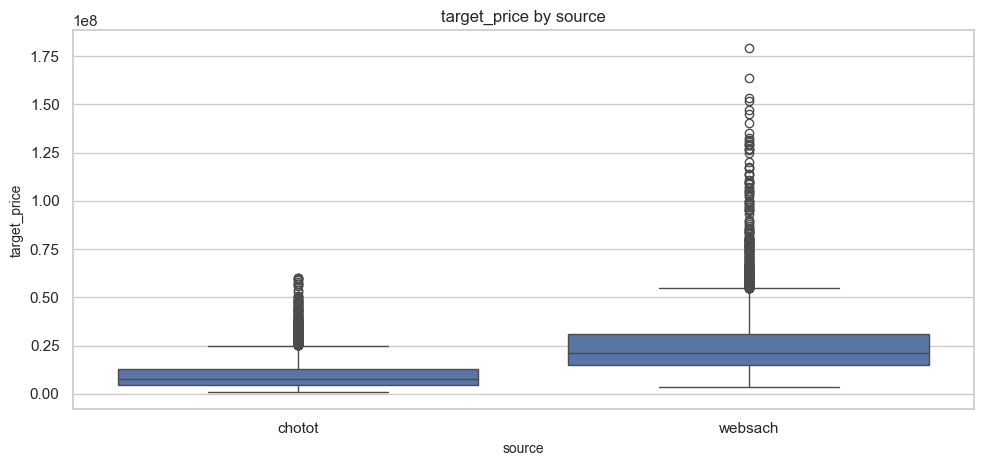

Saved figure: y:\Python\Laptop-Price-Prediction\reports\figures\eda\log_target_price_hist.png


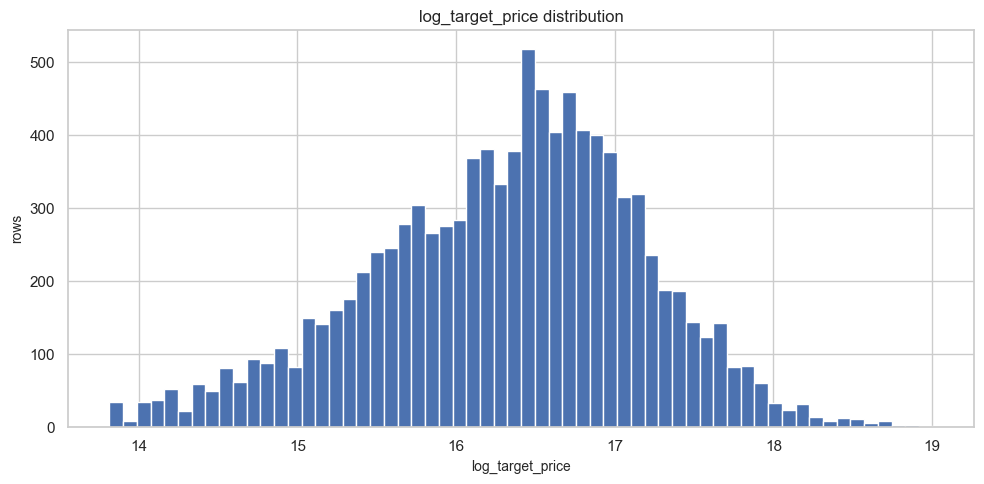

Saved figure: y:\Python\Laptop-Price-Prediction\reports\figures\eda\log_target_price_box_by_source.png


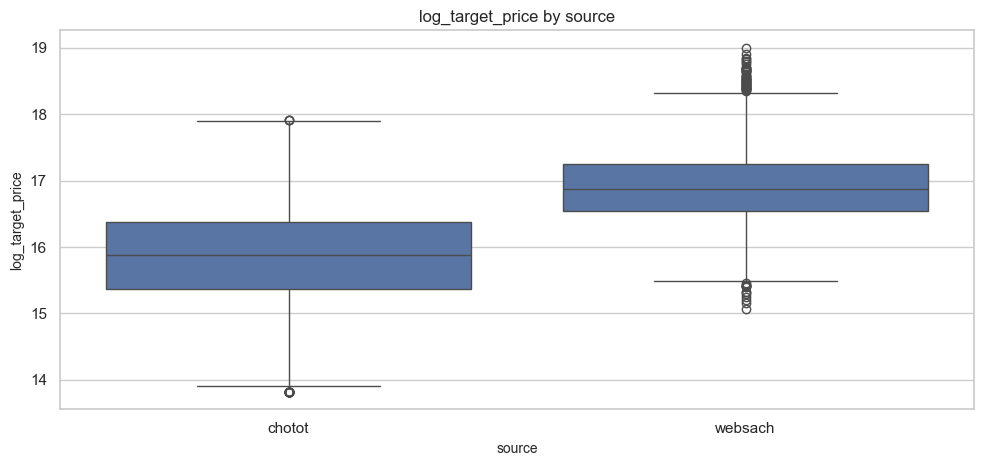

Raw target skew: 2.746
p95 / median target_price: 3.370
Recommendation: compare models on log_target_price; keep raw target for inverse-transform/reporting.
Split recommendation: stratify by source + price bin when feasible; fallback to source stratification.


In [179]:
for col in ["target_price", "log_target_price"]:
    plt.figure(); df[col].dropna().hist(bins=60); plt.title(f"{col} distribution"); plt.xlabel(col); plt.ylabel("rows"); save_current_fig(f"{col}_hist"); plt.show()
    plt.figure()
    if sns: sns.boxplot(data=df, x="source", y=col)
    else: df.boxplot(column=col, by="source")
    plt.title(f"{col} by source"); plt.suptitle(""); save_current_fig(f"{col}_box_by_source"); plt.show()
raw_skew = float(target_skew.get("target_price", np.nan))
p95_median_ratio = float(df["target_price"].quantile(0.95) / df["target_price"].median())
recommend_log_target = bool(abs(raw_skew) > 1 or p95_median_ratio > 3)
print(f"Raw target skew: {raw_skew:.3f}")
print(f"p95 / median target_price: {p95_median_ratio:.3f}")
print("Recommendation:", "compare models on log_target_price; keep raw target for inverse-transform/reporting." if recommend_log_target else "raw target is acceptable, but still keep log target for comparison.")
print("Split recommendation: stratify by source + price bin when feasible; fallback to source stratification.")
append_summary("target_distribution", "raw_target_skew", raw_skew)
append_summary("target_distribution", "p95_median_ratio", p95_median_ratio)
append_summary("target_distribution", "recommend_log_target", recommend_log_target)

## Target Price Visualization

Histogram cho thấy `target_price` bị lệch phải mạnh. Phần lớn laptop tập trung ở phân khúc giá thấp và trung bình, trong khi vẫn tồn tại một số mẫu có giá rất cao kéo dài phần đuôi bên phải của phân phối.

Boxplot theo `source` cho thấy sự khác biệt rõ rệt giữa hai nguồn:

- `chotot` có median price thấp hơn, phù hợp vì đa số là laptop cũ hoặc đã qua sử dụng.
- `websach` có median price cao hơn, phù hợp vì chủ yếu là laptop mới từ shop.
- `websach` cũng có nhiều outlier giá cao hơn, với một số laptop thuộc phân khúc cao cấp.

### Key Insight

`target_price` có nhiều outlier và phân phối không chuẩn, nên sử dụng `log_target_price` làm target sẽ phù hợp hơn cho mô hình regression.
Ngoài ra, sự khác biệt giữa `chotot` và `websach` cho thấy cần chú ý `source bias` khi chia train/test và đánh giá model.

## Log Target Price Visualization

Sau khi log-transform, phân phối `log_target_price` trở nên cân đối hơn nhiều so với `target_price` ban đầu.
Histogram cho thấy dữ liệu tập trung rõ hơn quanh vùng trung tâm và phần đuôi phải đã được giảm đáng kể.

Boxplot theo `source` vẫn cho thấy sự khác biệt giữa hai nguồn:

- `chotot` có median `log_target_price` thấp hơn, phù hợp vì đa số là laptop cũ.
- `websach` có median `log_target_price` cao hơn, phù hợp vì chủ yếu là laptop mới từ shop.
- Outlier vẫn tồn tại, nhưng mức độ cực đoan đã giảm sau khi log-transform.

### Key Insight

`log_target_price` phù hợp hơn để làm target cho regression vì giúp giảm skewness và ảnh hưởng của outlier.
Tuy nhiên, khác biệt giữa `chotot` và `websach` vẫn còn rõ, nên cần tiếp tục kiểm soát `source bias` khi train/test split và đánh giá model.

## 6a. Price segment analysis


Price segment analysis


,source,price_segment_eda,n,median_target_price,median_ram_gb,median_storage_gb,median_screen_size_inch
0,chotot,high,616,"19,000,000.000",16.000,512.000,15.950
1,chotot,low,2004,"3,800,000.000",8.000,256.000,13.950
2,chotot,mid_high,1034,"12,900,000.000",16.000,512.000,15.950
3,chotot,mid_low,1711,"7,900,000.000",8.000,256.000,13.950
4,chotot,premium,333,"29,900,000.000",16.000,"1,024.000",15.950
5,websach,high,1400,"19,965,000.000",8.000,512.000,14.000
6,websach,low,28,"5,243,500.000",4.000,500.000,14.000
7,websach,mid_high,981,"13,800,000.000",8.000,512.000,14.300
8,websach,mid_low,290,"9,325,000.000",4.000,500.000,14.000
9,websach,premium,1683,"35,350,000.000",16.000,512.000,15.600


price_segment_eda,high,low,mid_high,mid_low,premium
source,,,,,
chotot,0.108,0.352,0.181,0.300,0.058
websach,0.319,0.006,0.224,0.066,0.384


Saved figure: y:\Python\Laptop-Price-Prediction\reports\figures\eda\price_segment_distribution_by_source.png


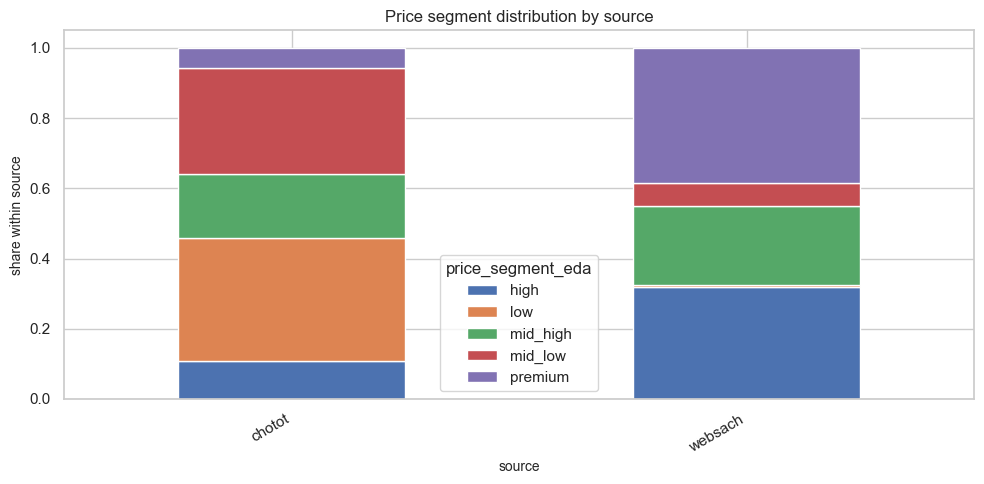

In [180]:
display_section("Price segment analysis")

price_segment_labels = ["low", "mid_low", "mid_high", "high", "premium"]
eda_df = eda_df.copy() if "eda_df" in globals() else df.copy()
if "target_price" in eda_df:
    try:
        eda_df["price_segment_eda"] = pd.qcut(eda_df["target_price"], q=len(price_segment_labels), labels=price_segment_labels, duplicates="drop")
    except ValueError:
        eda_df["price_segment_eda"] = pd.cut(eda_df["target_price"], bins=len(price_segment_labels), labels=price_segment_labels)
    eda_df["price_segment_eda"] = eda_df["price_segment_eda"].astype("object").fillna("Unknown")

price_segment_numeric = [c for c in ["ram_gb", "storage_gb", "screen_size_inch"] if c in eda_df]
agg_spec = {"n": ("target_price", "size"), "median_target_price": ("target_price", "median")}
for col in price_segment_numeric:
    agg_spec[f"median_{col}"] = (col, "median")
price_segment_summary = eda_df.groupby(["source", "price_segment_eda"], dropna=False).agg(**agg_spec).reset_index()
display(price_segment_summary)
append_summary("price_segment", "price_segment_summary", price_segment_summary.to_dict("records"))

price_segment_dist = pd.crosstab(eda_df["source"], eda_df["price_segment_eda"], normalize="index")
display(price_segment_dist)
plt.figure(figsize=(10, 5))
price_segment_dist.plot(kind="bar", stacked=True, ax=plt.gca())
plt.title("Price segment distribution by source")
plt.ylabel("share within source")
plt.xticks(rotation=30, ha="right")
save_current_fig("price_segment_distribution_by_source")
plt.show()

source_segment_min = int(pd.crosstab(eda_df["source"], eda_df["price_segment_eda"]).min().min())

## Price Segment by Source

Biểu đồ cho thấy phân phối phân khúc giá khác nhau rõ rệt giữa hai nguồn dữ liệu.

`chotot` có tỷ trọng lớn ở các phân khúc `low` và `mid_low`, phù hợp vì nguồn này chủ yếu là laptop cũ hoặc tin rao cá nhân. Ngược lại, `websach` có tỷ trọng cao hơn ở các phân khúc `high` và `premium`, phù hợp vì nguồn này chủ yếu là laptop mới từ shop.

Điều này cho thấy khả năng tồn tại `source bias`: model có thể học sự khác biệt theo nguồn dữ liệu thay vì chỉ học từ cấu hình laptop. Vì vậy, khi train/test split nên stratify theo `source` và `price_segment`, đồng thời đánh giá model riêng theo từng nguồn.

## 6b. Extreme price examples / outlier inspection

In [181]:
display_section("Extreme price examples / outlier inspection")
extreme_cols = [c for c in ["source", "brand_grouped", "brand_clean", "model_grouped", "model_clean", "cpu_tier", "gpu_tier", "ram_gb", "storage_gb", "screen_size_inch", "condition_clean", "warranty_status", "target_price", "log_target_price", "title", "url"] if c in df.columns]
extreme_low = df.sort_values("target_price", ascending=True)[extreme_cols].head(20)
extreme_high = df.sort_values("target_price", ascending=False)[extreme_cols].head(20)
print("Top 20 lowest target_price rows")
display(extreme_low)
print("Top 20 highest target_price rows")
display(extreme_high)
append_summary("extreme_price_examples", "lowest_prices", extreme_low[[c for c in ["source", "brand_grouped", "model_grouped", "target_price"] if c in extreme_low]].to_dict("records"))
append_summary("extreme_price_examples", "highest_prices", extreme_high[[c for c in ["source", "brand_grouped", "model_grouped", "target_price"] if c in extreme_high]].to_dict("records"))

low_sources = extreme_low["source"].value_counts().to_dict() if "source" in extreme_low else {}
high_sources = extreme_high["source"].value_counts().to_dict() if "source" in extreme_high else {}


Extreme price examples / outlier inspection
Top 20 lowest target_price rows


,source,brand_grouped,brand_clean,model_grouped,model_clean,cpu_tier,gpu_tier,ram_gb,storage_gb,screen_size_inch,condition_clean,warranty_status,target_price,log_target_price,title,url
3961,chotot,Apple,Apple,MacBook Air,MacBook Air,Missing,Missing,4.000,127.000,13.950,Đã sử dụng (chưa sửa chữa),Manufacturer,"1,000,000.000",13.816,Apple MacBook Air 13 inch 4GB/120GB,https://www.chotot.com/mua-ban-huyen-nha-be-tp...
1821,chotot,Sony,Sony,Other,Vaio Series,Other,Integrated - Intel,4.000,250.000,NaN,Đã sử dụng (chưa sửa chữa),Active,"1,000,000.000",13.816,Laptop Sony Vaio Core 2 Duo 4GB/250GB,https://www.chotot.com/mua-ban-quan-12-tp-ho-c...
1434,chotot,HP,HP,Dòng Khác,Dòng Khác,Entry,Missing,4.000,NaN,NaN,Đã sử dụng (chưa sửa chữa),Manufacturer,"1,000,000.000",13.816,HP 15-BS0XX i3-7020U 4GB Bạc,https://www.chotot.com/mua-ban-thanh-pho-bien-...
3208,chotot,Sony,Sony,Other,Vaio Series,Entry,Integrated - Intel,4.000,127.000,NaN,Đã sử dụng (chưa sửa chữa),Expired,"1,000,000.000",13.816,Sony Vaio i3 4GB/148GB Đen,https://www.chotot.com/mua-ban-quan-ba-dinh-ha...
4531,chotot,Lenovo,Lenovo,IdeaPad,IdeaPad,Missing,Missing,NaN,NaN,NaN,Đã sử dụng (chưa sửa chữa),Manufacturer,"1,000,000.000",13.816,cần pass lap lenovo 1tr,https://www.chotot.com/mua-ban-quan-tay-ho-ha-...
1836,chotot,HP,HP,Dòng Khác,Dòng Khác,Low,Integrated - Intel,4.000,500.000,13.950,Đã sử dụng (chưa sửa chữa),Manufacturer,"1,000,000.000",13.816,HP CQ42 Pentium 14 inch 4GB/500GB,https://www.chotot.com/mua-ban-quan-4-tp-ho-ch...
4821,chotot,Dell,Dell,Other,Inspiron 14,Mid,Missing,8.000,NaN,NaN,Đã sử dụng (chưa sửa chữa),Manufacturer,"1,000,000.000",13.816,Dell Inspiron i5 2430 Ram 8GB,https://www.chotot.com/mua-ban-quan-6-tp-ho-ch...
4833,chotot,Acer,Acer,Aspire,Aspire,Mid,Unclear,4.000,250.000,NaN,Đã sử dụng (chưa sửa chữa),Manufacturer,"1,000,000.000",13.816,Acer Aspire E1-572G i5-4200U 4GB/250GB,https://www.chotot.com/mua-ban-quan-thanh-khe-...
3820,chotot,Dell,Dell,Other,Alienware,Other,Unclear,4.000,127.000,11.950,Đã sử dụng (chưa sửa chữa),Expired,"1,000,000.000",13.816,Dell Laptop Đen,https://www.chotot.com/mua-ban-huyen-phu-vang-...
4467,chotot,Other,Samsung,Other,Notebook 5,Mid,Dedicated - Other/Entry,8.000,127.000,15.950,Đã sử dụng (chưa sửa chữa),Manufacturer,"1,000,000.000",13.816,Samsung NT500R5K i5-5200U 15.6 inch 8GB 256GB,https://www.chotot.com/mua-ban-thanh-pho-thu-d...


Top 20 highest target_price rows


,source,brand_grouped,brand_clean,model_grouped,model_clean,cpu_tier,gpu_tier,ram_gb,storage_gb,screen_size_inch,condition_clean,warranty_status,target_price,log_target_price,title,url
6300,websach,Apple,Apple,Unknown,Unknown,High-end,Apple GPU,128.000,"8,192.000",16.000,Unknown,Unknown,"179,400,000.000",19.005,NaN,NaN
9072,websach,MSI,MSI,Unknown,Unknown,High-end,RTX 5000,96.000,"6,144.000",18.000,Unknown,Unknown,"163,790,000.000",18.914,NaN,NaN
6979,websach,MSI,MSI,Unknown,Unknown,High-end,RTX 5000,64.000,"6,144.000",18.000,Unknown,Unknown,"153,290,000.000",18.848,NaN,NaN
7115,websach,Apple,Apple,Unknown,Unknown,High-end,Apple GPU,128.000,"4,096.000",16.200,Unknown,Unknown,"151,890,000.000",18.839,NaN,NaN
9709,websach,MSI,MSI,Unknown,Unknown,High-end,RTX 4000,128.000,"4,096.000",18.000,Unknown,Unknown,"146,990,000.000",18.806,NaN,NaN
6679,websach,Acer,Acer,Unknown,Unknown,High-end,RTX 5000,192.000,"6,144.000",18.000,Unknown,Unknown,"144,990,000.000",18.792,NaN,NaN
7569,websach,Apple,Apple,Unknown,Unknown,High-end,Apple GPU,128.000,"4,096.000",14.000,Unknown,Unknown,"140,190,000.000",18.759,NaN,NaN
6726,websach,Apple,Apple,Unknown,Unknown,High-end,Apple GPU,128.000,"2,048.000",16.000,Unknown,Unknown,"135,000,000.000",18.721,NaN,NaN
9726,websach,HP,HP,Unknown,Unknown,High-end,Other RTX,32.000,"1,024.000",16.000,Unknown,Unknown,"132,580,000.000",18.703,NaN,NaN
9870,websach,MSI,MSI,Unknown,Unknown,High-end,RTX 5000,64.000,"4,096.000",18.000,Unknown,Unknown,"131,690,000.000",18.696,NaN,NaN


## Extreme Target Price Rows Check

Khi kiểm tra các dòng có `target_price` thấp nhất và cao nhất, có thể thấy hai nhóm cực trị có đặc điểm khá khác nhau.

### Lowest Price Rows

Nhóm giá thấp nhất chủ yếu đến từ `chotot`, với `target_price` khoảng **1,000,000 VND**.
Các dòng này đa số là laptop đã qua sử dụng, nhiều máy có cấu hình cũ hoặc thông tin thiếu như `gpu_tier`, `storage_gb`, `screen_size_inch`.

Điều này khá hợp lý vì `chotot` chủ yếu là thị trường laptop cũ. Tuy nhiên, vẫn cần kiểm tra kỹ vì một số dòng có thể là máy lỗi, máy cần sửa chữa, hoặc tin rao không đầy đủ thông tin.

### Highest Price Rows

Nhóm giá cao nhất chủ yếu đến từ `websach`.
Các dòng này thường có cấu hình rất cao như RAM **64GB - 192GB**, storage lớn, CPU `High-end`, GPU `RTX 4000`, `RTX 5000` hoặc `Apple GPU`.

Điều này phù hợp với đặc điểm `websach` là nguồn laptop mới từ shop, trong đó có nhiều mẫu cao cấp hoặc workstation.

### Key Insight

Các giá trị cực trị không nhất thiết là lỗi dữ liệu, vì chúng phản ánh hai phân khúc khác nhau: laptop cũ giá thấp từ `chotot` và laptop cao cấp giá cao từ `websach`.

Tuy nhiên, các dòng cực trị vẫn nên được kiểm tra kỹ trước khi train model, đặc biệt là những dòng có nhiều feature bị `Missing` hoặc `Unknown`.
Có thể giữ lại nếu chúng hợp lý về mặt cấu hình, nhưng nên train với `log_target_price` để giảm ảnh hưởng của outlier.

## 7. Missing and Unknown analysis

In [182]:
display_section("Missing and Unknown analysis")
missing_cols = existing_numeric_candidates + existing_categorical_candidates + existing_boolean_candidates + [c for c in ["title", "url", "merged_spec_key"] if c in df]
missing_rows = []
for col in missing_cols:
    row = {"column": col, "overall_missing_like_rate": missing_like_rate(df[col])}
    for src, part in df.groupby("source", dropna=False):
        row[f"missing_like_rate_{src}"] = missing_like_rate(part[col])
    source_rates = [v for k, v in row.items() if k.startswith("missing_like_rate_")]
    row["max_source_missing_like_rate"] = max(source_rates) if source_rates else row["overall_missing_like_rate"]
    missing_rows.append(row)
missing_table = pd.DataFrame(missing_rows).sort_values("overall_missing_like_rate", ascending=False)
missing_by_source_table = missing_table.sort_values("max_source_missing_like_rate", ascending=False)
display(missing_table)
display(missing_by_source_table.head(25))
append_summary("missingness", "highest_missing_like_columns", missing_table.head(10).set_index("column")["overall_missing_like_rate"].to_dict())


Missing and Unknown analysis


,column,overall_missing_like_rate,missing_like_rate_chotot,missing_like_rate_websach,max_source_missing_like_rate
14,origin_clean,0.772,0.596,1.000,1.000
3,warranty_months,0.757,0.571,1.000,1.000
16,model_is_rare,0.435,0.000,1.000,1.000
31,url,0.435,0.000,1.000,1.000
30,title,0.435,0.000,1.000,1.000
6,model_clean,0.435,0.000,1.000,1.000
7,model_grouped,0.435,0.000,1.000,1.000
12,condition_clean,0.435,0.000,1.000,1.000
13,warranty_status,0.435,0.000,1.000,1.000
10,gpu_tier,0.150,0.229,0.047,0.229


,column,overall_missing_like_rate,missing_like_rate_chotot,missing_like_rate_websach,max_source_missing_like_rate
14,origin_clean,0.772,0.596,1.000,1.000
3,warranty_months,0.757,0.571,1.000,1.000
16,model_is_rare,0.435,0.000,1.000,1.000
31,url,0.435,0.000,1.000,1.000
30,title,0.435,0.000,1.000,1.000
6,model_clean,0.435,0.000,1.000,1.000
7,model_grouped,0.435,0.000,1.000,1.000
12,condition_clean,0.435,0.000,1.000,1.000
13,warranty_status,0.435,0.000,1.000,1.000
10,gpu_tier,0.150,0.229,0.047,0.229


## Missingness by Source

Bảng trên kiểm tra tỷ lệ missing-like value theo từng cột và từng nguồn dữ liệu.

### Key Findings

- Một số cột bị thiếu hoàn toàn ở `websach`, ví dụ: `url`, `title`, `model_clean`, `model_grouped`, `condition_clean`, `warranty_status`.
- `origin_clean` và `warranty_months` có missing rate rất cao ở cả hai nguồn, đặc biệt là `websach` với tỷ lệ missing **100%**.
- Các feature kỹ thuật quan trọng như `ram_gb`, `storage_gb`, `cpu_brand`, `cpu_tier`, `storage_type_clean` có missing rate tương đối thấp.
- `gpu_tier` thiếu nhiều hơn ở `chotot` so với `websach`, cho thấy dữ liệu GPU từ tin rao cá nhân khó trích xuất hơn.
- Một số flag như `ram_missing`, `storage_missing`, `cpu_missing`, `gpu_missing`, `*_suspicious` không bị missing vì chúng là biến đánh dấu đã được tạo trong quá trình cleaning.

### Key Insight

Missing value có tính hệ thống theo nguồn dữ liệu.
Điều này cho thấy sự khác biệt schema giữa `chotot` và `websach`, không chỉ là missing ngẫu nhiên.

Khi train model, cần xử lý missing theo từng loại biến và cân nhắc đánh giá model riêng theo từng nguồn để tránh ảnh hưởng của `source bias`.

Saved figure: y:\Python\Laptop-Price-Prediction\reports\figures\eda\missing_like_top20_overall.png


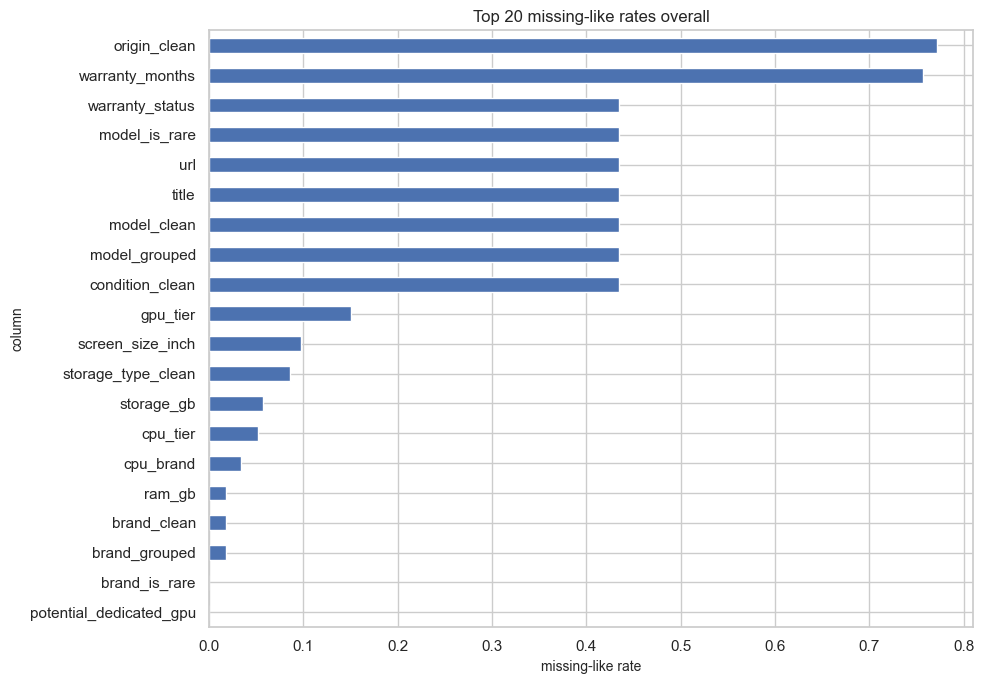

,missing_like_rate_chotot,missing_like_rate_websach
column,,
origin_clean,0.596,1.000
model_grouped,0.000,1.000
condition_clean,0.000,1.000
warranty_status,0.000,1.000
gpu_tier,0.229,0.047
screen_size_inch,0.157,0.022
storage_type_clean,0.113,0.051
storage_gb,0.062,0.051
cpu_tier,0.031,0.081


Saved figure: y:\Python\Laptop-Price-Prediction\reports\figures\eda\missing_like_by_source_key_columns.png


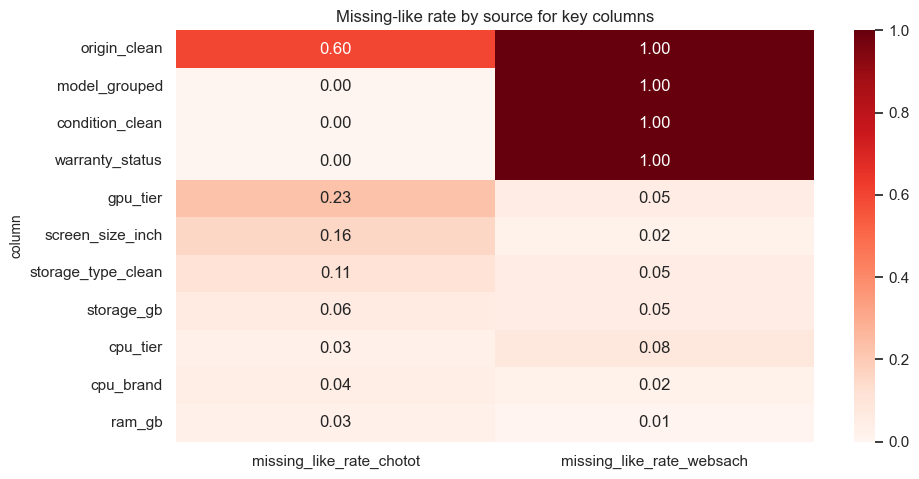

Interpretation: Unknown-heavy condition/warranty/origin in Websach is source-design missingness. Numeric spec gaps should be imputed, and missing flags are useful only if they vary beyond pure source identity.


In [183]:
plt.figure(figsize=(10, 7)); missing_table.head(20).sort_values("overall_missing_like_rate").plot.barh(x="column", y="overall_missing_like_rate", legend=False, ax=plt.gca()); plt.title("Top 20 missing-like rates overall"); plt.xlabel("missing-like rate"); save_current_fig("missing_like_top20_overall"); plt.show()
key_missing_cols = [c for c in ["ram_gb", "storage_gb", "screen_size_inch", "cpu_brand", "cpu_tier", "gpu_tier", "storage_type_clean", "condition_clean", "warranty_status", "origin_clean", "model_grouped"] if c in df]
source_rate_cols = [c for c in missing_table.columns if c.startswith("missing_like_rate_")]
key_missing_by_source = missing_table[missing_table["column"].isin(key_missing_cols)].set_index("column")[source_rate_cols]
display(key_missing_by_source)
plt.figure(figsize=(10, max(4, 0.45 * len(key_missing_by_source))))
if sns:
    sns.heatmap(key_missing_by_source, annot=True, fmt=".2f", cmap="Reds", vmin=0, vmax=1)
else:
    plt.imshow(key_missing_by_source, aspect="auto", cmap="Reds", vmin=0, vmax=1); plt.yticks(range(len(key_missing_by_source)), key_missing_by_source.index); plt.xticks(range(len(source_rate_cols)), source_rate_cols, rotation=30); plt.colorbar()
plt.title("Missing-like rate by source for key columns"); save_current_fig("missing_like_by_source_key_columns"); plt.show()
print("Interpretation: Unknown-heavy condition/warranty/origin in Websach is source-design missingness. Numeric spec gaps should be imputed, and missing flags are useful only if they vary beyond pure source identity.")

## Missing-like Rate by Source

Các biểu đồ cho thấy missing-like values không phân bố ngẫu nhiên mà phụ thuộc rõ vào `source`.

### Key Findings

- `origin_clean` thiếu rất cao ở cả hai nguồn, đặc biệt `websach` là **100%**.
- Một số cột như `model_grouped`, `condition_clean`, `warranty_status` không thiếu ở `chotot` nhưng thiếu **100%** ở `websach`.
- Điều này cho thấy đây là **source-design missingness**, tức là do khác biệt schema/cách thu thập dữ liệu giữa hai nguồn.
- Các cột cấu hình số như `ram_gb`, `storage_gb`, `screen_size_inch` có missing rate thấp hơn, nhưng vẫn cần impute trước khi train.
- `gpu_tier` thiếu nhiều hơn ở `chotot`, có thể do tin rao cá nhân thường không ghi rõ GPU.

### Key Insight

Missingness trong dataset mang tính hệ thống theo nguồn dữ liệu.
Vì vậy, cần xử lý missing theo loại biến và theo ý nghĩa dữ liệu, thay vì coi tất cả missing là ngẫu nhiên.

### Decision

- Các biến thiếu 100% ở một nguồn như `condition_clean`, `warranty_status`, `model_grouped` cần được cân nhắc kỹ trước khi dùng.
- Numeric features như `ram_gb`, `storage_gb`, `screen_size_inch` nên được impute bằng median.
- Categorical features có thể fill bằng `"Unknown"`.
- Missing flags chỉ thực sự hữu ích nếu chúng không chỉ phản ánh `source`, mà còn mang thông tin thêm về chất lượng dữ liệu hoặc cấu hình laptop.

## 7a. Feature coverage by source


Feature coverage by source


,feature,coverage_overall,coverage_chotot,coverage_websach,min_source_coverage,low_coverage_flag
12,origin_clean,0.228,0.404,0.000,0.000,True
3,warranty_months,0.243,0.429,0.000,0.000,True
5,model_grouped,0.565,1.000,0.000,0.000,True
10,condition_clean,0.565,1.000,0.000,0.000,True
11,warranty_status,0.565,1.000,0.000,0.000,True
14,model_is_rare,0.565,1.000,0.000,0.000,True
8,gpu_tier,0.850,0.771,0.953,0.771,False
2,screen_size_inch,0.902,0.843,0.978,0.843,False
9,storage_type_clean,0.914,0.887,0.949,0.887,False
7,cpu_tier,0.948,0.969,0.919,0.919,False


Saved figure: y:\Python\Laptop-Price-Prediction\reports\figures\eda\baseline_feature_coverage_by_source.png


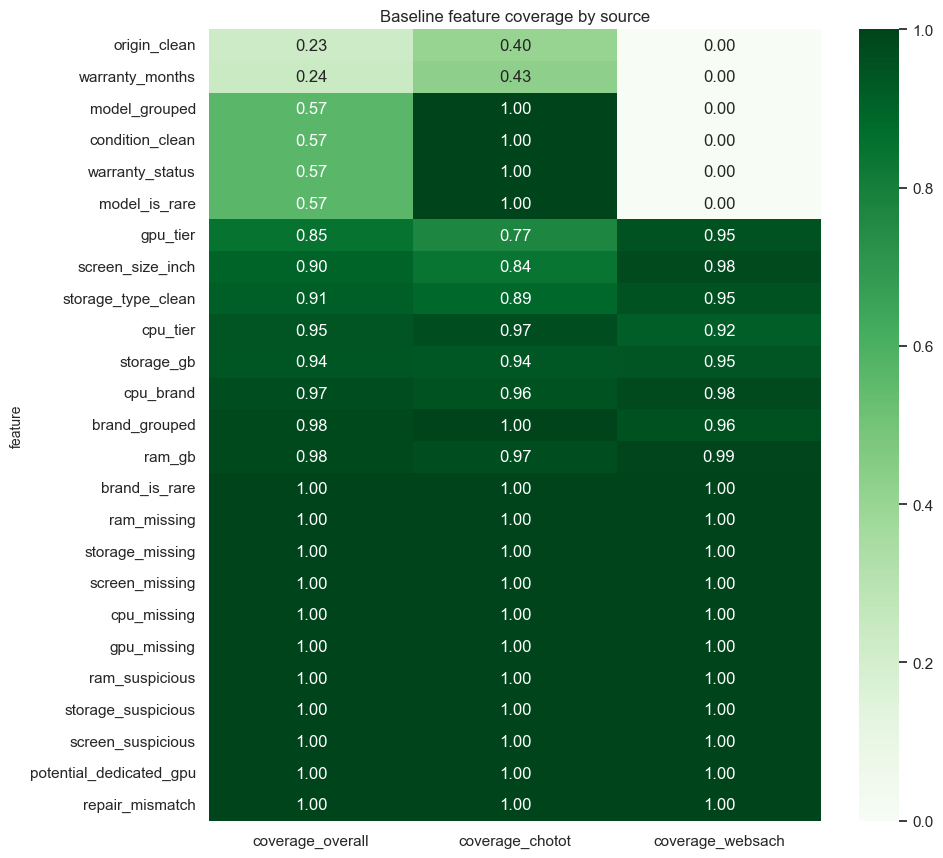

In [184]:
display_section("Feature coverage by source")

baseline_candidate_features = [c for c in (existing_numeric_candidates + [x for x in ["brand_grouped", "model_grouped", "cpu_brand", "cpu_tier", "gpu_tier", "storage_type_clean", "condition_clean", "warranty_status", "origin_clean"] if x in df.columns] + [x for x in ["brand_is_rare", "model_is_rare", "ram_missing", "storage_missing", "screen_missing", "cpu_missing", "gpu_missing", "ram_suspicious", "storage_suspicious", "screen_suspicious", "potential_dedicated_gpu", "repair_mismatch", "is_soft_duplicate_spec"] if x in df.columns]) if c in df.columns]
coverage_rows = []
for col in baseline_candidate_features:
    row = {"feature": col, "coverage_overall": 1 - missing_like_rate(df[col])}
    for src, part in df.groupby("source", dropna=False):
        row[f"coverage_{src}"] = 1 - missing_like_rate(part[col])
    source_cov = [v for k, v in row.items() if k.startswith("coverage_") and k != "coverage_overall"]
    row["min_source_coverage"] = min(source_cov) if source_cov else row["coverage_overall"]
    row["low_coverage_flag"] = row["coverage_overall"] < 0.50 or row["min_source_coverage"] < 0.50
    coverage_rows.append(row)
feature_coverage = pd.DataFrame(coverage_rows).sort_values(["low_coverage_flag", "min_source_coverage", "coverage_overall"], ascending=[False, True, True])
display(feature_coverage)
low_coverage_features = feature_coverage.loc[feature_coverage["low_coverage_flag"], "feature"].tolist()
append_summary("feature_coverage", "low_coverage_features", low_coverage_features)

coverage_plot = feature_coverage.head(25).set_index("feature")[[c for c in feature_coverage.columns if c.startswith("coverage_")]]
plt.figure(figsize=(10, max(5, 0.35 * len(coverage_plot))))
if sns:
    sns.heatmap(coverage_plot, annot=True, fmt=".2f", cmap="Greens", vmin=0, vmax=1)
else:
    plt.imshow(coverage_plot, aspect="auto", cmap="Greens", vmin=0, vmax=1)
    plt.yticks(range(len(coverage_plot)), coverage_plot.index)
    plt.xticks(range(len(coverage_plot.columns)), coverage_plot.columns, rotation=30)
    plt.colorbar()
plt.title("Baseline feature coverage by source")
save_current_fig("baseline_feature_coverage_by_source")
plt.show()

## Baseline Feature Coverage

Bảng và heatmap trên kiểm tra độ phủ dữ liệu của các feature chính theo từng nguồn.

### Key Findings

- Một số feature có coverage rất thấp hoặc bằng **0%** ở `websach`, gồm `origin_clean`, `warranty_months`, `model_grouped`, `condition_clean`, `warranty_status`, `model_is_rare`.
- Điều này cho thấy các cột này không phù hợp để dùng trực tiếp trong baseline model chung cho cả hai nguồn.
- Các feature cấu hình quan trọng như `ram_gb`, `storage_gb`, `screen_size_inch`, `cpu_brand`, `cpu_tier`, `storage_type_clean`, `gpu_tier` có coverage khá tốt ở cả hai nguồn.
- Các biến flag như `ram_missing`, `storage_missing`, `cpu_missing`, `gpu_missing`, `*_suspicious`, `potential_dedicated_gpu` có coverage **100%** vì được tạo sau bước cleaning.

### Decision

Baseline model nên ưu tiên các feature có coverage ổn định ở cả hai nguồn, ví dụ:

`brand_grouped`, `ram_gb`, `storage_gb`, `screen_size_inch`, `cpu_brand`, `cpu_tier`, `gpu_tier`, `storage_type_clean`.

Các feature có coverage bằng **0%** ở một nguồn nên được loại khỏi baseline hoặc chỉ dùng trong mô hình riêng theo từng nguồn.

## 8. Numeric feature EDA

Ta chỉ xem xét các biến Numeric đã chọn, "warranty_months" đã được khảo sát là không gây ảnh hưởng và tc động yếu đến target nên ta bỏ qua nó.

In [185]:
def run_numeric_eda_for_col(df, col, source_col="source", bins=40):
    display_section(f"Numeric feature EDA: {col}")

    display(
        df[col]
        .describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
        .to_frame(col)
    )

    display(numeric_summary_by_group(df, col, source_col))

    plt.figure()
    df[col].dropna().hist(bins=bins)
    plt.title(f"{col} distribution")
    plt.xlabel(col)
    plt.ylabel("rows")
    save_current_fig(f"numeric_{col}_hist")
    plt.show()

    plt.figure()
    if sns:
        sns.boxplot(data=df, x=source_col, y=col)
    else:
        df.boxplot(column=col, by=source_col)

    plt.title(f"{col} by {source_col}")
    plt.suptitle("")
    plt.xlabel(source_col)
    plt.ylabel(col)
    save_current_fig(f"numeric_{col}_box_by_{source_col}")
    plt.show()


Numeric feature EDA: ram_gb


,ram_gb
count,"9,899.000"
mean,13.603
std,9.604
min,2.000
5%,4.000
25%,8.000
50%,16.000
75%,16.000
95%,32.000
max,192.000


,source,count,mean,median,std,min,p05,p25,p75,p95,max
0,chotot,5540,12.760,8.000,7.049,2.000,4.000,8.000,16.000,32.000,64.000
1,websach,4359,14.674,16.000,12.012,2.000,4.000,8.000,16.000,32.000,192.000


Saved figure: y:\Python\Laptop-Price-Prediction\reports\figures\eda\numeric_ram_gb_hist.png


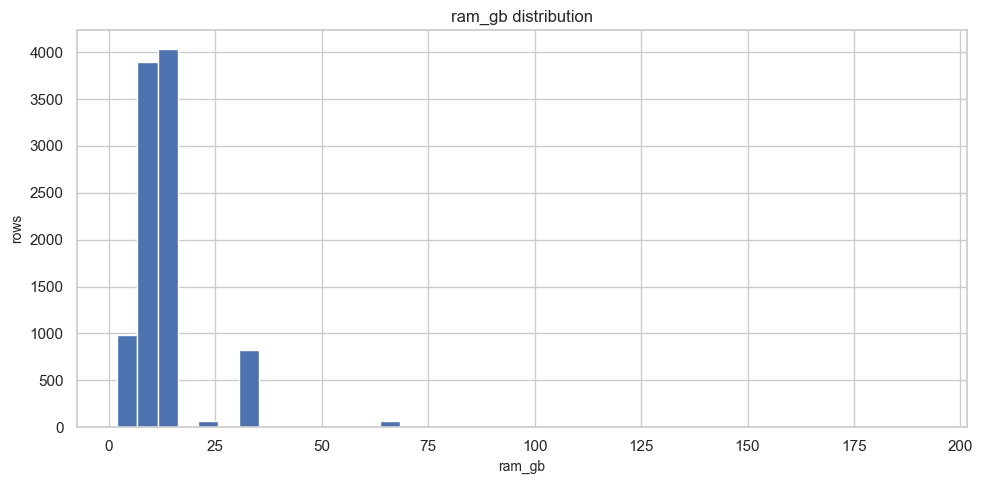

Saved figure: y:\Python\Laptop-Price-Prediction\reports\figures\eda\numeric_ram_gb_box_by_source.png


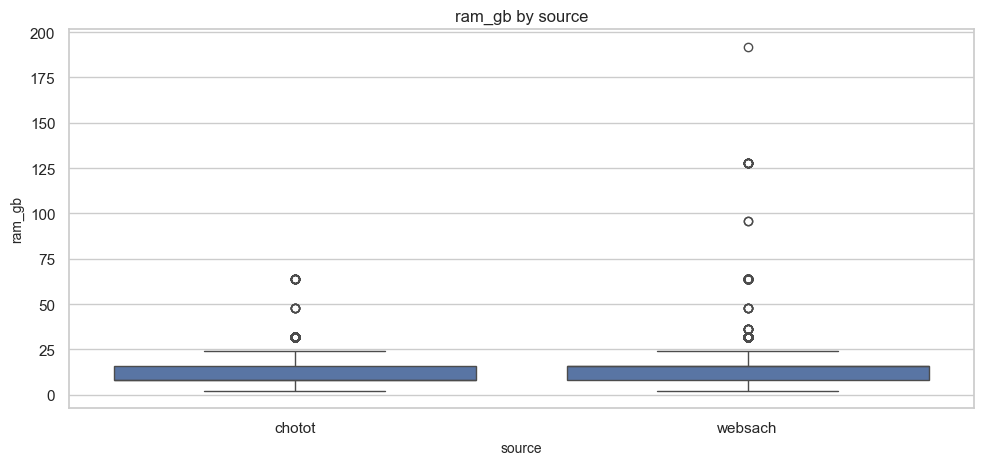

In [186]:
run_numeric_eda_for_col(df, "ram_gb")

## Numeric EDA: `ram_gb`

`ram_gb` có **9,899** giá trị hợp lệ, trung vị là **16GB**, trong khi mean khoảng **13.6GB**. Phần lớn laptop tập trung ở các mức RAM phổ biến như **8GB** và **16GB**.

Theo nguồn dữ liệu:

- `chotot` có median RAM là **8GB**
- `websach` có median RAM là **16GB**

Điều này phù hợp với đặc điểm dữ liệu: `chotot` chủ yếu là laptop cũ, còn `websach` chủ yếu là laptop mới nên cấu hình RAM thường cao hơn.

Boxplot cũng cho thấy có một số outlier RAM rất cao, đặc biệt ở `websach` với giá trị tối đa lên tới **192GB**. Các giá trị này có thể là laptop workstation hoặc máy cấu hình cao, nhưng vẫn nên kiểm tra thêm trước khi train model.

### Decision

`ram_gb` là feature quan trọng và có coverage tốt, nên giữ lại cho model.
Tuy nhiên, cần xử lý outlier hợp lý, ví dụ kiểm tra các giá trị RAM quá cao hoặc dùng model ít nhạy với outlier.


Numeric feature EDA: storage_gb


,storage_gb
count,"9,503.000"
mean,503.827
std,356.089
min,16.000
5%,128.000
25%,256.000
50%,512.000
75%,512.000
95%,"1,024.000"
max,"8,192.000"


,source,count,mean,median,std,min,p05,p25,p75,p95,max
0,chotot,5346,391.727,256.000,226.633,127.000,127.000,256.000,512.000,"1,024.000","1,025.000"
1,websach,4157,647.990,512.000,432.315,16.000,256.000,512.000,"1,024.000","1,024.000","8,192.000"


Saved figure: y:\Python\Laptop-Price-Prediction\reports\figures\eda\numeric_storage_gb_hist.png


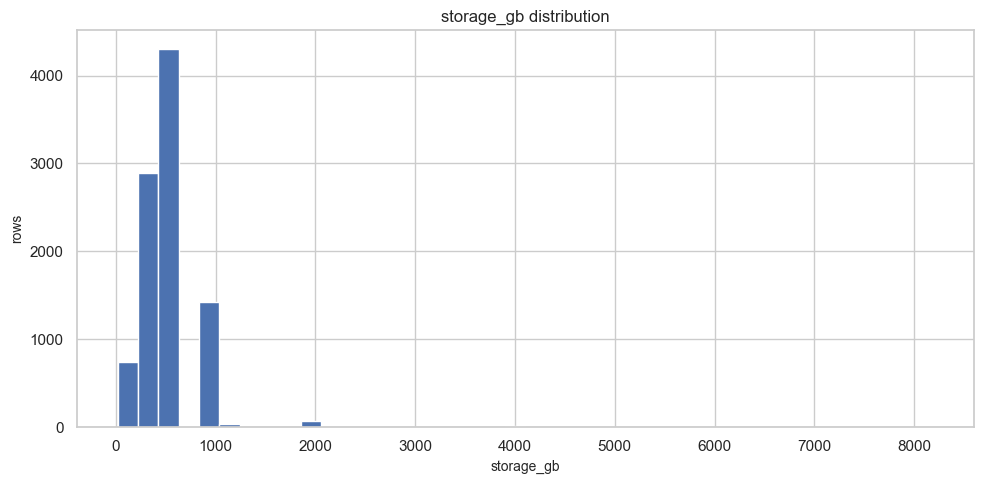

Saved figure: y:\Python\Laptop-Price-Prediction\reports\figures\eda\numeric_storage_gb_box_by_source.png


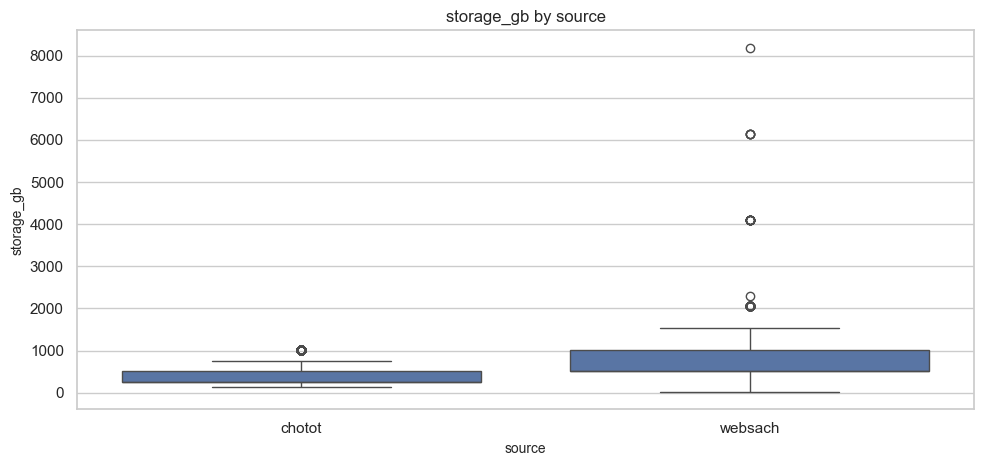

In [187]:
run_numeric_eda_for_col(df, "storage_gb")

## Numeric EDA: `storage_gb`

`storage_gb` có **9,503** giá trị hợp lệ. Trung vị là **512GB**, cho thấy phần lớn laptop trong dataset tập trung ở các mức dung lượng phổ biến như **256GB**, **512GB** và **1TB**.

Theo nguồn dữ liệu:

- `chotot` có median storage là **256GB**
- `websach` có median storage là **512GB**

Điều này phù hợp với đặc điểm dữ liệu: `chotot` chủ yếu là laptop cũ nên dung lượng lưu trữ thường thấp hơn, còn `websach` chủ yếu là laptop mới nên storage thường cao hơn.

Biểu đồ histogram cho thấy phân phối lệch phải, với một số giá trị rất cao. Boxplot cũng cho thấy `websach` có nhiều outlier lớn, lên tới **8,192GB**, có thể là các mẫu workstation hoặc laptop cấu hình cao.

### Decision

`storage_gb` là feature quan trọng và có coverage tốt, nên giữ lại cho model.
Tuy nhiên, cần kiểm tra các giá trị storage quá cao và cân nhắc xử lý outlier trước khi huấn luyện.


Numeric feature EDA: screen_size_inch


,screen_size_inch
count,"9,092.000"
mean,14.823
std,1.218
min,2.140
5%,13.300
25%,13.950
50%,14.000
75%,15.950
95%,16.000
max,24.950


,source,count,mean,median,std,min,p05,p25,p75,p95,max
0,chotot,4806,14.813,13.950,1.277,8.900,13.950,13.950,15.950,15.950,21.000
1,websach,4286,14.834,15.300,1.148,2.140,13.300,14.000,15.600,16.000,24.950


Saved figure: y:\Python\Laptop-Price-Prediction\reports\figures\eda\numeric_screen_size_inch_hist.png


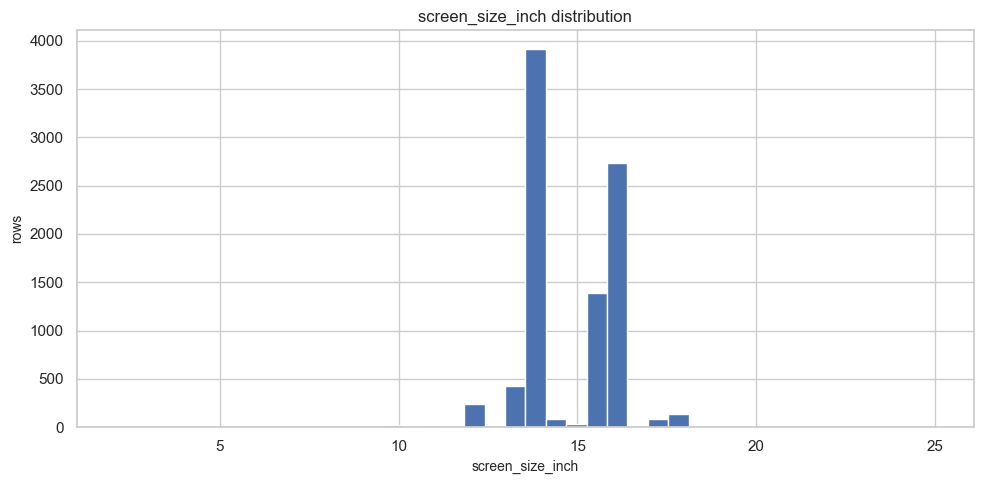

Saved figure: y:\Python\Laptop-Price-Prediction\reports\figures\eda\numeric_screen_size_inch_box_by_source.png


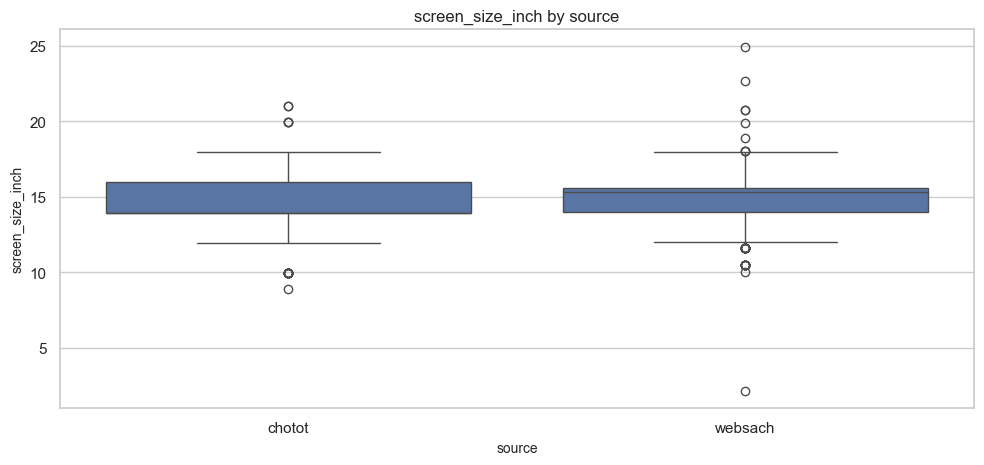

In [188]:
run_numeric_eda_for_col(df, "screen_size_inch")

In [189]:
eda_df = df.copy()
if "ram_gb" in eda_df:
    eda_df["ram_bucket_eda"] = pd.cut(eda_df["ram_gb"], bins=[-np.inf, 8, 16, 32, np.inf], labels=["<=8GB", "16GB", "32GB", ">32GB"]).astype("object").fillna("Unknown")
if "storage_gb" in eda_df:
    eda_df["storage_bucket_eda"] = pd.cut(eda_df["storage_gb"], bins=[-np.inf, 256, 512, 1024, 2048, np.inf], labels=["<=256GB", "512GB", "1TB", "2TB", ">2TB"]).astype("object").fillna("Unknown")
if "screen_size_inch" in eda_df:
    eda_df["screen_bucket_eda"] = pd.cut(eda_df["screen_size_inch"], bins=[-np.inf, 13, 14, 15, 16, 17, np.inf], labels=["<13in", "13-13.9in", "14-14.9in", "15-15.9in", "16-16.9in", ">=17in"]).astype("object").fillna("Unknown")
corr_rows = []
for col in existing_numeric_candidates:
    if col == "warranty_months":
        continue

    x = pd.to_numeric(df[col], errors="coerce")
    for target in ["target_price", "log_target_price"]:
        valid = x.notna() & df[target].notna()
        if valid.sum() >= 3:
            corr_rows.append({"feature": col, "target": target, "pearson": x[valid].corr(df.loc[valid, target], method="pearson"), "spearman": x[valid].corr(df.loc[valid, target], method="spearman"), "coverage": float(valid.mean())})
numeric_corr = pd.DataFrame(corr_rows).sort_values(["target", "spearman"], ascending=[True, False])
display(numeric_corr)
append_summary("numeric_features", "numeric_correlations", numeric_corr.to_dict("records"))
print("Interpretation: keep numeric specs with reasonable coverage and signal. If one source is sparse, use imputation plus missing flag rather than dropping immediately.")

,feature,target,pearson,spearman,coverage
3,storage_gb,log_target_price,0.569,0.680,0.943
1,ram_gb,log_target_price,0.536,0.559,0.982
5,screen_size_inch,log_target_price,0.200,0.248,0.902
2,storage_gb,target_price,0.680,0.680,0.943
0,ram_gb,target_price,0.676,0.559,0.982
4,screen_size_inch,target_price,0.175,0.248,0.902


Interpretation: keep numeric specs with reasonable coverage and signal. If one source is sparse, use imputation plus missing flag rather than dropping immediately.


## Numeric Feature Correlation

Bảng trên cho thấy các numeric features đều có tương quan dương với `target_price` và `log_target_price`.

### Key Findings

- `storage_gb` có tương quan mạnh nhất với target, đặc biệt với `log_target_price` có Spearman khoảng **0.680**.
- `ram_gb` cũng có tương quan khá tốt với giá, Spearman khoảng **0.559**.
- `screen_size_inch` có tương quan yếu hơn, Spearman chỉ khoảng **0.248**.
- Cả ba feature đều có coverage tốt: `ram_gb` khoảng **98.2%**, `storage_gb` khoảng **94.3%**, `screen_size_inch` khoảng **90.2%**.

### Key Insight

`ram_gb` và `storage_gb` là hai numeric features quan trọng cho mô hình dự đoán giá.
`screen_size_inch` vẫn nên giữ lại vì có coverage tốt, nhưng ảnh hưởng đến giá yếu hơn so với RAM và storage.

### Decision

Giữ `ram_gb`, `storage_gb`, `screen_size_inch` trong baseline model.
Loại `warranty_months` khỏi nhóm numeric chính do coverage thấp.

## 9. Categorical feature EDA

Tương tự ta cũng chỉ khảo sát các feature có ảnh hưởng để giảm tải sự phức tạp trong phân tích (bỏ đi origin_clean)

In [190]:
display_section("Categorical feature EDA")
key_categorical = [c for c in ["brand_grouped", "model_grouped", "cpu_brand", "cpu_tier", "gpu_tier", "storage_type_clean", "condition_clean", "warranty_status"] if c in df]
cardinality = categorical_cardinality_by_source(df, key_categorical)
display(cardinality)
append_summary("categorical_features", "cardinality", cardinality.to_dict("records"))
category_coverage_rows = []
def analyze_categorical_column(col):
    vc = df[col].fillna("Unknown").astype(str).value_counts(normalize=True, dropna=False)
    top15_share = float(vc.head(15).sum())
    unknown_other_share = float(vc[vc.index.str.lower().isin(["unknown", "other", "<na>", "nan", "none", "missing", ""])].sum())
    category_coverage_rows.append({"column": col, "top15_share": top15_share, "unknown_or_other_share": unknown_other_share})
    print(f"\nTop values for {col}")
    display(top_values_table(df, col, top_n=15).head(45))


Categorical feature EDA


,column,nunique_overall,nunique_chotot,nunique_websach
1,model_grouped,34,33,1
0,brand_grouped,15,12,12
4,gpu_tier,14,5,9
3,cpu_tier,11,7,6
2,cpu_brand,6,4,6
5,storage_type_clean,5,3,5
6,condition_clean,4,3,1
7,warranty_status,4,3,1


Nhìn chung, các cột có số lượng giá trị phân biệt khá khác nhau giữa hai nguồn dữ liệu. `model_grouped` đa dạng nhất với 34 giá trị, chủ yếu đến từ Chợ Tốt, trong khi Websach chỉ có 1 giá trị. `brand_grouped` tương đối cân bằng giữa hai nguồn. Một số cột như `origin_clean`, `condition_clean` và `warranty_status` có độ đa dạng thấp ở Websach, cho thấy dữ liệu Websach có thể ít chi tiết hơn hoặc cần kiểm tra lại bước chuẩn hóa. Ngược lại, Websach có độ đa dạng tốt hơn ở `gpu_tier`. Nhìn chung, Chợ Tốt đóng góp nhiều giá trị phân loại hơn ở phần lớn các cột.

In [191]:
analyze_categorical_column("brand_grouped")


Top values for brand_grouped


,scope,value,n,pct
0,overall,Dell,2601,0.258
1,overall,Lenovo,1591,0.158
2,overall,HP,1516,0.150
3,overall,ASUS,1392,0.138
4,overall,Apple,1049,0.104
5,overall,Acer,663,0.066
6,overall,MSI,466,0.046
7,overall,Microsoft,266,0.026
8,overall,Unknown,180,0.018
9,overall,Other,132,0.013


Ta gom các hãng khác thành 1 hãng duy nhất

In [192]:
df["brand_grouped"] = df["brand_grouped"].replace({
    "Hãng khác": "Other",
    "Other": "Other",
    "Unknown": "Other"
})

print(df["brand_grouped"].unique())

s = df["brand_grouped"].astype("string").str.strip()
s_lower = s.str.lower()
df["no_info_brand"] = s_lower.isin(["other"]).astype(int)
print(df["no_info_brand"].value_counts())

['Dell' 'Acer' 'HP' 'Apple' 'MSI' 'ASUS' 'Lenovo' 'Toshiba' 'Other'
 'Microsoft' 'Sony' 'LG' 'Gigabyte']
no_info_brand
0    9689
1     391
Name: count, dtype: int64


In [193]:
print(df["model_grouped"].unique())
analyze_categorical_column("model_grouped")

['Latitude' 'Other' 'Elitebook 800' 'MacBook Air' 'Nitro 5' 'MacBook Pro'
 'Precision' 'Dòng Khác' 'ThinkPad X1 Carbon' 'MacBook Air M2'
 'Macbook air m4' 'MacBook Air M1' 'Inspiron' 'TUF Gaming F15' 'Elitebook'
 'Vostro' 'XPS 13' 'Aspire' 'ROG Strix' 'TUF Gaming' 'Legion' 'ProBook'
 'Gaming Thin GF' 'IdeaPad' 'MacBook Pro M2' 'X Series' 'ThinkPad'
 'Latitude E Series' 'MacBook Pro M1' 'Latitude 14 7000' 'Vivobook 15'
 'Pavilion 15' 'Legion 5' 'Unknown']

Top values for model_grouped


,scope,value,n,pct
0,overall,Unknown,4382,0.435
1,overall,Other,2147,0.213
2,overall,Dòng Khác,826,0.082
3,overall,Latitude,462,0.046
4,overall,MacBook Pro,318,0.032
5,overall,Precision,195,0.019
6,overall,MacBook Air,179,0.018
7,overall,Inspiron,159,0.016
8,overall,ThinkPad,106,0.011
9,overall,Elitebook,95,0.009


In [194]:
df["model_grouped"] = df["model_grouped"].replace({
    "Dòng Khác": "Other",
    "Unknown": "Other",
    "Orther": "Other",
})

print(df["model_grouped"].unique())


s = df["model_grouped"].astype("string").str.strip()
s_lower = s.str.lower()

df["no_info_model"] = s_lower.isin(["other"]).astype(int)
print(df["no_info_model"].value_counts())

['Latitude' 'Other' 'Elitebook 800' 'MacBook Air' 'Nitro 5' 'MacBook Pro'
 'Precision' 'ThinkPad X1 Carbon' 'MacBook Air M2' 'Macbook air m4'
 'MacBook Air M1' 'Inspiron' 'TUF Gaming F15' 'Elitebook' 'Vostro'
 'XPS 13' 'Aspire' 'ROG Strix' 'TUF Gaming' 'Legion' 'ProBook'
 'Gaming Thin GF' 'IdeaPad' 'MacBook Pro M2' 'X Series' 'ThinkPad'
 'Latitude E Series' 'MacBook Pro M1' 'Latitude 14 7000' 'Vivobook 15'
 'Pavilion 15' 'Legion 5']
no_info_model
1    7355
0    2725
Name: count, dtype: int64


In [195]:
analyze_categorical_column("cpu_brand")
analyze_categorical_column("cpu_tier")


Top values for cpu_brand


,scope,value,n,pct
0,overall,Intel,8101,0.804
1,overall,AMD,1043,0.103
2,overall,Apple,553,0.055
3,overall,Unknown,344,0.034
4,overall,Qualcomm,35,0.003
5,overall,Microsoft SQ,4,0.000
6,source=chotot,Intel,4553,0.799
7,source=chotot,AMD,469,0.082
8,source=chotot,Apple,420,0.074
9,source=chotot,Unknown,256,0.045



Top values for cpu_tier


,scope,value,n,pct
0,overall,Upper-mid,3385,0.336
1,overall,Mid,2789,0.277
2,overall,Mid-range,1805,0.179
3,overall,Entry,778,0.077
4,overall,Unknown,353,0.035
5,overall,Other,244,0.024
6,overall,High-end,241,0.024
7,overall,High,201,0.020
8,overall,Missing,174,0.017
9,overall,Low-end,57,0.006


In [196]:
df["cpu_brand"] = df["cpu_brand"].replace({
    "Unknown": "Other",
})

print(df["cpu_brand"].unique())


s = df["cpu_brand"].astype("string").str.strip()
s_lower = s.str.lower()

df["no_info_cpu_brand"] = s_lower.isin(["other"]).astype(int)
print(df["no_info_cpu_brand"].value_counts())

df["cpu_tier"] = df["cpu_tier"].replace({
    "Unknown": "Other",
    "Missing": "Other",
    "Orther": "Other",
})

print(df["cpu_tier"].unique())


s = df["cpu_tier"].astype("string").str.strip()
s_lower = s.str.lower()

df["no_info_cpu_tier"] = s_lower.isin(["other"]).astype(int)
print(df["no_info_cpu_tier"].value_counts())

['Intel' 'Other' 'AMD' 'Apple' 'Qualcomm' 'Microsoft SQ']
no_info_cpu_brand
0    9736
1     344
Name: count, dtype: int64
['Upper-mid' 'Entry' 'Other' 'Mid' 'High' 'Low' 'Mid-range' 'High-end'
 'Low-end']
no_info_cpu_tier
0    9309
1     771
Name: count, dtype: int64


In [197]:
analyze_categorical_column("gpu_tier")


Top values for gpu_tier


,scope,value,n,pct
0,overall,Integrated - Intel,2528,0.251
1,overall,Intel Integrated,2038,0.202
2,overall,Dedicated - Other/Entry,1449,0.144
3,overall,Missing,1307,0.130
4,overall,Other GPU,631,0.063
5,overall,Other RTX,482,0.048
6,overall,AMD Radeon,331,0.033
7,overall,RTX 4000,305,0.030
8,overall,Unclear,239,0.024
9,overall,Unknown,207,0.021


In [198]:
df["gpu_tier"] = df["gpu_tier"].replace({
    "Unclear": "Other",
    "Orther": "Other",
    "Other GPU": "Other",
    "Unknown": "Other",
    "Missing": "Other",
})

print(df["gpu_tier"].unique())


s = df["gpu_tier"].astype("string").str.strip()
s_lower = s.str.lower()

df["no_info_gpu"] = s_lower.isin(["other"]).astype(int)
print(df["no_info_gpu"].value_counts())

['Integrated - Intel' 'Other' 'Dedicated - Other/Entry'
 'Integrated - AMD Radeon' 'Intel Integrated' 'RTX 4000' 'RTX 5000'
 'AMD Radeon' 'Apple GPU' 'Other RTX' 'GTX']
no_info_gpu
0    7696
1    2384
Name: count, dtype: int64


In [199]:
analyze_categorical_column("storage_type_clean")


Top values for storage_type_clean


,scope,value,n,pct
0,overall,SSD,8682,0.861
1,overall,Unknown,864,0.086
2,overall,HDD,476,0.047
3,overall,SSD + HDD,57,0.006
4,overall,Other,1,0.000
5,source=chotot,SSD,4982,0.874
6,source=chotot,Unknown,642,0.113
7,source=chotot,HDD,74,0.013
8,source=websach,SSD,3700,0.844
9,source=websach,HDD,402,0.092


In [200]:
df["storage_type_clean"] = df["storage_type_clean"].replace({
    "Unknown": "Other",
    "Orther": "Other"
})

print(df["storage_type_clean"].unique())
print(df["storage_type_clean"].value_counts())

['SSD' 'Other' 'HDD' 'SSD + HDD']
storage_type_clean
SSD          8682
Other         865
HDD           476
SSD + HDD      57
Name: count, dtype: int64


SSD chiếm đa số tính hiệu ko mạnh và chưa đủ quan trọng để tách thêm feature

In [201]:
analyze_categorical_column("condition_clean")


Top values for condition_clean


,scope,value,n,pct
0,overall,Đã sử dụng (chưa sửa chữa),5456,0.541
1,overall,Unknown,4382,0.435
2,overall,Mới,178,0.018
3,overall,Đã sử dụng (qua sửa chữa),64,0.006
4,source=chotot,Đã sử dụng (chưa sửa chữa),5456,0.958
5,source=chotot,Mới,178,0.031
6,source=chotot,Đã sử dụng (qua sửa chữa),64,0.011
7,source=websach,Unknown,4382,1.000


In [202]:
# Websach mặc định là mới
# nhận thấy Other chỉ đến từ websach
df["condition_clean"] = df["condition_clean"].replace({
    "Unknown": "Mới"
})

print(df["condition_clean"].unique())

['Đã sử dụng (chưa sửa chữa)' 'Mới' 'Đã sử dụng (qua sửa chữa)']


In [203]:
analyze_categorical_column("warranty_status")


Top values for warranty_status


,scope,value,n,pct
0,overall,Unknown,4382,0.435
1,overall,Manufacturer,2871,0.285
2,overall,Active,2396,0.238
3,overall,Expired,431,0.043
4,source=chotot,Manufacturer,2871,0.504
5,source=chotot,Active,2396,0.420
6,source=chotot,Expired,431,0.076
7,source=websach,Unknown,4382,1.000


In [204]:
# Websach mặc định là mới
# nhận thấy Other chỉ đến từ websach
df["warranty_status"] = df["warranty_status"].replace({
    "Unknown": "not_active",
})

print(df["warranty_status"].unique())

['Active' 'Manufacturer' 'Expired' 'not_active']


,column,top15_share,unknown_or_other_share
1,model_grouped,0.922,0.648
6,condition_clean,1.000,0.435
7,warranty_status,1.000,0.435
4,gpu_tier,1.000,0.150
5,storage_type_clean,1.000,0.086
3,cpu_tier,1.000,0.076
2,cpu_brand,1.000,0.034
0,brand_grouped,1.000,0.031


Saved figure: y:\Python\Laptop-Price-Prediction\reports\figures\eda\categorical_brand_grouped_by_source.png


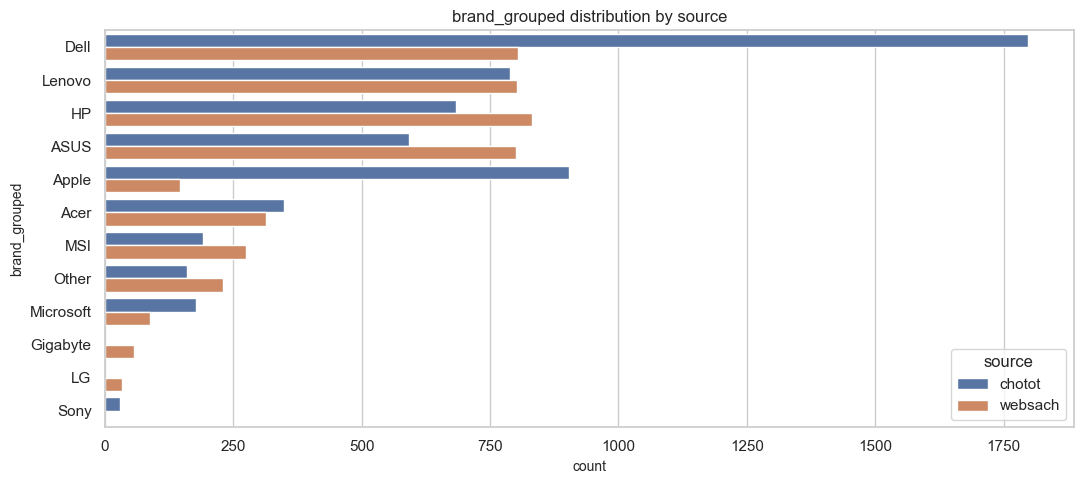

Saved figure: y:\Python\Laptop-Price-Prediction\reports\figures\eda\categorical_cpu_tier_by_source.png


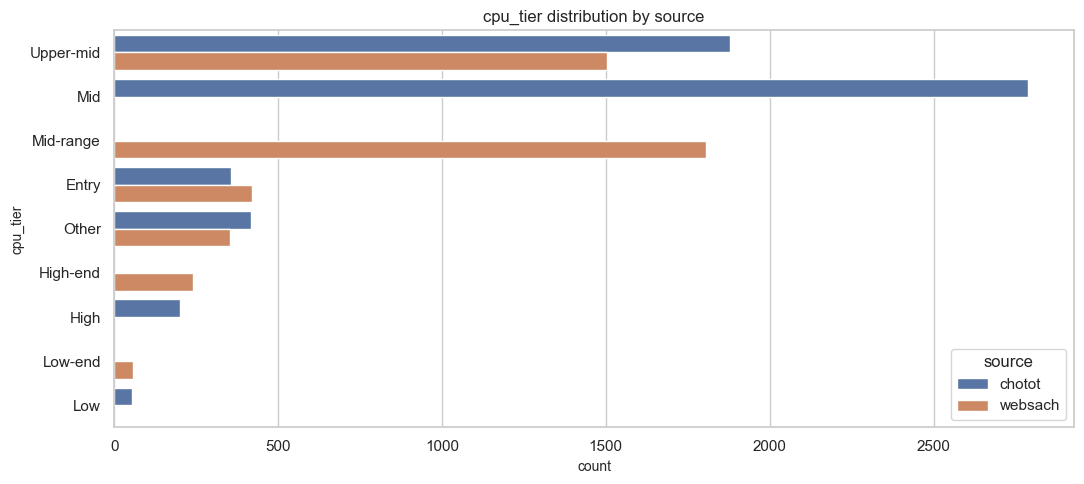

Saved figure: y:\Python\Laptop-Price-Prediction\reports\figures\eda\categorical_gpu_tier_by_source.png


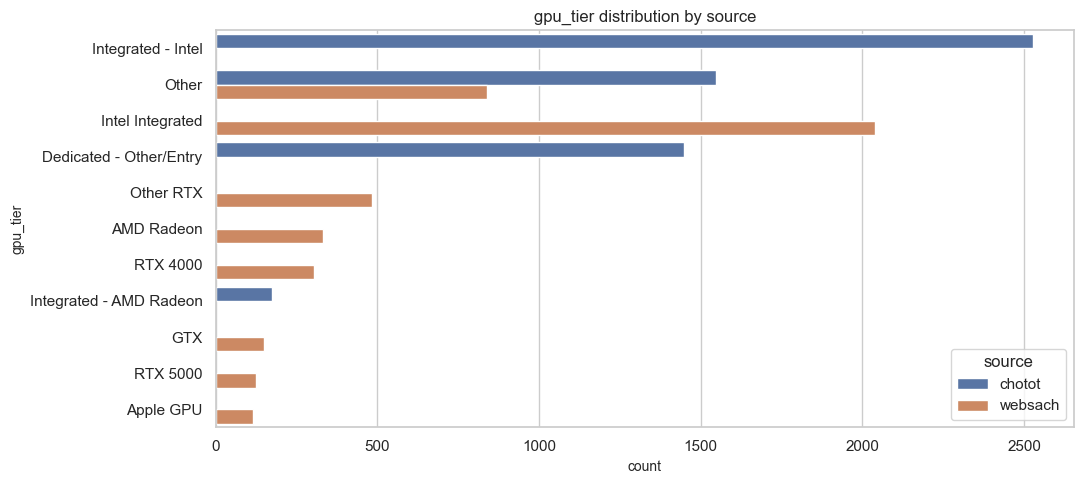

Saved figure: y:\Python\Laptop-Price-Prediction\reports\figures\eda\categorical_storage_type_clean_by_source.png


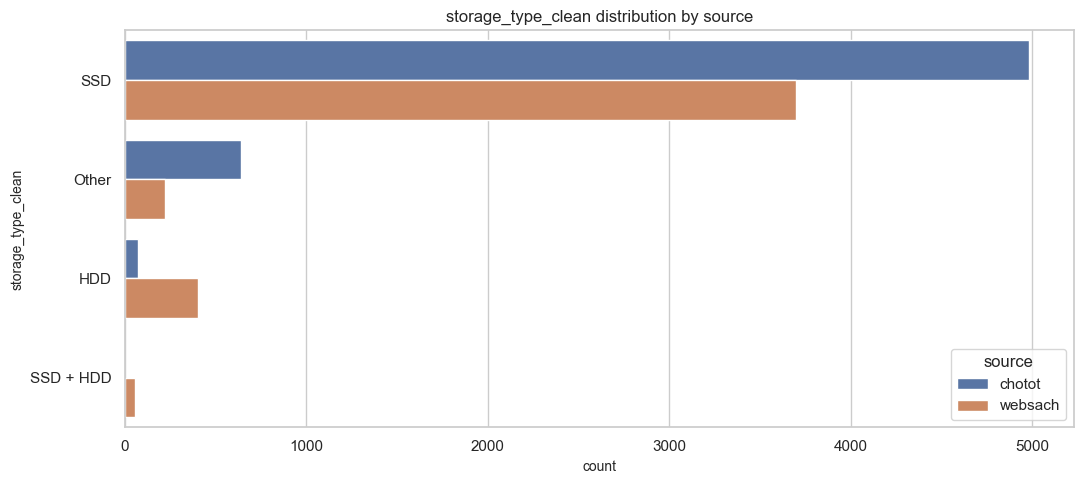

Saved figure: y:\Python\Laptop-Price-Prediction\reports\figures\eda\categorical_condition_clean_by_source.png


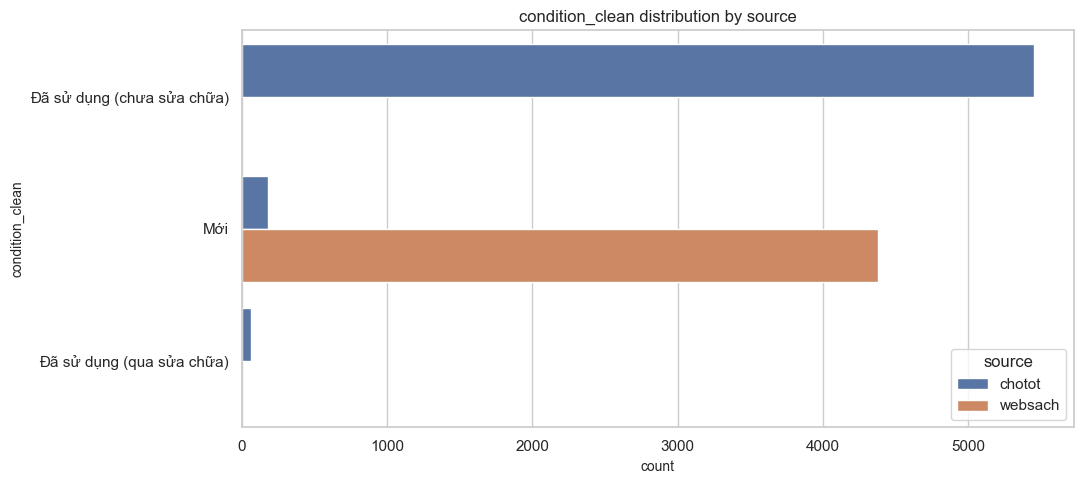

Interpretation: prefer grouped/stable categorical columns for baseline. Treat raw brand/model as audit or advanced experiments when cardinality is high.


In [205]:
category_coverage = pd.DataFrame(category_coverage_rows).sort_values("unknown_or_other_share", ascending=False)
display(category_coverage)
append_summary("categorical_features", "category_coverage", category_coverage.to_dict("records"))
for col in ["brand_grouped", "cpu_tier", "gpu_tier", "storage_type_clean", "condition_clean"]:
    if col not in df: continue
    top_values = df[col].fillna("Unknown").astype(str).value_counts().head(12).index
    plot_data = df[df[col].fillna("Unknown").astype(str).isin(top_values)].copy()
    plt.figure(figsize=(11, 5))
    if sns: sns.countplot(data=plot_data, y=col, hue="source", order=top_values)
    else: pd.crosstab(plot_data[col], plot_data["source"]).loc[top_values].plot(kind="barh", ax=plt.gca())
    plt.title(f"{col} distribution by source"); save_current_fig(f"categorical_{col}_by_source"); plt.show()
print("Interpretation: prefer grouped/stable categorical columns for baseline. Treat raw brand/model as audit or advanced experiments when cardinality is high.")

## Nhận xét phân phối categorical features

Qua phân tích phân phối các biến categorical theo `source`, dữ liệu cho thấy có sự khác biệt khá rõ giữa hai nguồn `chotot` và `websach`. Điều này cho thấy `source` không chỉ là biến phụ, mà có thể phản ánh sự khác biệt về cách thu thập dữ liệu, loại sản phẩm và mặt bằng giá giữa hai nguồn.

### 1. Domain shift giữa `chotot` và `websach`

Một số biến có phân phối rất khác nhau giữa hai nguồn dữ liệu, đặc biệt là `condition_clean`, `cpu_tier`, `gpu_tier`, `storage_type_clean` và `brand_grouped`.

Ví dụ, `chotot` chủ yếu chứa laptop đã sử dụng, trong khi `websach` chủ yếu chứa laptop mới. Nếu không giữ lại biến `source`, mô hình có thể nhầm lẫn tác động của tình trạng máy với tác động của nguồn dữ liệu.

Vì vậy, trong các thử nghiệm mô hình, nên giữ biến `source` hoặc ít nhất dùng nó để đánh giá hiệu năng riêng theo từng nguồn.

### 2. Nhận xét về `condition_clean`

Biến `condition_clean` có phân phối lệch mạnh theo `source`.

Nguồn `chotot` chủ yếu là nhóm máy đã sử dụng, trong khi `websach` chủ yếu là nhóm máy mới. Đây là biến có ý nghĩa quan trọng với giá laptop, nhưng cũng có nguy cơ bị trộn thông tin với biến `source`.

Do đó, nên giữ `condition_clean`, nhưng cần kiểm tra thêm xem mô hình có đang học quá nhiều từ sự khác biệt giữa hai nguồn dữ liệu hay không. Một cách kiểm tra phù hợp là so sánh hiệu năng mô hình trên từng nguồn dữ liệu riêng biệt.

### 3. Nhận xét về `origin_clean`

Biến `origin_clean` có tỷ lệ `Unknown/Other` rất cao, khoảng 78.3%. Điều này cho thấy phần lớn dữ liệu trong cột này không mang thông tin rõ ràng. Đồng thười các notebook trước đó đã cho biết feature này không khai thác được nhiều.

### 4. Nhận xét về `model_grouped`

Biến `model_grouped` cũng có tỷ lệ `Unknown/Other` khá cao, khoảng 64.8%. Điều này cho thấy thông tin model chưa đủ sạch hoặc chưa được chuẩn hóa tốt.

Cột này vẫn có thể hữu ích nếu một số dòng model phổ biến có ảnh hưởng rõ đến giá, nhưng không nên quá phụ thuộc vào nó. Khi sử dụng, nên kết hợp thêm biến đánh dấu việc model có rơi vào nhóm thiếu thông tin hoặc nhóm khác hay không.

Nếu dùng các mô hình đơn giản như Linear Regression, Ridge hoặc Lasso, `model_grouped` có thể gây nhiễu. Với các mô hình cây như Random Forest, XGBoost, LightGBM hoặc CatBoost, có thể thử giữ lại và đánh giá bằng cross-validation.

### 5. Nhận xét về `brand_grouped`

Biến `brand_grouped` có phân phối tương đối hợp lý hơn. Các thương hiệu chính như Dell, Lenovo, HP, ASUS và Apple xuất hiện nhiều và có ý nghĩa rõ với giá laptop.

Cột này nên được giữ trong baseline model. Tuy nhiên, nhóm `Other` vẫn nên được đánh dấu riêng vì nó có thể chứa nhiều thương hiệu nhỏ, thương hiệu hiếm hoặc thông tin chưa được chuẩn hóa tốt.

### 6. Nhận xét về `cpu_tier`

Biến `cpu_tier` có nhiều nhãn gần nghĩa nhau như `Mid`, `Mid-range`, `High`, `High-end`, `Low`, `Low-end`. Các nhãn này nên được chuẩn hóa lại để giảm nhiễu và giúp mô hình học ổn định hơn.

Về mặt ý nghĩa, nên gom các nhóm gần giống nhau về cùng một cấp độ. Ví dụ `Mid` và `Mid-range` có thể được xem là cùng một nhóm, `High` và `High-end` cũng có thể được gom lại nếu không có định nghĩa tách biệt rõ ràng.

Sau khi chuẩn hóa, nên giữ thêm biến đánh dấu các trường hợp `Other` hoặc không rõ thông tin CPU tier.

### 7. Nhận xét về `gpu_tier`

GPU là một trong những feature có thể ảnh hưởng mạnh đến giá laptop, đặc biệt với laptop gaming, workstation hoặc máy có card đồ họa rời.

Tuy nhiên, `gpu_tier` có các nhóm như `Missing`, `Unclear`, `Other`. Các nhóm này không nên bị xem là giống hoàn toàn nhau. Thiếu thông tin GPU có thể mang ý nghĩa riêng, vì nhiều laptop văn phòng không ghi rõ GPU thường chỉ dùng GPU tích hợp.

Vì vậy, nên giữ `gpu_tier`, đồng thời tạo thêm thông tin phụ như có hay không có GPU rời, và có bị thiếu hoặc không rõ thông tin GPU hay không.

### 8. Nhận xét về `storage_type_clean`

Biến `storage_type_clean` tương đối ổn vì phần lớn laptop dùng SSD. Đây là thông tin có ý nghĩa với giá và nên được giữ lại.

Tuy nhiên, nhóm `Other` vẫn xuất hiện, đặc biệt ở nguồn `chotot`. Điều này có thể đến từ mô tả không đầy đủ, nhiều loại ổ cứng kết hợp, hoặc dữ liệu chưa được chuẩn hóa. Vì vậy, nên giữ biến này nhưng đánh dấu riêng các dòng rơi vào nhóm `Other`.

### 9. Nhận xét về `warranty_status`

Biến `warranty_status` có thể hữu ích, nhưng cần kiểm tra xem nó có bị trùng thông tin với `condition_clean` hoặc `source` hay không.

Nếu `warranty_status` gần như chỉ phản ánh nguồn dữ liệu hoặc tình trạng máy, thì không nên dùng nó như một biến categorical quá chi tiết. Trong trường hợp thời gian bảo hành không quan trọng nhưng trạng thái có hoặc không có bảo hành vẫn có ý nghĩa, nên đơn giản hóa thành biến nhị phân `has_warranty`.

Biến `has_warranty` có thể hữu ích hơn `warranty_time`, vì nó phản ánh sự khác biệt cơ bản giữa máy có bảo hành và máy không có bảo hành, trong khi số tháng bảo hành có thể không tạo ra khác biệt giá rõ ràng.

## Kết luận

Các categorical features không nên được encode trực tiếp một cách máy móc vì nhiều cột có tỷ lệ `Unknown`, `Other`, `Missing` khá cao và có sự khác biệt rõ theo nguồn dữ liệu.

Nên ưu tiên giữ các biến có ý nghĩa rõ và phân phối tương đối ổn định như `source`, `brand_grouped`, `cpu_tier` sau khi chuẩn hóa, `gpu_tier`, `storage_type_clean`, `condition_clean` và `has_warranty`.

Các biến như `origin_clean`, `model_grouped` và `warranty_status` cần được dùng cẩn thận vì có tỷ lệ thiếu thông tin hoặc nhóm khác khá cao. Với các biến này, nên cân nhắc chuyển thành biến đánh dấu có/không có thông tin thay vì sử dụng trực tiếp toàn bộ category.

Nhìn chung, dữ liệu có dấu hiệu domain shift giữa `chotot` và `websach`, nên `source` là một biến quan trọng. Nếu bỏ `source`, mô hình có thể học sai mối quan hệ giữa tình trạng máy, cấu hình, bảo hành và giá bán.

## 9a. Categorical feature usefulness score


Categorical feature usefulness score


,feature,eligible_categories_n_ge_20,coverage_in_eligible_categories,median_price_min,median_price_max,median_price_range,median_price_iqr_across_categories,relative_range_vs_global_median
3,cpu_tier,9,1.000,"2,000,000.000","57,599,000.000","55,599,000.000","11,600,000.000",4.119
4,gpu_tier,11,1.000,"6,800,000.000","45,970,000.000","39,170,000.000","17,980,000.000",2.902
0,brand_grouped,13,1.000,"2,100,000.000","29,994,500.000","27,894,500.000","6,000,000.000",2.066
1,model_grouped,32,1.000,"2,500,000.000","23,500,000.000","21,000,000.000","8,100,000.750",1.556
2,cpu_brand,5,1.000,"8,800,000.000","26,990,000.000","18,190,000.000","10,210,000.000",1.348
6,condition_clean,3,1.000,"3,050,000.000","20,990,000.000","17,940,000.000","8,970,000.000",1.329
7,warranty_status,4,1.000,"5,555,000.000","21,195,000.000","15,640,000.000","5,567,500.000",1.159
5,storage_type_clean,4,1.000,"10,900,000.000","23,990,000.000","13,090,000.000","4,597,750.000",0.970


Saved figure: y:\Python\Laptop-Price-Prediction\reports\figures\eda\categorical_feature_signal_strength.png


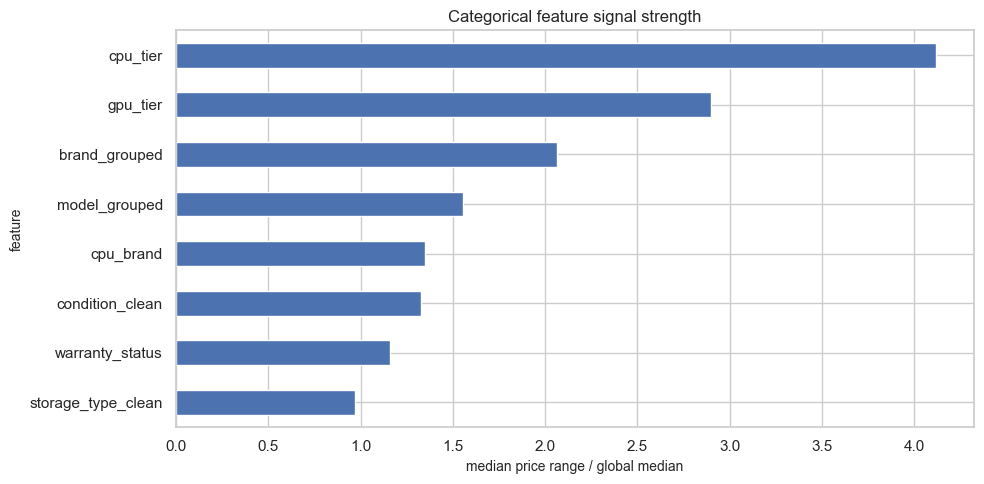

In [206]:
display_section("Categorical feature usefulness score")
cat_signal_rows = []

for col in key_categorical:
    tmp = df[[col, "target_price"]].copy()
    grouped = tmp.groupby(col, dropna=False)["target_price"].agg(n="size", median_price="median").reset_index()
    eligible = grouped[grouped["n"] >= 20]
    if eligible.empty:
        continue
    q75 = eligible["median_price"].quantile(0.75)
    q25 = eligible["median_price"].quantile(0.25)
    cat_signal_rows.append({
        "feature": col,
        "eligible_categories_n_ge_20": int(len(eligible)),
        "coverage_in_eligible_categories": float(eligible["n"].sum() / len(df)),
        "median_price_min": float(eligible["median_price"].min()),
        "median_price_max": float(eligible["median_price"].max()),
        "median_price_range": float(eligible["median_price"].max() - eligible["median_price"].min()),
        "median_price_iqr_across_categories": float(q75 - q25),
        "relative_range_vs_global_median": float((eligible["median_price"].max() - eligible["median_price"].min()) / df["target_price"].median()),
    })
categorical_signal_score = pd.DataFrame(cat_signal_rows).sort_values("relative_range_vs_global_median", ascending=False)
display(categorical_signal_score)
append_summary("categorical_signal", "categorical_signal_score", categorical_signal_score.to_dict("records"))

plt.figure(figsize=(10, 5))
if not categorical_signal_score.empty:
    categorical_signal_score.sort_values("relative_range_vs_global_median").plot.barh(x="feature", y="relative_range_vs_global_median", legend=False, ax=plt.gca())
    plt.title("Categorical feature signal strength")
    plt.xlabel("median price range / global median")
    save_current_fig("categorical_feature_signal_strength")
    plt.show()

top_cat_signal = categorical_signal_score.head(5)["feature"].tolist() if not categorical_signal_score.empty else []

## Nhận xét mức độ tín hiệu của categorical features

Bảng và biểu đồ trên đánh giá mức độ phân tách giá của các categorical features dựa trên khoảng dao động median price giữa các nhóm category. Chỉ các category có số lượng mẫu đủ lớn mới được xét, nên kết quả này phản ánh tín hiệu tương đối ổn định hơn so với việc nhìn toàn bộ category hiếm.

### 1. `cpu_tier` có tín hiệu mạnh nhất

`cpu_tier` có `relative_range_vs_global_median` cao nhất, khoảng 4.119. Median price giữa các nhóm CPU tier dao động từ khoảng 2.0 triệu đến 57.6 triệu, tạo ra khoảng chênh lệch rất lớn.

Điều này cho thấy phân cấp CPU có ảnh hưởng mạnh đến giá laptop. Đây nên là một trong những categorical features quan trọng nhất cần giữ trong model.

Tuy nhiên, vì `cpu_tier` có tín hiệu rất mạnh, cần đảm bảo các nhãn tier được chuẩn hóa nhất quán. Các nhóm gần nghĩa như `Mid` và `Mid-range`, hoặc `High` và `High-end`, nên được kiểm tra để tránh tạo ra phân tách giả do cách đặt nhãn không thống nhất.

### 2. `gpu_tier` cũng là feature rất quan trọng

`gpu_tier` đứng thứ hai với `relative_range_vs_global_median` khoảng 2.935. Median price dao động từ khoảng 6.35 triệu đến 45.97 triệu.

Điều này hợp lý vì GPU ảnh hưởng lớn đến giá, đặc biệt với laptop gaming, workstation hoặc các dòng máy có card đồ họa rời. Feature này nên được giữ lại trong model.

Tuy nhiên, cần xử lý cẩn thận các nhóm như `Missing`, `Unclear`, `Other`, vì các nhóm này có thể không đồng nghĩa với nhau. Thiếu thông tin GPU có thể là máy chỉ dùng GPU tích hợp, nhưng cũng có thể là do dữ liệu mô tả không đầy đủ.

### 3. `brand_grouped` có tín hiệu tốt và ổn định

`brand_grouped` có `relative_range_vs_global_median` khoảng 2.066, cho thấy thương hiệu có ảnh hưởng đáng kể đến giá laptop.

Median price giữa các brand dao động từ khoảng 2.1 triệu đến 29.99 triệu. Điều này phản ánh sự khác biệt giữa các nhóm thương hiệu phổ thông, gaming, workstation hoặc premium.

Feature này nên được giữ trong baseline model. Nhóm `Other` vẫn nên được đánh dấu riêng vì có thể chứa nhiều thương hiệu nhỏ hoặc dữ liệu chưa được chuẩn hóa.

### 4. `model_grouped` có tín hiệu nhưng cần thận trọng

`model_grouped` có `relative_range_vs_global_median` khoảng 1.556, tức là vẫn có khả năng phân tách giá. Điều này hợp lý vì một số dòng model như ThinkPad, MacBook, Latitude, Legion hoặc XPS thường có mặt bằng giá khác nhau.

Tuy nhiên, trước đó `model_grouped` có tỷ lệ `Unknown/Other` khá cao, nên không nên dùng feature này một cách quá tin tưởng. Nên giữ để thử nghiệm, nhưng cần kiểm tra xem nó có thật sự cải thiện validation score hay chỉ tạo thêm nhiễu.

### 5. `cpu_brand` có tín hiệu trung bình

`cpu_brand` có `relative_range_vs_global_median` khoảng 1.348. Feature này có tín hiệu, nhưng yếu hơn nhiều so với `cpu_tier`.

Điều này hợp lý vì bản thân thương hiệu CPU như Intel, AMD, Apple hay Qualcomm chỉ cho biết một phần thông tin. Giá laptop thường phụ thuộc nhiều hơn vào tier hoặc dòng chip cụ thể.

Có thể giữ `cpu_brand`, nhưng nên xem nó là feature phụ. Nếu đã có `cpu_tier` và thông tin CPU chi tiết hơn, vai trò của `cpu_brand` có thể giảm.

### 6. `condition_clean` có tín hiệu nhưng dễ bị ảnh hưởng bởi source

`condition_clean` có `relative_range_vs_global_median` khoảng 1.329, cho thấy tình trạng máy có liên quan đến giá.

Median price giữa các nhóm tình trạng dao động từ khoảng 3.05 triệu đến 20.99 triệu. Tuy nhiên, feature này cần được dùng cẩn thận vì phân phối condition đang lệch mạnh theo `source`: `chotot` chủ yếu là máy đã sử dụng, còn `websach` chủ yếu là máy mới.

Vì vậy, `condition_clean` nên được giữ, nhưng cần đi kèm `source` để tránh mô hình học nhầm tác động của nguồn dữ liệu thành tác động của tình trạng máy.

### 7. `storage_type_clean` có tín hiệu thấp hơn kỳ vọng

`storage_type_clean` có `relative_range_vs_global_median` khoảng 0.970, thấp hơn các feature như CPU, GPU, brand và condition.

Điều này không có nghĩa storage không quan trọng, mà có thể do phần lớn laptop trong dữ liệu đều dùng SSD, khiến khả năng phân tách của loại ổ cứng bị giảm. Thông tin dung lượng lưu trữ có thể quan trọng hơn loại ổ cứng.

Do đó, nên giữ `storage_type_clean`, nhưng không nên kỳ vọng nó là feature chính. Nếu có biến dung lượng SSD/HDD riêng, các biến đó có thể mang nhiều tín hiệu hơn.

### 8. `warranty_status` có tín hiệu yếu nhất trong nhóm này

`warranty_status` có `relative_range_vs_global_median` thấp nhất, khoảng 0.758. Median price dao động từ khoảng 5.56 triệu đến 15.79 triệu.

Feature này vẫn có một ít tín hiệu, nhưng yếu hơn các nhóm cấu hình và thương hiệu. Nếu khảo sát trước đó cho thấy thời gian bảo hành không quan trọng, thì nên ưu tiên biến đơn giản hơn là `has_warranty`.

Nói cách khác, trạng thái có hay không có bảo hành có thể hữu ích hơn việc giữ nhiều nhãn bảo hành chi tiết.

## Kết luận

Thứ tự mức độ tín hiệu theo phân tích median price range là:

1. `cpu_tier`
2. `gpu_tier`
3. `brand_grouped`
4. `model_grouped`
5. `cpu_brand`
6. `condition_clean`
7. `storage_type_clean`
8. `warranty_status`

Các feature nên ưu tiên giữ trong baseline model là `cpu_tier`, `gpu_tier`, `brand_grouped`, `condition_clean`, `storage_type_clean` và `source`.

`model_grouped` có thể giữ để thử nghiệm nhưng cần kiểm tra kỹ vì tỷ lệ Unknown/Other cao. `warranty_status` nên được đơn giản hóa thành `has_warranty` nếu biến chi tiết không giúp cải thiện validation score.

Nhìn chung, các feature liên quan đến cấu hình phần cứng như CPU và GPU đang mang tín hiệu mạnh nhất. Các feature mô tả phụ như warranty, origin hoặc storage type có tín hiệu yếu hơn và nên được xử lý dưới dạng feature hỗ trợ thay vì feature chính.

## 9b. Boolean feature EDA

In [207]:
display_section("Boolean feature EDA")
boolean_rows = []
for col in existing_boolean_candidates:
    s = df[col].fillna(False).astype(bool)
    row = {"feature": col, "true_count": int(s.sum()), "true_rate": float(s.mean()), "missing_like_rate": missing_like_rate(df[col])}
    for src, part in df.groupby("source", dropna=False):
        ps = part[col].fillna(False).astype(bool)
        row[f"true_rate_{src}"] = float(ps.mean())
        row[f"median_price_true_{src}"] = float(part.loc[ps, "target_price"].median()) if ps.any() else np.nan
        row[f"median_price_false_{src}"] = float(part.loc[~ps, "target_price"].median()) if (~ps).any() else np.nan
    boolean_rows.append(row)
boolean_eda = pd.DataFrame(boolean_rows).sort_values("true_rate", ascending=False)
display(boolean_eda)
append_summary("boolean_features", "boolean_eda", boolean_eda.to_dict("records"))
low_variance_booleans = boolean_eda.loc[(boolean_eda["true_rate"] < 0.01) | (boolean_eda["true_rate"] > 0.99), "feature"].tolist() if not boolean_eda.empty else []
price_derived_boolean_present = [c for c in ["flag_price_spread_warn", "flag_price_spread_critical"] if c in existing_boolean_candidates]


Boolean feature EDA


,feature,true_count,true_rate,missing_like_rate,true_rate_chotot,median_price_true_chotot,median_price_false_chotot,true_rate_websach,median_price_true_websach,median_price_false_websach
14,is_soft_duplicate_spec,2514,0.249,0.000,0.000,NaN,"7,890,000.000",0.574,"20,150,000.000","22,590,000.000"
1,model_is_rare,2147,0.213,0.435,0.377,"9,500,000.000","7,000,000.000",0.000,NaN,"21,195,000.000"
6,gpu_missing,1514,0.150,0.000,0.229,"6,350,000.000","8,200,000.000",0.047,"20,950,000.000","21,218,000.000"
4,screen_missing,1027,0.102,0.000,0.163,"6,000,000.000","8,000,000.000",0.022,"17,755,000.000","21,290,000.000"
3,storage_missing,613,0.061,0.000,0.068,"4,500,000.000","8,000,000.000",0.051,"19,690,000.000","21,290,000.000"
12,flag_price_spread_warn,583,0.058,0.000,0.000,NaN,"7,890,000.000",0.133,"18,006,229.000","21,690,000.000"
5,cpu_missing,293,0.029,0.000,0.036,"5,500,000.000","7,900,000.000",0.020,"28,990,000.000","20,990,000.000"
2,ram_missing,207,0.021,0.000,0.032,"5,450,000.000","7,900,000.000",0.005,"19,500,000.000","21,218,000.000"
13,flag_price_spread_critical,142,0.014,0.000,0.000,NaN,"7,890,000.000",0.032,"13,944,500.000","21,490,000.000"
0,brand_is_rare,132,0.013,0.000,0.014,"9,200,000.000","7,860,000.000",0.012,"22,490,000.000","21,190,000.000"


## Nhận xét các biến flag và missing indicators

Bảng trên cho thấy tỷ lệ xuất hiện của các biến dạng flag, bao gồm các biến thiếu thông tin, biến dữ liệu hiếm, biến nghi ngờ bất thường và biến cảnh báo chênh lệch giá. Các biến này không chỉ phản ánh bản thân thông tin sản phẩm, mà còn phản ánh chất lượng dữ liệu và sự khác biệt giữa hai nguồn `chotot` và `websach`.

### 1. `is_soft_duplicate_spec`

`is_soft_duplicate_spec` có tỷ lệ xuất hiện khá cao, khoảng 24.9% toàn bộ dữ liệu. Đặc biệt, biến này gần như không xuất hiện ở `chotot`, nhưng lại chiếm khoảng 57.4% ở `websach`.

Điều này cho thấy dữ liệu `websach` có nhiều dòng có cấu hình gần giống nhau. Đây có thể là các sản phẩm cùng cấu hình nhưng khác màu, khác phiên bản nhỏ, khác cửa hàng, hoặc các listing được chuẩn hóa theo mẫu.

Biến này nên được giữ để model nhận biết các dòng có cấu hình lặp lại. Tuy nhiên, cần cẩn thận vì nó cũng có thể phản ánh đặc trưng của nguồn dữ liệu `websach` hơn là đặc trưng sản phẩm.

### 2. `model_is_rare`

`model_is_rare` có tỷ lệ khoảng 21.3% toàn bộ dữ liệu và có `missing_like_rate` khoảng 43.5%. Biến này xuất hiện ở `chotot` khoảng 37.7%, nhưng gần như không xuất hiện ở `websach`.

Điều này cho thấy model hiếm chủ yếu đến từ `chotot`, nơi dữ liệu có thể đa dạng hơn, nhiều dòng cũ hơn hoặc mô tả không đồng nhất hơn.

Median price của nhóm `model_is_rare = True` ở `chotot` cao hơn nhóm False, cho thấy nhóm model hiếm không nhất thiết là nhiễu. Nó có thể chứa các dòng đặc thù, workstation, gaming hoặc các dòng ít phổ biến nhưng giá cao.

Vì vậy, không nên tự động loại bỏ `model_is_rare`. Nên giữ biến này như một flag phụ, nhưng cần kết hợp với `model_grouped`, `brand_grouped`, `cpu_tier` và `gpu_tier` để tránh diễn giải sai.

### 3. Các biến missing phần cứng

Các biến thiếu thông tin phần cứng có tỷ lệ như sau:

- `gpu_missing`: khoảng 15.0%
- `screen_missing`: khoảng 10.2%
- `storage_missing`: khoảng 6.1%
- `cpu_missing`: khoảng 2.9%
- `ram_missing`: khoảng 2.1%

Trong đó, `gpu_missing` và `screen_missing` là hai biến đáng chú ý nhất vì tỷ lệ thiếu tương đối cao.

Ở `chotot`, các dòng missing thường có median price thấp hơn nhóm không missing. Điều này cho thấy thiếu thông tin có thể liên quan đến listing chất lượng thấp hơn, máy cũ hơn hoặc mô tả sơ sài hơn.

Ở `websach`, một số nhóm missing lại có median price cao hơn hoặc tương đương nhóm không missing. Điều này cho thấy ý nghĩa của missing không giống nhau giữa hai nguồn. Với `websach`, missing có thể đến từ cách crawl hoặc format website, không nhất thiết là sản phẩm kém chất lượng.

Vì vậy, các biến missing nên được giữ, nhưng cần kết hợp với `source`.

### 4. `gpu_missing`

`gpu_missing` có tỷ lệ khoảng 15.0%, là biến missing phần cứng cao nhất.

Ở `chotot`, nhóm thiếu GPU có median price thấp hơn nhóm không thiếu GPU. Điều này hợp lý vì các listing không ghi GPU thường là máy phổ thông, máy văn phòng hoặc mô tả thiếu chi tiết.

Ở `websach`, nhóm thiếu GPU có median price khá cao, có thể do nhiều laptop mới dùng GPU tích hợp nhưng không ghi rõ GPU riêng trong dữ liệu.

Do đó, `gpu_missing` không nên bị xem đơn thuần là lỗi dữ liệu. Nó có thể là một tín hiệu hữu ích, đặc biệt khi kết hợp với `gpu_tier` và biến có/không có GPU rời.

### 5. `screen_missing`, `storage_missing`, `cpu_missing`, `ram_missing`

Các biến này phản ánh mức độ đầy đủ của thông tin cấu hình.

Ở `chotot`, các dòng bị thiếu thông tin thường có median price thấp hơn nhóm không thiếu. Điều này cho thấy chất lượng mô tả sản phẩm có liên quan đến giá.

Tuy nhiên, ở `websach`, missing có thể xuất phát từ cấu trúc dữ liệu hoặc cách parse thông tin, nên không nên diễn giải giống hoàn toàn với `chotot`.

Các biến này nên được giữ như feature phụ để model nhận biết độ đầy đủ của listing.

### 6. `flag_price_spread_warn` và `flag_price_spread_critical`

Hai biến này có tỷ lệ không quá cao:

- `flag_price_spread_warn`: khoảng 5.8%
- `flag_price_spread_critical`: khoảng 1.4%

Các biến này phản ánh các nhóm có độ phân tán giá lớn hoặc bất thường. Đây có thể là dấu hiệu của cùng một nhóm cấu hình nhưng giá dao động mạnh do khác condition, brand, dòng máy, bảo hành hoặc lỗi dữ liệu.

Nên giữ các flag này trong giai đoạn audit dữ liệu. Khi đưa vào model, cần thử nghiệm cẩn thận vì chúng có thể chứa thông tin được suy ra từ target hoặc gần với target. Nếu các flag này được tạo dựa trên phân phối giá của toàn bộ dataset, có nguy cơ leakage.

### 7. `brand_is_rare`

`brand_is_rare` có tỷ lệ thấp, khoảng 1.3%. Nhóm này ở `chotot` và `websach` đều rất ít.

Vì tỷ lệ thấp, biến này có thể không ảnh hưởng lớn đến model. Tuy nhiên, vẫn có thể giữ như flag phụ nếu `brand_grouped` đã gom các thương hiệu nhỏ vào nhóm `Other`.

### 8. `potential_dedicated_gpu`

`potential_dedicated_gpu` có tỷ lệ rất thấp, khoảng 0.4%. Đây có thể là flag nhận diện những dòng có khả năng dùng GPU rời nhưng chưa được xác định chắc chắn.

Do số lượng ít, biến này không nên được xem là feature chính. Có thể giữ để audit hoặc dùng trong rule bổ sung cho `has_dedicated_gpu`.

### 9. Các biến suspicious và mismatch

Các biến như `ram_suspicious`, `repair_mismatch`, `screen_suspicious`, `storage_suspicious` có tỷ lệ rất thấp hoặc bằng 0.

Điều này cho thấy các lỗi bất thường rõ ràng không nhiều. Với các biến có quá ít dòng True, chúng có thể không giúp model học tốt vì thiếu mẫu.

Nên giữ chúng trong notebook để audit dữ liệu, nhưng khi train model có thể cân nhắc loại bỏ nếu validation không cải thiện.

## Kết luận

Các biến missing như `gpu_missing`, `screen_missing`, `storage_missing`, `cpu_missing` và `ram_missing` nên được giữ vì chúng phản ánh độ đầy đủ của thông tin listing. Tuy nhiên, ý nghĩa của missing khác nhau giữa `chotot` và `websach`, nên cần giữ thêm biến `source`.

Các biến như `is_soft_duplicate_spec` và `model_is_rare` có tín hiệu đáng chú ý nhưng cũng lệch mạnh theo nguồn dữ liệu, vì vậy nên dùng cẩn thận.

Các biến cảnh báo giá như `flag_price_spread_warn` và `flag_price_spread_critical` cần được kiểm tra nguy cơ leakage nếu chúng được tạo dựa trên target price.

Các biến suspicious có tỷ lệ quá thấp nên phù hợp hơn cho audit dữ liệu hơn là feature chính trong model.

Nhìn chung, nhóm flag/missing indicators nên được dùng như feature hỗ trợ, không thay thế cho các feature cấu hình chính như CPU, GPU, RAM, storage, brand, model và condition.

## 10. Price signal by key features

In [208]:
display_section("Price signal by key features")
price_signal_specs = [["source", "brand_grouped"], ["source", "cpu_tier"], ["source", "gpu_tier"], ["source", "storage_type_clean"], ["source", "condition_clean"], ["source", "ram_bucket_eda"], ["source", "storage_bucket_eda"], ["source", "screen_bucket_eda"]]
price_signal_tables = {}
for group_cols in price_signal_specs:
    if any(c not in eda_df for c in group_cols): continue
    key = "__".join(group_cols)
    tab = median_price_table(eda_df, group_cols, min_n=20)
    price_signal_tables[key] = tab
    print(f"\nMedian price table: {group_cols}")
    display(tab.head(30))


Price signal by key features

Median price table: ['source', 'brand_grouped']


,source,brand_grouped,n,median_target_price,mean_target_price,p25,p75,median_log_target_price
7,chotot,MSI,191,"11,300,000.000","12,319,958.115","8,200,000.000","14,500,000.000",16.240
2,chotot,Apple,903,"10,300,000.000","13,542,602.087","5,974,500.000","17,995,000.000",16.148
0,chotot,ASUS,592,"9,250,000.000","11,458,668.910","5,000,000.000","14,800,000.000",16.040
9,chotot,Other,81,"9,200,000.000","10,172,674.889","3,500,000.000","14,800,000.000",16.035
6,chotot,Lenovo,789,"9,000,000.000","11,418,942.515","5,200,000.000","16,000,000.000",16.013
8,chotot,Microsoft,177,"8,500,000.000","9,910,203.345","6,000,000.000","11,999,999.000",15.956
1,chotot,Acer,349,"8,390,000.000","10,135,716.645","3,950,000.000","14,000,000.000",15.943
3,chotot,Dell,1797,"6,900,000.000","8,428,273.356","4,500,000.000","10,500,000.000",15.747
4,chotot,HP,684,"6,300,000.000","7,555,764.154","3,999,749.250","9,992,500.000",15.656
5,chotot,Hãng khác,79,"4,100,000.000","5,651,253.152","2,700,000.000","6,250,000.000",15.226



Median price table: ['source', 'cpu_tier']


,source,cpu_tier,n,median_target_price,mean_target_price,p25,p75,median_log_target_price
1,chotot,High,201,"24,900,000.000","25,097,288.557","16,500,000.000","30,500,000.000",17.030
5,chotot,Other,244,"16,800,000.000","18,164,349.721","9,975,000.000","22,992,500.000",16.637
6,chotot,Upper-mid,1880,"10,490,000.000","12,002,626.708","6,900,000.000","15,500,000.000",16.166
3,chotot,Mid,2789,"6,699,999.000","8,153,368.753","4,300,000.000","10,500,000.000",15.718
4,chotot,Missing,174,"4,850,000.000","6,669,206.868","2,500,000.000","8,575,000.000",15.394
0,chotot,Entry,357,"3,390,000.000","3,803,389.353","2,000,000.000","5,000,000.000",15.036
2,chotot,Low,53,"2,000,000.000","2,373,754.698","1,550,000.000","2,800,000.000",14.509
8,websach,High-end,241,"57,599,000.000","65,278,148.963","42,700,000.000","80,790,000.000",17.869
12,websach,Upper-mid,1505,"27,900,000.000","31,252,282.743","21,990,000.000","37,890,000.000",17.144
11,websach,Unknown,353,"25,390,000.000","30,265,238.218","19,790,000.000","35,890,000.000",17.050



Median price table: ['source', 'gpu_tier']


...

,source,ram_bucket_eda,n,median_target_price,mean_target_price,p25,p75,median_log_target_price
3,chotot,>32GB,21,"34,500,000.000","33,007,619.048","23,900,000.000","43,490,000.000",17.356
1,chotot,32GB,326,"19,900,000.000","22,718,840.141","13,892,500.000","28,500,000.000",16.806
0,chotot,16GB,2373,"11,990,000.000","13,476,393.960","8,500,000.000","16,800,000.000",16.300
2,chotot,<=8GB,2820,"5,000,000.000","5,612,722.184","3,236,750.000","7,000,000.000",15.425
4,chotot,Unknown,158,"5,000,000.000","9,611,010.620","2,500,000.000","10,497,500.000",15.425
8,websach,>32GB,81,"95,490,000.000","93,826,419.753","66,690,000.000","113,900,000.000",18.375
6,websach,32GB,568,"42,420,000.000","45,024,819.542","31,496,750.000","54,549,750.000",17.563
5,websach,16GB,1658,"24,999,500.000","27,710,580.295","19,499,000.000","33,074,000.000",17.034
9,websach,Unknown,23,"19,500,000.000","21,746,108.696","12,775,000.000","25,145,000.000",16.786
7,websach,<=8GB,2052,"15,694,500.000","16,799,376.828","12,290,000.000","20,092,250.000",16.569



Median price table: ['source', 'storage_bucket_eda']


,source,storage_bucket_eda,n,median_target_price,mean_target_price,p25,p75,median_log_target_price
0,chotot,1TB,387,"20,999,999.000","21,950,142.424","11,945,000.000","29,949,999.500",16.860
2,chotot,512GB,2000,"12,500,000.000","13,616,239.498","8,900,000.000","16,900,000.000",16.341
3,chotot,<=256GB,2942,"5,800,000.000","6,500,727.464","3,800,000.000","8,000,000.000",15.573
4,chotot,Unknown,352,"4,295,000.000","5,944,024.645","2,075,000.000","7,500,000.000",15.273
6,websach,2TB,119,"56,499,000.000","59,026,823.529","24,490,000.000","85,990,000.000",17.850
5,websach,1TB,1040,"30,875,000.000","34,032,346.374","17,792,500.000","45,992,250.000",17.245
7,websach,512GB,2311,"20,690,000.000","22,851,781.931","15,890,000.000","27,219,500.000",16.845
10,websach,Unknown,225,"19,690,000.000","22,905,958.182","14,631,000.000","27,630,000.000",16.796
8,websach,<=256GB,669,"14,990,000.000","17,130,689.864","11,250,000.000","20,490,000.000",16.523



Median price table: ['source', 'screen_bucket_eda']


,source,screen_bucket_eda,n,median_target_price,mean_target_price,p25,p75,median_log_target_price
5,chotot,>=17in,107,"12,500,000.000","15,193,831.766","7,500,000.000","18,650,000.000",16.341
2,chotot,15-15.9in,2102,"10,500,000.000","12,431,827.836","6,050,000.000","16,300,000.000",16.167
0,chotot,13-13.9in,2359,"7,000,000.000","9,188,987.325","4,900,000.000","10,970,000.000",15.761
6,chotot,Unknown,892,"5,900,000.000","7,630,846.280","3,000,000.000","10,500,000.000",15.590
4,chotot,<13in,234,"3,500,000.000","4,765,482.466","2,500,000.000","5,400,000.000",15.068
12,websach,>=17in,109,"50,900,000.000","58,558,821.101","25,495,000.000","84,050,000.000",17.745
8,websach,14-14.9in,100,"45,440,000.000","47,253,672.290","35,867,250.000","56,547,500.000",17.632
10,websach,16-16.9in,101,"31,799,000.000","40,447,267.327","24,790,000.000","48,699,000.000",17.275
11,websach,<13in,101,"24,999,000.000","26,124,396.040","11,990,000.000","36,300,000.000",17.034
9,websach,15-15.9in,1952,"20,599,500.000","25,149,060.075","15,090,000.000","29,322,500.000",16.841


Saved figure: y:\Python\Laptop-Price-Prediction\reports\figures\eda\median_price_by_cpu_tier_source.png


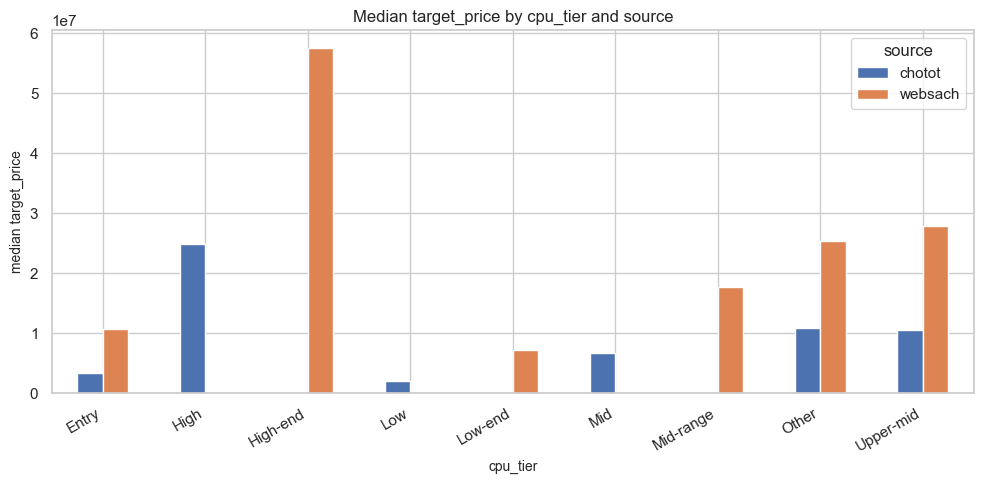

Saved figure: y:\Python\Laptop-Price-Prediction\reports\figures\eda\median_price_by_gpu_tier_source.png


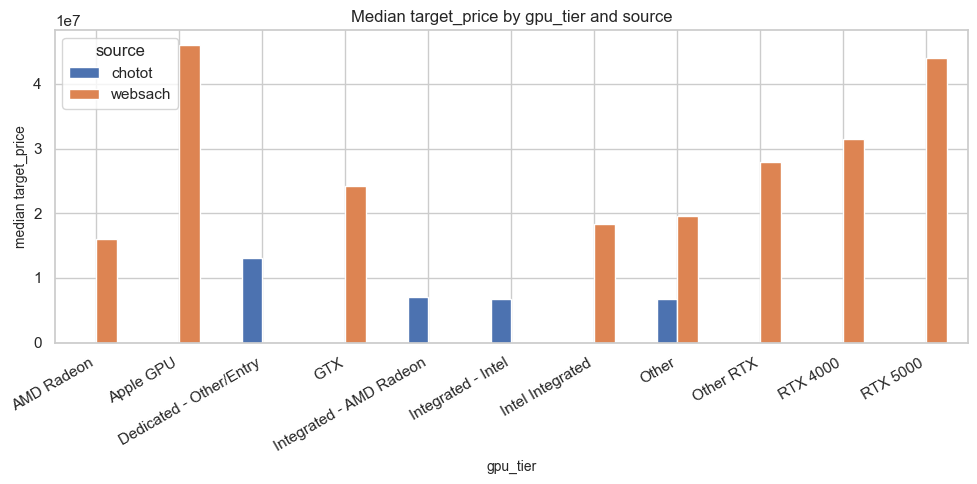

Saved figure: y:\Python\Laptop-Price-Prediction\reports\figures\eda\median_price_by_ram_bucket_eda_source.png


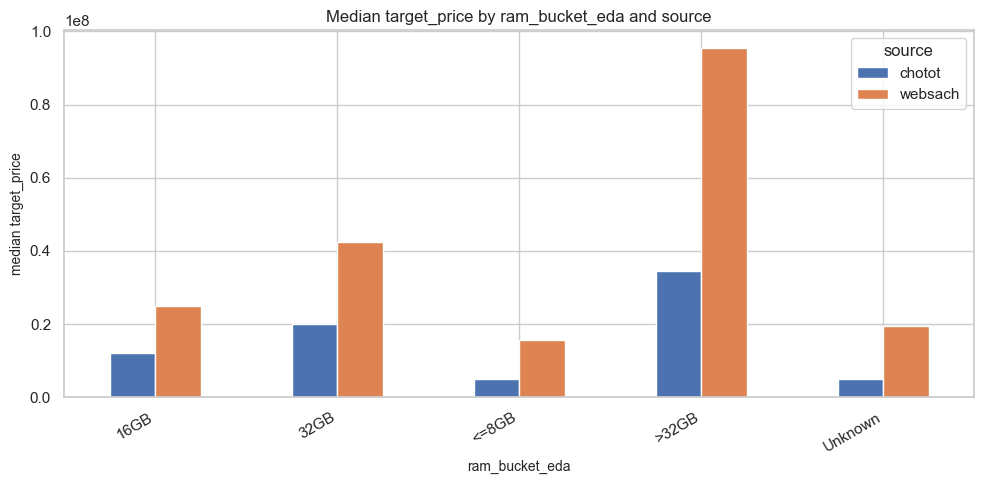

Saved figure: y:\Python\Laptop-Price-Prediction\reports\figures\eda\median_price_by_storage_bucket_eda_source.png


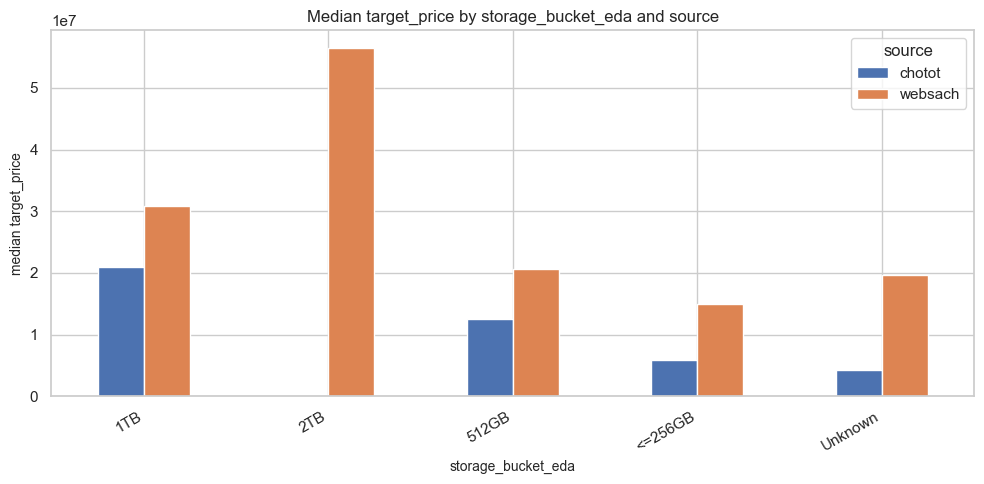

Saved figure: y:\Python\Laptop-Price-Prediction\reports\figures\eda\median_price_by_top_brand_source.png


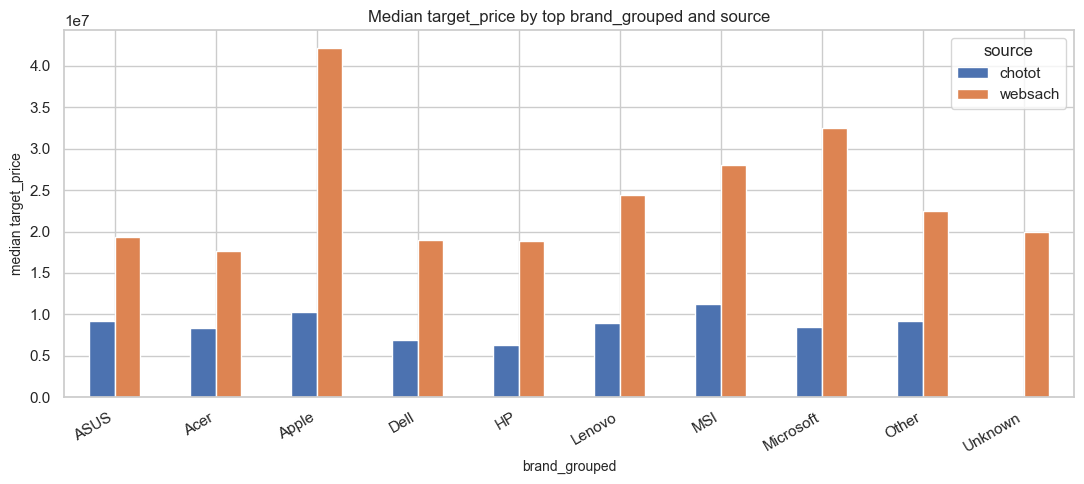

Interpretation: strong monotonic signals should carry into FE; source-divergent signals should be monitored with by-source evaluation and possibly later interactions.


In [209]:
eda_df["cpu_tier"] = df["cpu_tier"]
eda_df["gpu_tier"] = df["gpu_tier"]

for col in ["cpu_tier", "gpu_tier", "ram_bucket_eda", "storage_bucket_eda"]:
    if col not in eda_df: continue
    tab = median_price_table(eda_df, ["source", col], min_n=20)
    if tab.empty: continue
    pivot = tab.pivot(index=col, columns="source", values="median_target_price")
    plt.figure(figsize=(10, 5));
    pivot.plot(kind="bar", ax=plt.gca());
    plt.title(f"Median target_price by {col} and source");
    plt.ylabel("median target_price");
    plt.xticks(rotation=30, ha="right");
    save_current_fig(f"median_price_by_{col}_source");
    plt.show()

if "brand_grouped" in eda_df:
    top_brands = eda_df["brand_grouped"].fillna("Unknown").astype(str).value_counts().head(10).index
    brand_tab = median_price_table(eda_df[eda_df["brand_grouped"].fillna("Unknown").astype(str).isin(top_brands)], ["source", "brand_grouped"], min_n=20)
    if not brand_tab.empty:
        pivot = brand_tab.pivot(index="brand_grouped", columns="source", values="median_target_price")
        plt.figure(figsize=(11, 5)); pivot.plot(kind="bar", ax=plt.gca()); plt.title("Median target_price by top brand_grouped and source"); plt.ylabel("median target_price"); plt.xticks(rotation=30, ha="right"); save_current_fig("median_price_by_top_brand_source"); plt.show()
append_summary("price_signal", "tables_created", list(price_signal_tables.keys()))
print("Interpretation: strong monotonic signals should carry into FE; source-divergent signals should be monitored with by-source evaluation and possibly later interactions.")

### Nhận xét về các biến categorical và numeric

Qua các biểu đồ EDA, có thể thấy các biến categorical đang mang khá nhiều tín hiệu liên quan đến `target_price`. Đặc biệt, khi phân tích theo `source`, median price giữa hai nguồn `chotot` và `websach` có sự khác biệt rất rõ. Ở hầu hết các nhóm feature như CPU tier, GPU tier, RAM, storage và brand, giá median của `websach` thường cao hơn đáng kể so với `chotot`. Điều này cho thấy `source` là một biến rất quan trọng và nên được giữ lại trong mô hình.

Đối với các biến numeric như RAM, storage và screen size, mặc dù giá trị numeric gốc vẫn có ý nghĩa, việc chia bucket vẫn đem lại thêm thông tin hữu ích. Ví dụ, với RAM, các nhóm `<=8GB`, `16GB`, `32GB`, và `>32GB` thể hiện sự khác biệt rõ ràng về median price. Tương tự, storage cũng cho thấy giá có xu hướng tăng khi dung lượng tăng, đặc biệt ở các nhóm `1TB` và `2TB`. Tuy nhiên, quan hệ này không hoàn toàn tuyến tính, nên nếu chỉ sử dụng biến numeric gốc thì mô hình có thể không bắt được các bước nhảy giá giữa các phân khúc.

Vì vậy, hướng xử lý hợp lý là giữ cả biến numeric gốc và biến categorical bucket. Biến numeric giúp mô hình học xu hướng tổng quát, trong khi biến bucket giúp mô hình nhận biết các phân khúc thị trường cụ thể. Ví dụ, nên giữ đồng thời `ram_gb` và `ram_bucket_eda`, hoặc `storage_gb` và `storage_bucket_eda`.

Đối với `cpu_tier` và `gpu_tier`, đây là các biến categorical có thứ tự tương đối nhưng không nên ép hoàn toàn thành numeric. Các nhóm như `Low`, `Mid`, `High`, `High-end` có thể phản ánh thứ hạng hiệu năng,  `Other` lại mang ý nghĩa riêng.

Biến `gpu_tier` có tín hiệu khá mạnh, đặc biệt ở các nhóm GPU cao cấp như `RTX 4000`, `RTX 5000`, `Apple GPU`, hoặc các nhóm GPU rời khác. Tuy nhiên, số lượng nhóm khá nhiều và có thể không đồng đều giữa hai nguồn dữ liệu. Vì vậy, cần cân nhắc gom nhóm lại thành các phân khúc có ý nghĩa hơn, ví dụ như integrated GPU, entry dedicated GPU, GTX, RTX, high-end RTX, Apple GPU, AMD Radeon, Other và Unknown.

Biến `brand_grouped` cũng nên được giữ lại vì median price khác biệt khá rõ giữa các thương hiệu. Apple, Microsoft và MSI có xu hướng giá cao hơn, trong khi Acer, HP, Dell hoặc ASUS thường nằm ở phân khúc thấp hơn.

Một điểm cần lưu ý là không nên chỉ dựa vào median price khi đánh giá feature. Một số nhóm có median rất cao nhưng có thể do số lượng mẫu nhỏ. Vì vậy, khi phân tích các bucket hoặc categorical feature, cần kiểm tra thêm số lượng quan sát trong từng nhóm. Các nhóm có `n` quá nhỏ nên được gom lại hoặc xử lý cẩn thận để tránh overfitting.

Tổng kết lại, các biểu đồ cho thấy categorical features đang có tín hiệu mạnh và không nên bị loại bỏ chỉ vì biến numeric gốc vẫn hoạt động tốt. Cách tiếp cận phù hợp là thử nghiệm nhiều bộ feature khác nhau, bao gồm numeric only, categorical only, numeric kết hợp categorical, và numeric kết hợp categorical cùng interaction với `source`. Kết quả cross-validation sẽ là cơ sở cuối cùng để quyết định feature nào nên được giữ lại trong mô hình.

## 10a. Interaction analysis

In [210]:
eda_df["brand_grouped"] = df["brand_grouped"]
interaction_tables = {}
def interaction_analysis(row_col, col_col, title):
    if row_col not in eda_df.columns or col_col not in eda_df.columns:
        return
    tab = eda_df.groupby([row_col, col_col], dropna=False)["target_price"].agg(n="size", median_target_price="median").reset_index()
    tab = tab[tab["n"] >= 20]
    interaction_tables[f"{row_col}__{col_col}"] = tab
    print(f"\n{title} (n >= 20)")
    display(tab.sort_values("median_target_price", ascending=False).head(30))
    pivot = tab.pivot(index=row_col, columns=col_col, values="median_target_price")
    if not pivot.empty:
        plt.figure(figsize=(min(14, 4 + 0.6 * len(pivot.columns)), max(4, 0.45 * len(pivot))))
        if sns:
            sns.heatmap(pivot, annot=True, fmt=",.0f", cmap="YlGnBu")
        else:
            plt.imshow(pivot, aspect="auto", cmap="YlGnBu")
            plt.yticks(range(len(pivot)), pivot.index)
            plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=30)
            plt.colorbar()
        plt.title(f"Median target_price: {title}")
        save_current_fig(f"interaction_{row_col}_x_{col_col}_median_price")
        plt.show()


RAM bucket x Storage bucket (n >= 20)


,ram_bucket_eda,storage_bucket_eda,n,median_target_price
17,>32GB,2TB,32,"97,490,000.000"
6,32GB,2TB,39,"64,990,000.000"
16,>32GB,1TB,43,"61,990,000.000"
5,32GB,1TB,474,"40,599,500.000"
10,32GB,Unknown,21,"36,799,000.000"
0,16GB,1TB,563,"27,999,000.000"
7,32GB,512GB,330,"25,990,000.000"
12,<=8GB,2TB,45,"22,980,000.000"
4,16GB,Unknown,133,"20,990,000.000"
8,32GB,<=256GB,27,"17,900,000.000"


Saved figure: y:\Python\Laptop-Price-Prediction\reports\figures\eda\interaction_ram_bucket_eda_x_storage_bucket_eda_median_price.png


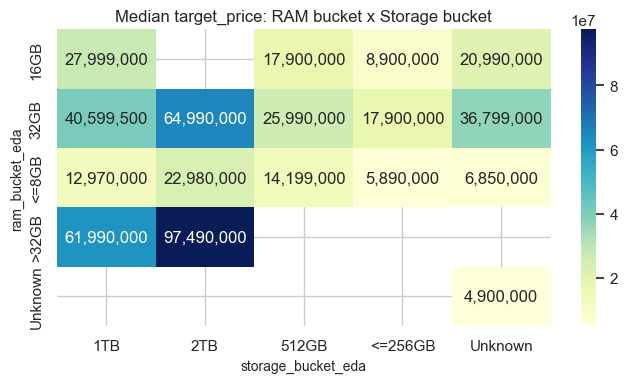

In [211]:
interaction_analysis("ram_bucket_eda", "storage_bucket_eda", "RAM bucket x Storage bucket")

### RAM × Storage interaction

Bảng và heatmap RAM bucket × Storage bucket cho thấy sự khác biệt median price rất rõ giữa các tổ hợp cấu hình. Nhìn chung, laptop có RAM cao hơn và storage lớn hơn có median price cao hơn. Các nhóm cao cấp như `>32GB RAM + 2TB storage`, `32GB RAM + 2TB storage`, và `>32GB RAM + 1TB storage` có median price vượt trội so với các nhóm còn lại.

Điều này cho thấy interaction giữa RAM và storage có thể mang tín hiệu mạnh cho mô hình. Vì vậy, ngoài việc giữ riêng `ram_gb`, `storage_gb`, `ram_bucket_eda`, và `storage_bucket_eda`, có thể cân nhắc thêm feature interaction như `ram_bucket_eda × storage_bucket_eda`, đặc biệt nếu sử dụng model tuyến tính hoặc model không tự học interaction tốt.

Các nhóm `Unknown` vẫn xuất hiện trong EDA vì dữ liệu đầu vào còn category `Unknown` hoặc missing được mã hóa thành `Unknown`. Trong plot chính, có thể loại bỏ các nhóm này để quan sát pattern rõ hơn. Tuy nhiên, trong modeling không nên xóa hoàn toàn `Unknown`, vì missing configuration cũng có thể là tín hiệu liên quan đến chất lượng listing hoặc phân khúc giá.


CPU tier x GPU tier (n >= 20)


,cpu_tier,gpu_tier,n,median_target_price
11,High-end,Apple GPU,24,"101,490,000.000"
17,High-end,RTX 5000,55,"59,790,000.000"
15,High-end,Other RTX,44,"59,295,000.000"
46,Upper-mid,Apple GPU,26,"56,395,000.000"
16,High-end,RTX 4000,82,"53,450,500.000"
44,Other,RTX 5000,26,"41,590,000.000"
42,Other,Other RTX,33,"39,990,000.000"
55,Upper-mid,RTX 5000,37,"38,900,000.000"
27,Mid-range,Apple GPU,65,"36,490,000.000"
53,Upper-mid,Other RTX,255,"33,990,000.000"


Saved figure: y:\Python\Laptop-Price-Prediction\reports\figures\eda\interaction_cpu_tier_x_gpu_tier_median_price.png


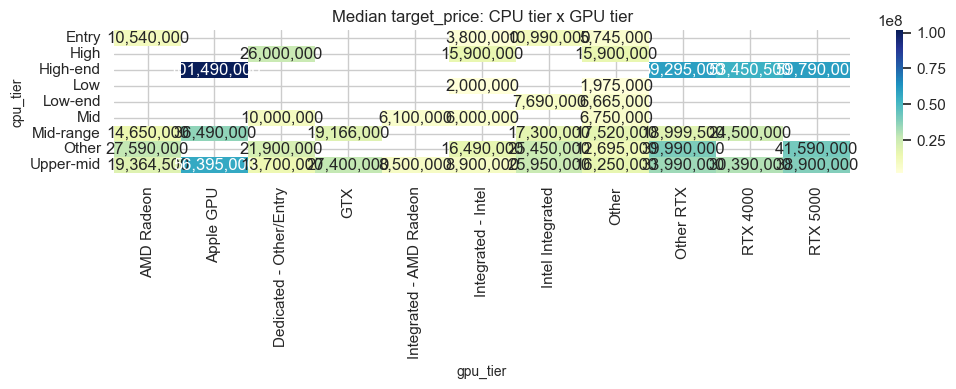

In [212]:
interaction_analysis("cpu_tier", "gpu_tier", "CPU tier x GPU tier")

### CPU tier × GPU tier interaction

Bảng và heatmap `CPU tier × GPU tier` cho thấy tổ hợp giữa CPU và GPU có tín hiệu rất mạnh đối với `target_price`. Các cấu hình cao cấp, đặc biệt là `High-end CPU` kết hợp với `Apple GPU`, `RTX 5000`, `Other RTX` hoặc `RTX 4000`, có median price cao nhất trong toàn bộ bảng. Điều này phù hợp với kỳ vọng vì các laptop dùng CPU và GPU cao cấp thường thuộc phân khúc workstation, gaming cao cấp hoặc laptop chuyên dụng.

Nhóm có median price cao nhất là `High-end CPU + Apple GPU`, với median khoảng 101 triệu. Tuy nhiên, nhóm này chỉ có 24 mẫu, nên cần cẩn thận khi diễn giải vì số lượng quan sát không quá lớn. Các tổ hợp như `High-end + RTX 5000`, `High-end + Other RTX`, và `High-end + RTX 4000` cũng có median price rất cao, dao động khoảng 53–60 triệu, cho thấy GPU rời cao cấp là một tín hiệu giá rất mạnh.

Ở nhóm `Upper-mid CPU`, các GPU cao cấp như `Apple GPU`, `RTX 5000`, `Other RTX`, và `RTX 4000` cũng làm median price tăng rõ rệt. Điều này cho thấy không chỉ CPU tier, mà GPU tier cũng đóng vai trò quan trọng trong việc phân biệt phân khúc giá. Ví dụ, cùng là `Upper-mid CPU`, nhưng median price thay đổi khá nhiều tùy GPU đi kèm.

Các nhóm `Mid-range CPU` kết hợp với GPU phổ thông hoặc integrated GPU có median price thấp hơn đáng kể. Những tổ hợp như `Mid-range + Intel Integrated`, `Mid-range + Other`, hoặc `Mid-range + AMD Radeon` nằm ở phân khúc trung bình thấp hơn so với các nhóm có RTX hoặc Apple GPU. Điều này cho thấy GPU rời, đặc biệt là RTX, có thể tạo ra bước nhảy giá lớn so với integrated GPU.

Một điểm đáng chú ý là một số nhóm như `Other`, `Integrated - Intel`, `Dedicated - Other/Entry`, hoặc `Other RTX` vẫn có median price khá khác nhau. Điều này cho thấy các nhóm GPU hiện tại vẫn còn hơi rộng và có thể chứa nhiều loại phần cứng khác nhau. Nếu muốn feature sạch hơn, có thể tiếp tục gom nhóm GPU theo cấp hiệu năng rõ ràng hơn, ví dụ: integrated GPU, entry dedicated GPU, GTX, RTX 4000, RTX 5000, Apple GPU, AMD Radeon, Other và Unknown.

Tuy nhiên, cần lưu ý rằng một số tổ hợp có số lượng mẫu nhỏ, ví dụ `High-end + Apple GPU` chỉ có 24 mẫu hoặc `Upper-mid + Apple GPU` chỉ có 26 mẫu. Các nhóm này có median price cao nhưng độ ổn định có thể chưa chắc chắn. Vì vậy, khi dùng cho feature engineering hoặc diễn giải mô hình, nên kết hợp median price với `n`, p25 và p75 để tránh kết luận quá mạnh từ các nhóm ít quan sát.

Tổng kết lại, interaction giữa `cpu_tier` và `gpu_tier` rất đáng giữ lại. Nếu sử dụng model tuyến tính hoặc model không tự học interaction tốt, nên tạo thêm feature kết hợp như `cpu_gpu_tier = cpu_tier + "_" + gpu_tier`. Nếu sử dụng CatBoost, LightGBM hoặc XGBoost, có thể giữ riêng `cpu_tier` và `gpu_tier`, đồng thời thử thêm interaction feature này và so sánh bằng cross-validation.


Brand grouped x CPU tier (n >= 20)


,brand_grouped,cpu_tier,n,median_target_price
20,Apple,High-end,25,"97,990,000.000"
60,MSI,High-end,51,"71,290,000.000"
2,ASUS,High-end,87,"52,150,000.000"
51,Lenovo,High-end,31,"37,590,000.000"
22,Apple,Mid-range,89,"33,090,000.000"
36,Gigabyte,Upper-mid,37,"30,990,000.000"
50,Lenovo,High,33,"28,990,000.000"
63,MSI,Other,44,"27,625,000.000"
70,Microsoft,Mid-range,33,"26,500,000.000"
1,ASUS,High,55,"25,490,000.000"


Saved figure: y:\Python\Laptop-Price-Prediction\reports\figures\eda\interaction_brand_grouped_x_cpu_tier_median_price.png


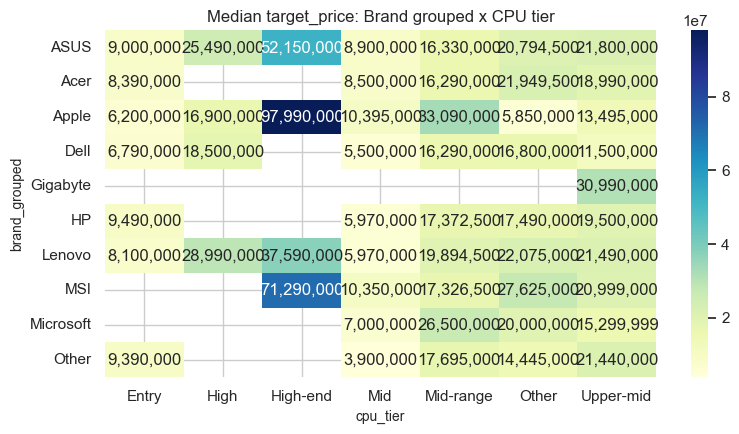

In [213]:
interaction_analysis("brand_grouped", "cpu_tier", "Brand grouped x CPU tier")

In [214]:
append_summary("interaction_analysis", "interaction_tables", {k: len(v) for k, v in interaction_tables.items()})
interaction_available = list(interaction_tables.keys())

### Brand grouped × CPU tier interaction

Bảng và heatmap `brand_grouped × cpu_tier` cho thấy thương hiệu và phân khúc CPU có tương tác khá rõ với `target_price`. Nhìn chung, các tổ hợp giữa brand cao cấp và CPU tier cao có median price cao hơn đáng kể so với các nhóm còn lại.

Nhóm có median price cao nhất là `Apple + High-end`, khoảng 98 triệu, dù số lượng mẫu chỉ là 25. Điều này cho thấy Apple ở phân khúc cấu hình cao có mức giá rất khác biệt so với phần lớn thị trường. Ngoài Apple, `MSI + High-end` cũng có median price rất cao, khoảng 71 triệu, phản ánh phân khúc gaming hoặc workstation cao cấp. `ASUS + High-end` cũng nằm ở nhóm giá cao, khoảng 52 triệu.

Một điểm đáng chú ý là cùng một CPU tier nhưng median price thay đổi khá nhiều theo brand. Ví dụ, trong nhóm `High-end`, Apple, MSI, ASUS và Lenovo có median price khác nhau rõ rệt. Điều này cho thấy `cpu_tier` một mình chưa đủ để mô tả phân khúc giá; brand vẫn đóng vai trò quan trọng trong việc định vị sản phẩm.

Ngược lại, cùng một brand nhưng median price cũng thay đổi theo CPU tier. Với ASUS, median price tăng mạnh ở nhóm `High-end` so với các nhóm `Entry`, `Mid-range`, `Other` hoặc `Upper-mid`. Với Lenovo, nhóm `High-end` và `High` có giá cao hơn đáng kể so với `Mid` hoặc `Entry`. Điều này cho thấy CPU tier vẫn là một tín hiệu kỹ thuật quan trọng bên trong từng brand.

Một số brand như HP, Dell, Acer thường nằm ở phân khúc giá thấp hoặc trung bình hơn trong cùng các nhóm CPU tier. Trong khi đó, Apple, MSI, Microsoft và một phần Lenovo có xu hướng nằm ở phân khúc giá cao hơn. Nhóm `Other` có median price khá biến động vì đây là nhóm gom nhiều brand khác nhau, nên cần diễn giải cẩn thận.

Cần lưu ý rằng một số tổ hợp có số lượng mẫu nhỏ, ví dụ `Apple + High-end` chỉ có 25 mẫu, `Microsoft + Mid-range` có 33 mẫu, hoặc `Gigabyte + Upper-mid` có 37 mẫu. Các median price ở những nhóm này có thể chưa ổn định, nên nên kiểm tra thêm p25, p75 hoặc boxplot trước khi kết luận chắc chắn.

Từ kết quả này, nên giữ cả `brand_grouped` và `cpu_tier` trong mô hình. Ngoài ra, có thể cân nhắc tạo thêm interaction feature như `brand_cpu_tier = brand_grouped + "_" + cpu_tier`, đặc biệt nếu sử dụng model tuyến tính hoặc model không tự học interaction tốt. Với các model tree-based như CatBoost, LightGBM hoặc XGBoost, có thể thử cả việc giữ riêng hai feature và thêm interaction, sau đó so sánh bằng cross-validation.

## 11. Source overlap and soft duplicate diagnostics

In [215]:
display_section("Source overlap and soft duplicate diagnostics")
duplicate_summary = {}
if "is_soft_duplicate_spec" in df:
    duplicate_summary["soft_duplicate_rows"] = int(df["is_soft_duplicate_spec"].fillna(False).astype(bool).sum())
if "is_cross_source_soft_duplicate" in df:
    duplicate_summary["cross_source_soft_duplicate_rows"] = int(df["is_cross_source_soft_duplicate"].fillna(False).astype(bool).sum())
if "merged_spec_key" in df:
    key_counts = df["merged_spec_key"].value_counts(dropna=True)
    duplicated_keys = key_counts[key_counts > 1]
    duplicate_summary["unique_duplicated_spec_keys"] = int(len(duplicated_keys))
    display(key_counts.head(20).rename_axis("merged_spec_key").reset_index(name="row_count"))
    source_composition = df[df["merged_spec_key"].isin(duplicated_keys.index)].groupby(["merged_spec_key", "source"], dropna=False).size().unstack(fill_value=0)
    source_composition["total"] = source_composition.sum(axis=1)
    display(source_composition.sort_values("total", ascending=False).head(20))
    overlapped_keys = source_composition[(source_composition.drop(columns="total") > 0).sum(axis=1) >= 2].index
    duplicate_summary["cross_source_overlapped_spec_keys"] = int(len(overlapped_keys))
    if len(overlapped_keys) > 0:
        price_by_key_source = df[df["merged_spec_key"].isin(overlapped_keys)].groupby(["merged_spec_key", "source"])["target_price"].agg(["count", "median"]).reset_index()
        med_pivot = price_by_key_source.pivot(index="merged_spec_key", columns="source", values="median")
        cnt_pivot = price_by_key_source.pivot(index="merged_spec_key", columns="source", values="count")
        if {"chotot", "websach"}.issubset(set(med_pivot.columns)):
            gap = pd.DataFrame({"chotot_median_price": med_pivot["chotot"], "websach_median_price": med_pivot["websach"], "chotot_count": cnt_pivot.get("chotot"), "websach_count": cnt_pivot.get("websach")}).dropna(subset=["chotot_median_price", "websach_median_price"])
            gap["price_gap_abs"] = gap["websach_median_price"] - gap["chotot_median_price"]
            gap["price_gap_pct"] = gap["price_gap_abs"] / gap["websach_median_price"].replace(0, np.nan)
            display(gap.reindex(gap["price_gap_abs"].abs().sort_values(ascending=False).index).head(20))
            duplicate_summary["median_overlap_price_gap_pct"] = float(gap["price_gap_pct"].median()) if not gap.empty else None
append_summary("duplicate_overlap", "duplicate_summary", duplicate_summary)
display(pd.DataFrame([duplicate_summary]).T.rename(columns={0: "value"}))
print("Interpretation: do not drop cross-source soft duplicates by default. Use overlap to understand price differences and evaluate by source if gaps look systematic.")


Source overlap and soft duplicate diagnostics


,merged_spec_key,row_count
0,Dell|Latitude|Intel|Mid|8|256|13.9|Integrated ...,84
1,Dell|Latitude|Intel|Upper-mid|16|256|13.9|Inte...,61
2,Dell|Precision|Intel|Upper-mid|16|512|15.9|Ded...,58
3,Dell|Latitude|Intel|Upper-mid|8|256|13.9|Integ...,55
4,Dell|Other|Intel|Upper-mid|16|512|15.9|Dedicat...,50
5,Lenovo|Unknown|Intel|Upper-mid|16|512|14.0|Int...,46
6,Dell|Dòng Khác|Intel|Mid|8|256|13.9|Integrated...,40
7,Dell|Latitude|Intel|Mid|16|256|13.9|Integrated...,40
8,Dell|Other|Intel|Mid|8|256|13.9|Integrated - I...,39
9,ASUS|Unknown|Intel|Mid-range|8|512|14.0|Intel ...,34


source,chotot,websach,total
merged_spec_key,,,
Dell|Latitude|Intel|Mid|8|256|13.9|Integrated - Intel,84,0,84
Dell|Latitude|Intel|Upper-mid|16|256|13.9|Integrated - Intel,61,0,61
Dell|Precision|Intel|Upper-mid|16|512|15.9|Dedicated - Other/Entry,58,0,58
Dell|Latitude|Intel|Upper-mid|8|256|13.9|Integrated - Intel,55,0,55
Dell|Other|Intel|Upper-mid|16|512|15.9|Dedicated - Other/Entry,50,0,50
Lenovo|Unknown|Intel|Upper-mid|16|512|14.0|Intel Integrated,0,46,46
Dell|Latitude|Intel|Mid|16|256|13.9|Integrated - Intel,40,0,40
Dell|Dòng Khác|Intel|Mid|8|256|13.9|Integrated - Intel,40,0,40
Dell|Other|Intel|Mid|8|256|13.9|Integrated - Intel,39,0,39


,value
soft_duplicate_rows,2514
cross_source_soft_duplicate_rows,0
unique_duplicated_spec_keys,1530
cross_source_overlapped_spec_keys,0


Interpretation: do not drop cross-source soft duplicates by default. Use overlap to understand price differences and evaluate by source if gaps look systematic.


### Source overlap and soft duplicate diagnostics

Kết quả kiểm tra soft duplicate cho thấy có khá nhiều dòng bị trùng cấu hình ở mức `merged_spec_key`. Tổng cộng có `2,514` dòng thuộc các nhóm soft duplicate, tương ứng với `1,530` cấu hình bị lặp lại. Điều này là bình thường trong dữ liệu laptop, vì nhiều listing có thể cùng brand, model, CPU tier, RAM, storage, screen size và GPU tier nhưng khác tình trạng máy, giá bán, người bán hoặc thời điểm đăng.

Điểm quan trọng là số lượng `cross_source_soft_duplicate_rows` bằng `0` và `cross_source_overlapped_spec_keys` cũng bằng `0`. Điều này cho thấy các cấu hình bị lặp không xuất hiện đồng thời ở cả hai nguồn `chotot` và `websach`. Nói cách khác, soft duplicates chủ yếu là trùng lặp bên trong từng source, không phải là overlap trực tiếp giữa hai source.

Bảng phân rã theo source cũng xác nhận điều này. Các `merged_spec_key` phổ biến nhất thường chỉ có count ở một source và bằng `0` ở source còn lại. Ví dụ, nhiều cấu hình Dell Latitude xuất hiện nhiều trong `chotot`, trong khi một số cấu hình Lenovo, ASUS, HP hoặc Dell Unknown lại xuất hiện nhiều trong `websach`. Điều này cho thấy mỗi source có phân phối sản phẩm khác nhau, không chỉ khác nhau về giá.

Vì không có overlap cross-source, không nên drop các soft duplicate theo `merged_spec_key` một cách mặc định. Nếu xóa các dòng này, ta có thể làm mất thông tin quan trọng về tần suất xuất hiện của một cấu hình trên thị trường. Thay vào đó, nên giữ lại các dòng này cho EDA và modeling, nhưng cần đánh giá mô hình theo `source` để đảm bảo model không học lệch quá nhiều theo từng nguồn.

Soft duplicate vẫn có thể ảnh hưởng đến validation nếu cùng một cấu hình xuất hiện nhiều lần trong train và validation. Điều này có thể làm validation score lạc quan hơn thực tế, vì model đã thấy cấu hình rất giống trong train. Vì vậy, khi đánh giá mô hình, nên cân nhắc thêm một chiến lược validation theo nhóm, ví dụ group split theo `merged_spec_key`, hoặc ít nhất so sánh kết quả giữa random split và grouped split.

Tổng kết lại, dữ liệu có soft duplicate ở mức cấu hình, nhưng không có duplicate chéo giữa `chotot` và `websach`. Do đó, không nên loại bỏ các dòng này ngay. Thay vào đó, nên dùng thông tin này để thiết kế validation chắc hơn và theo dõi performance riêng theo từng source.

## 12. Source-specific diagnostics


Source-specific diagnostics


,flag,source,count_true,rate_true,median_price_true,median_price_false
0,flag_price_spread_warn,chotot,0,0.000,NaN,"7,890,000.000"
1,flag_price_spread_warn,websach,583,0.133,"18,006,229.000","21,690,000.000"
2,flag_price_spread_critical,chotot,0,0.000,NaN,"7,890,000.000"
3,flag_price_spread_critical,websach,142,0.032,"13,944,500.000","21,490,000.000"
4,repair_mismatch,chotot,16,0.003,"4,845,000.000","7,900,000.000"
5,repair_mismatch,websach,0,0.000,NaN,"21,195,000.000"
6,potential_dedicated_gpu,chotot,40,0.007,"7,850,000.000","7,890,000.000"
7,potential_dedicated_gpu,websach,0,0.000,NaN,"21,195,000.000"
8,ram_suspicious,chotot,21,0.004,"33,890,000.000","7,890,000.000"
9,ram_suspicious,websach,0,0.000,NaN,"21,195,000.000"


,source,count,mean,median,std,min,p05,p25,p75,p95,max
0,chotot,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,websach,4382,0.148,0.099,0.150,0.000,0.011,0.044,0.207,0.439,1.267


Saved figure: y:\Python\Laptop-Price-Prediction\reports\figures\eda\price_spread_clean_pct_hist.png


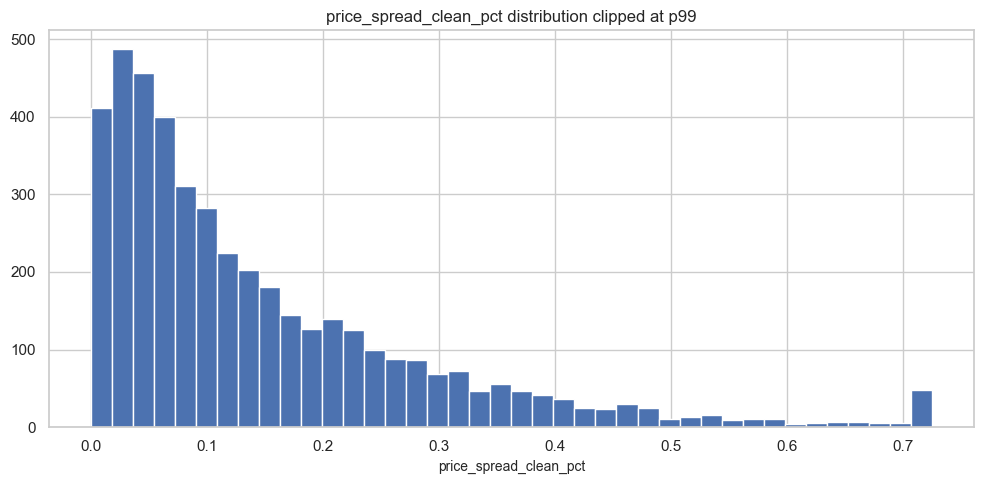

Interpretation: Websach price spread flags are audit/evaluation filters, not baseline features. Chợ Tốt repair/spec flags may be usable if they are not target-derived.


In [216]:
display_section("Source-specific diagnostics")
source_flag_cols = [c for c in ["flag_price_spread_warn", "flag_price_spread_critical", "repair_mismatch", "potential_dedicated_gpu", "ram_suspicious"] if c in df]
flag_rows = []
for col in source_flag_cols:
    for src, part in df.groupby("source", dropna=False):
        f = part[col].fillna(False).astype(bool)
        flag_rows.append({"flag": col, "source": src, "count_true": int(f.sum()), "rate_true": float(f.mean()), "median_price_true": float(part.loc[f, "target_price"].median()) if f.any() else np.nan, "median_price_false": float(part.loc[~f, "target_price"].median()) if (~f).any() else np.nan})
flag_summary = pd.DataFrame(flag_rows)
display(flag_summary)
append_summary("source_specific_diagnostics", "flag_summary", flag_summary.to_dict("records"))
if "price_spread_clean_pct" in df:
    display(numeric_summary_by_group(df, "price_spread_clean_pct", "source"))
    plt.figure(); df["price_spread_clean_pct"].dropna().clip(upper=df["price_spread_clean_pct"].quantile(0.99)).hist(bins=40); plt.title("price_spread_clean_pct distribution clipped at p99"); plt.xlabel("price_spread_clean_pct"); save_current_fig("price_spread_clean_pct_hist"); plt.show()
print("Interpretation: Websach price spread flags are audit/evaluation filters, not baseline features. Chợ Tốt repair/spec flags may be usable if they are not target-derived.")

### Source-specific diagnostics

Kết quả source-specific diagnostics cho thấy một số flag chỉ xuất hiện ở một nguồn dữ liệu nhất định, vì vậy cần xử lý cẩn thận khi dùng làm feature cho mô hình.

Hai flag `flag_price_spread_warn` và `flag_price_spread_critical` chỉ xuất hiện ở `websach`, trong khi `chotot` hoàn toàn không có dòng nào được gắn flag này. Cụ thể, `flag_price_spread_warn` xuất hiện ở khoảng 13.3% dữ liệu `websach`, còn `flag_price_spread_critical` xuất hiện ở khoảng 3.2%. Đây là dấu hiệu cho thấy các flag này phụ thuộc vào logic kiểm tra giá riêng của nguồn `websach`, không phải là thông tin cấu hình laptop phổ quát giữa hai nguồn.

Median price của nhóm bị gắn `price_spread` flag thấp hơn median của nhóm không bị gắn flag trong `websach`. Ví dụ, nhóm `flag_price_spread_warn = True` có median price khoảng 18.0 triệu, thấp hơn nhóm False khoảng 21.7 triệu. Tương tự, nhóm `flag_price_spread_critical = True` có median price khoảng 13.9 triệu, thấp hơn nhóm False khoảng 21.5 triệu. Điều này cho thấy các flag này có liên quan đến target price, nhưng cũng làm tăng rủi ro leakage nếu chúng được tạo từ thông tin giá hoặc spread giá.

Phân phối `price_spread_clean_pct` cũng chỉ có giá trị ở `websach`, với 4,382 dòng. Median khoảng 9.9%, p75 khoảng 20.7%, p95 khoảng 43.9%, và max khoảng 126.7%. Histogram bị lệch phải rõ rệt, nghĩa là phần lớn sản phẩm có spread giá tương đối thấp, nhưng vẫn tồn tại một nhóm nhỏ có spread rất cao. Đây là biến phù hợp để audit chất lượng dữ liệu hoặc phát hiện listing bất thường, nhưng không nên dùng làm baseline feature nếu biến này được tính trực tiếp từ giá.

Các flag như `repair_mismatch`, `potential_dedicated_gpu`, và `ram_suspicious` lại chủ yếu hoặc chỉ xuất hiện ở `chotot`. Tần suất của chúng khá thấp, ví dụ `repair_mismatch` khoảng 0.3%, `potential_dedicated_gpu` khoảng 0.7%, và `ram_suspicious` khoảng 0.4%. Vì các flag này có vẻ liên quan đến chất lượng parsing hoặc mâu thuẫn thông số kỹ thuật, chúng có thể được cân nhắc dùng làm feature nếu chắc chắn không được tạo từ `target_price`.

Tóm lại, các flag liên quan đến `price_spread` nên được xem là audit/evaluation filters thay vì baseline features, vì chúng có khả năng target-derived và chỉ tồn tại ở `websach`. Ngược lại, các flag về repair/spec mismatch ở `chotot` có thể hữu ích cho mô hình nếu chúng chỉ dựa trên thông tin text/spec và không sử dụng target. Khi đánh giá mô hình, nên theo dõi performance riêng theo từng `source`, vì các flag và phân phối dữ liệu giữa `chotot` và `websach` khác nhau rõ rệt.

## 13. Leakage and audit column review

In [217]:
display_section("Leakage and audit column review")
always_exclude = ["target_price", "log_target_price", "target_price_source", "target_price_is_outlier", "target_price_missing", "source_row_id", "merged_row_id", "url", "title", "merged_spec_key"]
usually_exclude = ["source", "is_cross_source_soft_duplicate"]
price_sensitive = ["flag_price_spread_warn", "flag_price_spread_critical", "price_spread_clean_pct"]
old_chotot_leakage = ["_price", "price", "price_segment", "is_price_missing", "is_price_outlier", "new_low_price"]
old_websach_leakage = ["shop_1_price", "shop_2_price", "shop_3_price", "shop_1_price_clean", "shop_2_price_clean", "shop_3_price_clean", "shop_1_price_domain", "shop_2_price_domain", "shop_3_price_domain", "price_row_median_domain", "price_median", "price_min_clean", "price_max_clean", "log_price_median", "price_segment"]
old_leakage_present = [c for c in old_chotot_leakage + old_websach_leakage if c in df.columns]
review = {"always_exclude_present": [c for c in always_exclude if c in df.columns], "usually_exclude_present": [c for c in usually_exclude if c in df.columns], "price_sensitive_present": [c for c in price_sensitive if c in df.columns], "old_source_specific_leakage_present": old_leakage_present, "old_source_specific_leakage_absent_ok": len(old_leakage_present) == 0}
display(pd.Series(review).to_frame("value"))
append_summary("leakage_review", "review", review)
print("OK: old source-specific leakage columns are absent." if not old_leakage_present else f"Warning: old leakage columns are present: {old_leakage_present}")


Leakage and audit column review


,value
always_exclude_present,"[target_price, log_target_price, target_price_..."
usually_exclude_present,"[source, is_cross_source_soft_duplicate]"
price_sensitive_present,"[flag_price_spread_warn, flag_price_spread_cri..."
old_source_specific_leakage_present,[]
old_source_specific_leakage_absent_ok,True


OK: old source-specific leakage columns are absent.


### Leakage and audit column review

Phần review này dùng để phân loại các cột có rủi ro leakage hoặc không nên đưa trực tiếp vào baseline model. Kết quả cho thấy các cột target-related như `target_price`, `log_target_price`, `target_price_source`, `target_price_is_outlier`, `target_price_missing`, cùng các cột định danh như `source_row_id`, `merged_row_id`, `url`, `title`, `merged_spec_key` đang được nhận diện trong nhóm `always_exclude_present`. Đây là các cột nên loại khỏi feature set vì chúng là target, biến dẫn xuất từ target, hoặc metadata/identifier không phản ánh đặc trưng cấu hình laptop.

Nhóm `usually_exclude_present` gồm `source` và `is_cross_source_soft_duplicate`. Riêng `source` là trường hợp đặc biệt: về mặt audit, nó cần được theo dõi vì hai nguồn dữ liệu có phân phối giá và đặc điểm listing rất khác nhau. Tuy nhiên, nếu bài toán dự đoán trong thực tế biết trước nguồn dữ liệu của listing, thì `source` có thể được giữ như một feature. Ngược lại, nếu muốn mô hình tổng quát hóa sang nguồn mới hoặc tránh phụ thuộc quá mạnh vào domain/source, nên đánh giá thêm mô hình không dùng `source`.

Các cột trong nhóm `price_sensitive_present` gồm `flag_price_spread_warn`, `flag_price_spread_critical`, và `price_spread_clean_pct`. Đây là các biến nhạy cảm vì có khả năng được tạo từ logic kiểm tra spread hoặc thông tin liên quan đến giá. Do đó, không nên dùng chúng làm baseline features, đặc biệt nếu chúng được tính trực tiếp hoặc gián tiếp từ `target_price`. Các cột này phù hợp hơn cho audit dữ liệu, lọc bất thường, hoặc phân tích chất lượng nguồn dữ liệu.

Kết quả cũng cho thấy các cột leakage cũ theo từng source không còn xuất hiện trong dataframe hiện tại. Cụ thể, `old_source_specific_leakage_present` là danh sách rỗng và `old_source_specific_leakage_absent_ok = True`. Điều này cho thấy các cột giá cũ như `shop_1_price`, `shop_2_price`, `price_min_clean`, `price_median`, `price_segment`, hoặc các biến tương tự đã được loại bỏ thành công khỏi dữ liệu dùng cho modeling.

Tổng kết lại, baseline feature set nên loại bỏ toàn bộ nhóm `always_exclude`, không dùng các biến `price_spread` làm feature chính, và xử lý `source` như một biến cần thử nghiệm có kiểm soát. Nên chạy ít nhất hai cấu hình model: một cấu hình có `source` và một cấu hình không có `source`, sau đó so sánh cross-validation và performance theo từng source để đánh giá mức độ phụ thuộc của mô hình vào nguồn dữ liệu.

## 14. FE recommendations

In [218]:
display_section("FE recommendations")
missing_rate_lookup = missing_table.set_index("column")["overall_missing_like_rate"].to_dict() if "missing_table" in globals() else {}
recommended_numeric_features = [c for c in existing_numeric_candidates if missing_rate_lookup.get(c, 0.0) < 0.95]
recommended_categorical_features = [c for c in ["brand_grouped", "model_grouped", "cpu_brand", "cpu_tier", "gpu_tier", "storage_type_clean", "condition_clean", "warranty_status", "origin_clean"] if c in df.columns]
non_price_boolean = ["brand_is_rare", "model_is_rare", "ram_missing", "storage_missing", "screen_missing", "cpu_missing", "gpu_missing", "ram_suspicious", "storage_suspicious", "screen_suspicious", "potential_dedicated_gpu", "repair_mismatch", "is_soft_duplicate_spec"]
recommended_boolean_features = [c for c in non_price_boolean if c in df.columns]
feature_recommendations = {
    "label_columns": [c for c in ["target_price", "log_target_price"] if c in df.columns],
    "recommended_target_strategy": {"keep_both_raw_and_log_target": True, "compare_raw_vs_log_models": True, "main_baseline_likely_uses_log_target": bool(recommend_log_target), "reason": "Raw target is right-skewed or has a high p95/median ratio." if recommend_log_target else "Raw target skew is moderate, but log target remains useful for comparison."},
    "recommended_split_strategy": {"primary": "Stratified split by source + price_bin if feasible.", "fallback": "Stratify by source.", "reporting": "Report metrics overall and by source."},
    "recommended_numeric_features": recommended_numeric_features,
    "recommended_engineered_numeric_features_for_next_notebook": ["log_storage_gb", "ram_storage_ratio", "ram_x_storage", "screen_x_ram", "storage_per_ram"],
    "recommended_categorical_features": recommended_categorical_features,
    "recommended_boolean_features": recommended_boolean_features,
    "audit_or_exclude_columns": sorted(set([c for c in existing_label_cols + existing_audit_cols + ["source", "target_price_source", "merged_spec_key", "is_cross_source_soft_duplicate"] if c in df.columns])),
    "price_derived_or_sensitive_flags_to_exclude_from_baseline": [c for c in price_sensitive if c in df.columns],
    "preprocessing_recommendation": {"numeric": "Median imputation + StandardScaler.", "categorical": "Unknown imputation + OneHotEncoder(handle_unknown='ignore').", "boolean": "Fill missing with False or most_frequent, then convert to int.", "high_cardinality_categorical": "Use grouped columns first; avoid raw model/brand columns unless controlled."},
    "source_bias_recommendation": {"baseline_feature_policy": "Do not include source in baseline feature set.", "evaluation": "Always evaluate metrics by source.", "later_experiment": "Run a source-included experiment to compare performance and source bias."},
    "eda_evidence": {"rows_by_source": source_counts["n"].to_dict() if "source_counts" in globals() else {}, "median_target_price_by_source": median_by_source.to_dict() if "median_by_source" in globals() else {}, "raw_target_skew": raw_skew if "raw_skew" in globals() else None, "p95_median_ratio": p95_median_ratio if "p95_median_ratio" in globals() else None, "highest_missing_like_columns": missing_table.head(10).set_index("column")["overall_missing_like_rate"].to_dict() if "missing_table" in globals() else {}, "duplicate_summary": duplicate_summary if "duplicate_summary" in globals() else {}},
}
display(feature_recommendations)
append_summary("recommendations", "feature_recommendations_created", True)


FE recommendations


{'label_columns': ['target_price', 'log_target_price'],
 'recommended_target_strategy': {'keep_both_raw_and_log_target': True,
  'compare_raw_vs_log_models': True,
  'main_baseline_likely_uses_log_target': True,
  'reason': 'Raw target is right-skewed or has a high p95/median ratio.'},
 'recommended_split_strategy': {'primary': 'Stratified split by source + price_bin if feasible.',
  'fallback': 'Stratify by source.',
  'reporting': 'Report metrics overall and by source.'},
 'recommended_numeric_features': ['ram_gb',
  'storage_gb',
  'screen_size_inch',
  'warranty_months'],
 'recommended_engineered_numeric_features_for_next_notebook': ['log_storage_gb',
  'ram_storage_ratio',
  'ram_x_storage',
  'screen_x_ram',
  'storage_per_ram'],
 'recommended_categorical_features': ['brand_grouped',
  'model_grouped',
  'cpu_brand',
  'cpu_tier',
  'gpu_tier',
  'storage_type_clean',
  'condition_clean',
  'warranty_status',
  'origin_clean'],
 'recommended_boolean_features': ['brand_is_rare',
 

### Modeling recommendations from EDA

Từ kết quả EDA, bài toán nên giữ cả hai target là `target_price` và `log_target_price` để thử nghiệm. Phân phối giá gốc bị lệch phải khá rõ, với skew khoảng `2.75` và tỷ lệ `p95 / median` khoảng `3.37`. Điều này cho thấy các mẫu giá cao kéo đuôi phân phối khá mạnh, vì vậy baseline chính nhiều khả năng nên train trên `log_target_price`, sau đó inverse transform về giá gốc khi đánh giá. Tuy nhiên, vẫn nên so sánh trực tiếp giữa model train trên raw target và log target để kiểm chứng bằng cross-validation.

Về chiến lược chia dữ liệu, nên ưu tiên stratified split theo `source` kết hợp với `price_bin` nếu số lượng mẫu trong từng nhóm đủ lớn. Lý do là hai nguồn dữ liệu có phân phối giá rất khác nhau: `chotot` có median target price khoảng `7.89M`, trong khi `websach` khoảng `21.20M`. Nếu không stratify theo source và price range, validation set có thể không đại diện tốt cho train set. Nếu stratify theo cả source và price bin không khả thi, fallback nên là stratify theo `source`. Khi báo cáo kết quả, cần luôn trình bày metric tổng thể và metric riêng cho từng source.

Feature numeric nên bắt đầu với các biến cấu hình chính như `ram_gb`, `storage_gb`, `screen_size_inch`, và `warranty_months`. Ngoài ra, có thể tạo thêm một số engineered numeric features cho notebook tiếp theo như `log_storage_gb`, `ram_storage_ratio`, `ram_x_storage`, `screen_x_ram`, và `storage_per_ram`. Các feature này phản ánh interaction giữa cấu hình phần cứng và có thể giúp model bắt được các quan hệ phi tuyến tốt hơn.

Các categorical features nên dùng bản đã grouped hoặc cleaned, bao gồm `brand_grouped`, `model_grouped`, `cpu_brand`, `cpu_tier`, `gpu_tier`, `storage_type_clean`, `condition_clean`, `warranty_status`, và `origin_clean`. Không nên dùng trực tiếp raw brand/model nếu cardinality cao hoặc dữ liệu quá nhiễu; thay vào đó nên ưu tiên các cột grouped để giảm overfitting và giúp mô hình ổn định hơn.

Các boolean features nên giữ nếu chúng không được tạo từ target hoặc giá. Nhóm này gồm các flag như `brand_is_rare`, `model_is_rare`, các missing flags (`ram_missing`, `storage_missing`, `screen_missing`, `cpu_missing`, `gpu_missing`), các suspicious flags (`ram_suspicious`, `storage_suspicious`, `screen_suspicious`), cùng với `potential_dedicated_gpu`, `repair_mismatch`, và `is_soft_duplicate_spec`. Những biến này có thể phản ánh chất lượng listing, độ đầy đủ thông tin hoặc bất thường trong parsing.

Một số cột cần loại khỏi baseline feature set vì là target, metadata, identifier hoặc có rủi ro leakage. Nhóm này bao gồm `target_price`, `log_target_price`, `target_price_source`, `target_price_is_outlier`, `target_price_missing`, `source_row_id`, `merged_row_id`, `url`, `title`, và `merged_spec_key`. Ngoài ra, các biến như `flag_price_spread_warn`, `flag_price_spread_critical`, và `price_spread_clean_pct` nên được loại khỏi baseline vì có khả năng price-derived hoặc source-specific. Chúng phù hợp hơn cho audit hoặc evaluation filter, không nên dùng làm feature chính.

Với `source`, baseline nên không đưa biến này vào feature set để tránh mô hình phụ thuộc quá mạnh vào khác biệt giữa hai nguồn. Tuy nhiên, vì EDA cho thấy source có ảnh hưởng rất lớn đến median price, nên cần luôn đánh giá metric riêng theo source. Sau baseline, nên chạy thêm một experiment có thêm `source` để so sánh performance và kiểm tra mức độ source bias. Nếu model có `source` cải thiện mạnh nhưng performance lệch giữa hai nguồn, cần cân nhắc mục tiêu triển khai thực tế trước khi quyết định giữ biến này.

Về preprocessing, numeric features nên dùng median imputation kết hợp với standard scaling. Categorical features nên đi qua unknown imputation và `OneHotEncoder(handle_unknown='ignore')`. Boolean features có thể fill missing bằng `False` hoặc `most_frequent`, sau đó convert sang integer. Với các categorical có cardinality cao, nên ưu tiên grouped columns trước và chỉ dùng raw columns khi đã có kiểm soát rõ ràng.

Cuối cùng, duplicate diagnostics cho thấy có `2,514` dòng thuộc nhóm soft duplicate và `1,530` duplicated spec keys, nhưng không có overlap cross-source. Vì vậy không nên drop các soft duplicate theo mặc định. Tuy nhiên, để đánh giá mô hình chắc hơn, có thể so sánh thêm random split với group split theo `merged_spec_key`, nhằm kiểm tra xem validation score có bị lạc quan do cùng cấu hình xuất hiện ở cả train và validation hay không.

## 14a. Baseline leakage sanity check

In [219]:
display_section("Baseline leakage sanity check")

baseline_feature_list = []
if "feature_recommendations" in globals():
    baseline_feature_list = (
        feature_recommendations.get("recommended_numeric_features", [])
        + feature_recommendations.get("recommended_categorical_features", [])
        + feature_recommendations.get("recommended_boolean_features", [])
    )
baseline_feature_list = [c for c in dict.fromkeys(baseline_feature_list) if c in df.columns]

forbidden_baseline_columns = set([c for c in always_exclude + usually_exclude + price_sensitive if c in df.columns])
if isinstance(leakage_columns, dict):
    for v in leakage_columns.values():
        if isinstance(v, list):
            forbidden_baseline_columns.update([c for c in v if c in df.columns])
forbidden_baseline_columns.update([c for c in old_chotot_leakage + old_websach_leakage if c in df.columns])

baseline_leakage_hits = sorted(set(baseline_feature_list).intersection(forbidden_baseline_columns))
baseline_missing_cols = [c for c in baseline_feature_list if c not in df.columns]
leakage_sanity = {"baseline_feature_count": len(baseline_feature_list), "forbidden_hits": baseline_leakage_hits, "missing_cols": baseline_missing_cols}
display(pd.Series(leakage_sanity).to_frame("value"))
append_summary("baseline_leakage_sanity", "result", leakage_sanity)

if baseline_leakage_hits:
    raise ValueError(f"Baseline feature list contains leakage/audit columns: {baseline_leakage_hits}")
if baseline_missing_cols:
    raise ValueError(f"Baseline feature list contains missing columns: {baseline_missing_cols}")
print(f"OK: baseline feature list has {len(baseline_feature_list)} columns and no target/audit/identifier/price-derived leakage columns.")

feature_recommendations["baseline_feature_list"] = baseline_feature_list
feature_recommendations["baseline_leakage_sanity_check"] = leakage_sanity
if "feature_coverage" in globals():
    feature_recommendations["feature_coverage_low_coverage_flags"] = low_coverage_features


Baseline leakage sanity check


,value
baseline_feature_count,26
forbidden_hits,[]
missing_cols,[]


OK: baseline feature list has 26 columns and no target/audit/identifier/price-derived leakage columns.


### Baseline leakage sanity check

Baseline leakage sanity check cho thấy feature list hiện tại có `26` cột và không phát hiện cột leakage. Cụ thể, `forbidden_hits` là danh sách rỗng, nghĩa là baseline feature set không chứa các cột target, audit, identifier hoặc price-derived đã được đánh dấu cần loại bỏ. Đồng thời, `missing_cols` cũng rỗng, cho thấy tất cả các feature được chọn đều tồn tại trong dataframe hiện tại.

Kết quả này xác nhận baseline feature list đã đủ an toàn để dùng cho bước modeling đầu tiên. Các cột như `target_price`, `log_target_price`, `url`, `title`, `merged_spec_key`, các cột audit, và các flag liên quan đến `price_spread` đã không bị đưa nhầm vào feature set.

Tuy nhiên, đây chỉ là bước kiểm tra leakage theo danh sách cấm đã định nghĩa trước. Trong các bước tiếp theo, vẫn cần tiếp tục theo dõi performance theo từng `source`, so sánh mô hình train trên raw target và log target, đồng thời kiểm tra thêm validation strategy để tránh score quá lạc quan do soft duplicates.

# ADDITIVE
Bổ sung feature, ta phân tích 4 feature được thêm vào sau bao gồm: `cpu_name_raw`, `cpu_type`, `cpu_model_clean`, `gpu_tier_v2`

In [220]:
NEW_FEATURES = ["cpu_name_raw", "cpu_type", "cpu_model_clean", "gpu_tier_v2"]

feature_overview = []

for col in NEW_FEATURES:
    s = df[col]
    feature_overview.append({
        "feature": col,
        "dtype": str(s.dtype),
        "n_rows": len(s),
        "n_missing": s.isna().sum(),
        "missing_pct": s.isna().mean() * 100,
        "n_non_missing": s.notna().sum(),
        "n_unique": s.nunique(dropna=True),
        "unique_pct_on_non_missing": (
            s.nunique(dropna=True) / s.notna().sum() * 100
            if s.notna().sum() > 0 else np.nan
        ),
    })

feature_overview = pd.DataFrame(feature_overview)
display(feature_overview)
if "source" in df.columns:
    missing_by_source = (
        df.groupby("source")[NEW_FEATURES]
        .apply(lambda x: x.isna().mean() * 100)
        .round(2)
    )

    print("Missing percentage by source:")
    display(missing_by_source)

    non_missing_by_source = (
        df.groupby("source")[NEW_FEATURES]
        .apply(lambda x: x.notna().sum())
    )

    print("Non-missing count by source:")
    display(non_missing_by_source)
else:
    print("Column 'source' not found.")

,feature,dtype,n_rows,n_missing,missing_pct,n_non_missing,n_unique,unique_pct_on_non_missing
0,cpu_name_raw,object,10080,94,0.933,9986,538,5.388
1,cpu_type,object,10080,5767,57.212,4313,390,9.042
2,cpu_model_clean,object,10080,5698,56.528,4382,385,8.786
3,gpu_tier_v2,object,10080,5698,56.528,4382,9,0.205


Missing percentage by source:


,cpu_name_raw,cpu_type,cpu_model_clean,gpu_tier_v2
source,,,,
chotot,0.000,100.000,100.000,100.000
websach,2.150,1.570,0.000,0.000


Non-missing count by source:


,cpu_name_raw,cpu_type,cpu_model_clean,gpu_tier_v2
source,,,,
chotot,5698,0,0,0
websach,4288,4313,4382,4382


Thây rõ vì chỉ đến từ 1 nguồn nên `cpu_type`, `cpu_model_clean`, `gpu_tier_v2` cso độ mising rất cao. Bây giờ ta xử lí feature đơn giản trước

In [221]:
TOP_N = 20

for col in NEW_FEATURES:
    print(f"\n{'='*80}")
    print(f"Top values for: {col}")
    print(f"{'='*80}")

    value_counts = (
        df[col]
        .fillna("__MISSING__")
        .astype(str)
        .value_counts()
        .head(TOP_N)
        .reset_index()
    )

    value_counts.columns = [col, "count"]
    value_counts["pct"] = value_counts["count"] / len(df) * 100

    display(value_counts)


Top values for: cpu_name_raw


,cpu_name_raw,count,pct
0,Unknown,3061,30.367
1,Intel Core i5,1279,12.688
2,Intel Core i7,912,9.048
3,Intel Core i3,375,3.720
4,Intel Core Ultra 7,232,2.302
5,AMD Ryzen 7,214,2.123
6,AMD Ryzen 5,195,1.935
7,Intel Core Ultra 5,172,1.706
8,m1,140,1.389
9,ryzen 5,100,0.992



Top values for: cpu_type


,cpu_type,count,pct
0,__MISSING__,5767,57.212
1,1135G7,235,2.331
2,1235U,128,1.270
3,1355U,103,1.022
4,1165G7,101,1.002
5,155H,99,0.982
6,8265U,97,0.962
7,1335U,96,0.952
8,8250U,90,0.893
9,1115G4,80,0.794



Top values for: cpu_model_clean


,cpu_model_clean,count,pct
0,__MISSING__,5698,56.528
1,1135G7,235,2.331
2,1235U,128,1.270
3,1355U,103,1.022
4,1165G7,101,1.002
5,155H,99,0.982
6,8265U,97,0.962
7,1335U,96,0.952
8,8250U,90,0.893
9,1115G4,80,0.794



Top values for: gpu_tier_v2


,gpu_tier_v2,count,pct
0,__MISSING__,5698,56.528
1,Intel Integrated,2038,20.218
2,Other GPU,631,6.260
3,Other RTX,482,4.782
4,AMD Radeon,331,3.284
5,RTX 4000,305,3.026
6,Unknown,207,2.054
7,GTX,148,1.468
8,RTX 5000,124,1.230
9,Apple GPU,116,1.151


GPU đã đủ cho encode

In [222]:
GPU_V2_COL = "gpu_tier_v2"

if GPU_V2_COL not in df.columns:
    raise ValueError(f"Column '{GPU_V2_COL}' not found in df")

print("Before normalize:")
display(
    df[GPU_V2_COL]
    .fillna("__NaN__")
    .astype(str)
    .value_counts(dropna=False)
    .head(30)
    .reset_index()
    .rename(columns={"index": GPU_V2_COL, GPU_V2_COL: "count"})
)

df[GPU_V2_COL] = (
    df[GPU_V2_COL]
    .replace(["_MISSING_", "Unknown", "unknown", "UNKNOWN", ""], np.nan)
    .fillna("Other")
)

print("After normalize:")
display(
    df[GPU_V2_COL]
    .value_counts(dropna=False)
    .head(30)
    .reset_index()
    .rename(columns={"index": GPU_V2_COL, GPU_V2_COL: "count"})
)

assert df[GPU_V2_COL].isna().sum() == 0, "gpu_tier_v2 still has NaN values"
assert not df[GPU_V2_COL].isin(["_MISSING_", "Unknown", "unknown", "UNKNOWN", ""]).any(), \
    "gpu_tier_v2 still has missing-like labels"

print("gpu_tier_v2 normalized successfully.")

Before normalize:


,count,count
0,__NaN__,5698
1,Intel Integrated,2038
2,Other GPU,631
3,Other RTX,482
4,AMD Radeon,331
5,RTX 4000,305
6,Unknown,207
7,GTX,148
8,RTX 5000,124
9,Apple GPU,116


After normalize:


,count,count
0,Other,5905
1,Intel Integrated,2038
2,Other GPU,631
3,Other RTX,482
4,AMD Radeon,331
5,RTX 4000,305
6,GTX,148
7,RTX 5000,124
8,Apple GPU,116


gpu_tier_v2 normalized successfully.


In [223]:
# ============================================================
# Analyze cpu_name_raw by numeric pattern only
# No missing-like vocabulary
# ============================================================

CPU_RAW_COL = "cpu_name_raw"

if CPU_RAW_COL not in df.columns:
    raise ValueError(f"Column '{CPU_RAW_COL}' not found in df")

cpu_raw = df[CPU_RAW_COL].astype("string").str.strip()

is_null = cpu_raw.isna()
has_number = cpu_raw.str.contains(r"\d", regex=True, na=False)

text_only = cpu_raw.notna() & ~has_number
has_number_mask = cpu_raw.notna() & has_number

summary = pd.DataFrame([
    {
        "group": "missing_null",
        "count": is_null.sum(),
        "n_unique": np.nan,
    },
    {
        "group": "has_number",
        "count": has_number_mask.sum(),
        "n_unique": cpu_raw[has_number_mask].nunique(dropna=True),
    },
    {
        "group": "text_only_no_number",
        "count": text_only.sum(),
        "n_unique": cpu_raw[text_only].nunique(dropna=True),
    },
])

summary["pct"] = summary["count"] / len(df) * 100

display(summary)

,group,count,n_unique,pct
0,missing_null,94,NaN,0.933
1,has_number,6816,518.000,67.619
2,text_only_no_number,3170,20.000,31.448


In [224]:
TOP_N = 200

text_only_values = (
    cpu_raw[text_only]
    .value_counts(dropna=False)
    .head(TOP_N)
    .reset_index()
)

text_only_values.columns = ["cpu_name_raw", "count"]
text_only_values["pct_on_text_only"] = (
    text_only_values["count"] / text_only.sum() * 100
)

display(text_only_values)

,cpu_name_raw,count,pct_on_text_only
0,Unknown,3061,96.562
1,Intel Celeron,23,0.726
2,Snapdragon X Elite,16,0.505
3,Intel Pentium,15,0.473
4,Snapdragon X Plus,11,0.347
5,Intel Pentium Silver,9,0.284
6,pentium,8,0.252
7,Snapdragon X,6,0.189
8,celeron,4,0.126
9,AMD Ryzen AI MAX+,3,0.095


In [225]:
# ============================================================
# Clean cpu_name_raw in-place
# - Fill NaN -> Other
# - Convert Unknown / unknown / UNKNOWN / _MISSING_ / empty string -> Other
# ============================================================

CPU_RAW_COL = "cpu_name_raw"

if CPU_RAW_COL not in df.columns:
    raise ValueError(f"Column '{CPU_RAW_COL}' not found in df")

print("Before cleaning:")
display(
    df[CPU_RAW_COL]
    .fillna("__NaN__")
    .astype(str)
    .value_counts(dropna=False)
    .head(30)
    .reset_index()
    .rename(columns={"index": CPU_RAW_COL, CPU_RAW_COL: "count"})
)

# Clean in-place
df[CPU_RAW_COL] = (
    df[CPU_RAW_COL]
    .astype("string")
    .str.strip()
    .replace(
        {
            "": "Other",
            "Unknown": "Other",
            "unknown": "Other",
            "UNKNOWN": "Other",
            "_MISSING_": "Other",
            "nan": "Other",
            "None": "Other",
            "none": "Other",
            "NULL": "Other",
            "null": "Other",
        }
    )
    .fillna("Other")
)

print("After cleaning:")
display(
    df[CPU_RAW_COL]
    .value_counts(dropna=False)
    .head(30)
    .reset_index()
    .rename(columns={"index": CPU_RAW_COL, CPU_RAW_COL: "count"})
)

# Validate
assert df[CPU_RAW_COL].isna().sum() == 0, "cpu_name_raw still has NaN"
assert not df[CPU_RAW_COL].isin(
    ["", "Unknown", "unknown", "UNKNOWN", "_MISSING_", "nan", "None", "none", "NULL", "null"]
).any(), "cpu_name_raw still has missing-like labels"

print("cpu_name_raw cleaned in-place successfully.")

Before cleaning:


,count,count
0,Unknown,3061
1,Intel Core i5,1279
2,Intel Core i7,912
3,Intel Core i3,375
4,Intel Core Ultra 7,232
5,AMD Ryzen 7,214
6,AMD Ryzen 5,195
7,Intel Core Ultra 5,172
8,m1,140
9,ryzen 5,100


After cleaning:


,count,count
0,Other,3155
1,Intel Core i5,1279
2,Intel Core i7,912
3,Intel Core i3,375
4,Intel Core Ultra 7,232
5,AMD Ryzen 7,214
6,AMD Ryzen 5,195
7,Intel Core Ultra 5,172
8,m1,140
9,ryzen 5,100


cpu_name_raw cleaned in-place successfully.


In [226]:
CPU_RAW_COL = "cpu_name_raw"

df[CPU_RAW_COL] = df[CPU_RAW_COL].astype("string").str.strip()

df[CPU_RAW_COL] = df[CPU_RAW_COL].mask(
    df[CPU_RAW_COL].isna()
    | df[CPU_RAW_COL].str.fullmatch(r"(?i)\s*unknown\s*", na=False)
    | df[CPU_RAW_COL].str.fullmatch(r"(?i)\s*_missing_\s*", na=False)
    | df[CPU_RAW_COL].str.fullmatch(r"(?i)\s*nan\s*", na=False)
    | df[CPU_RAW_COL].str.fullmatch(r"(?i)\s*none\s*", na=False)
    | df[CPU_RAW_COL].str.fullmatch(r"(?i)\s*null\s*", na=False)
    | df[CPU_RAW_COL].str.fullmatch(r"\s*", na=False),
    "Other"
)

display(df[CPU_RAW_COL].value_counts(dropna=False).head(30))

cpu_name_raw
Other                 3155
Intel Core i5         1279
Intel Core i7          912
Intel Core i3          375
Intel Core Ultra 7     232
AMD Ryzen 7            214
AMD Ryzen 5            195
Intel Core Ultra 5     172
m1                     140
ryzen 5                100
Intel Core i9           87
ryzen 7                 81
m4                      69
Intel Core Ultra 9      68
i5-8250u                68
m2                      64
Intel core i7           57
Intel Core 5            54
AMD Ryzen 9             51
i5-10210u               47
Intel Core 7            40
m1 pro                  37
i5-8265u                36
i7-11800h               36
i5-7200u                34
i5-12450h               34
i7-12700h               33
i5-12500h               32
Intel core i5           32
i5-6200u                31
Name: count, dtype: Int64

In [227]:
CPU_RAW_COL = "cpu_name_raw"

if CPU_RAW_COL not in df.columns:
    raise ValueError(f"Column '{CPU_RAW_COL}' not found in df")

cpu_raw = df[CPU_RAW_COL].astype("string").str.strip()
cpu = cpu_raw.str.lower()

# ------------------------------------------------------------
# Rule order matters:
# More specific patterns must appear before general patterns.
# ------------------------------------------------------------

conditions = [
    # Already cleaned missing/unknown
    cpu.eq("other"),

    # --------------------------------------------------------
    # Intel Core Ultra
    # Include typo:
    #   ultra, uitra, utra
    #   x9, x7
    #   u5
    # --------------------------------------------------------
    cpu.str.contains(
        r"\b(intel\s*)?core\s*(ultra|uitra|utra)\s*(9|x9)\b|\bultra\s*9\b",
        regex=True,
        na=False
    ),
    cpu.str.contains(
        r"\b(intel\s*)?core\s*(ultra|uitra|utra)\s*(7|x7)\b|\bultra\s*7\b",
        regex=True,
        na=False
    ),
    cpu.str.contains(
        r"\b(intel\s*)?core\s*(ultra|uitra|utra)\s*(5|u5)\b|\b(intel\s*)?core\s*u5\b|\bultra\s*(5|u5)\b",
        regex=True,
        na=False
    ),
    # Generic Core Ultra typo without tier, e.g. "Intel Core Utra"
    cpu.str.contains(
        r"\b(intel\s*)?core\s*(ultra|uitra|utra)\b",
        regex=True,
        na=False
    ),

    # --------------------------------------------------------
    # Intel Core i-series
    # Examples:
    #   Intel Core i5
    #   i5-8250u
    #   i7 11800h
    # --------------------------------------------------------
    cpu.str.contains(
        r"\b(intel\s*)?core\s*i9\b|\bi9[-\s]?\d*",
        regex=True,
        na=False
    ),
    cpu.str.contains(
        r"\b(intel\s*)?core\s*i7\b|\bi7[-\s]?\d*",
        regex=True,
        na=False
    ),
    cpu.str.contains(
        r"\b(intel\s*)?core\s*i5\b|\bi5[-\s]?\d*",
        regex=True,
        na=False
    ),
    cpu.str.contains(
        r"\b(intel\s*)?core\s*i3\b|\bi3[-\s]?\d*",
        regex=True,
        na=False
    ),

    # --------------------------------------------------------
    # New Intel Core naming:
    #   Intel Core 9 / Core 7 / Core 5 / Core 3
    # Keep separate from i9/i7/i5/i3.
    # --------------------------------------------------------
    cpu.str.contains(
        r"\b(intel\s*)?core\s*9\b",
        regex=True,
        na=False
    ),
    cpu.str.contains(
        r"\b(intel\s*)?core\s*7\b",
        regex=True,
        na=False
    ),
    cpu.str.contains(
        r"\b(intel\s*)?core\s*5\b",
        regex=True,
        na=False
    ),
    cpu.str.contains(
        r"\b(intel\s*)?core\s*3\b",
        regex=True,
        na=False
    ),

    # --------------------------------------------------------
    # Intel low-end / N-series
    # Examples:
    #   Celeron, Pentium, Atom
    #   N305, N5000, N4020, N5030...
    # --------------------------------------------------------
    cpu.str.contains(
        r"\bceleron\b",
        regex=True,
        na=False
    ),
    cpu.str.contains(
        r"\bpentium\b",
        regex=True,
        na=False
    ),
    cpu.str.contains(
        r"\batom\b",
        regex=True,
        na=False
    ),
    cpu.str.contains(
        r"\bn\d{3,4}\b",
        regex=True,
        na=False
    ),

    # Generic Intel only
    cpu.str.fullmatch(
        r"intel",
        na=False
    ),

    # --------------------------------------------------------
    # AMD Ryzen
    # Include typo:
    #   rzen, rezyen
    # Include shorthand:
    #   AMD R5, AMD R7
    # Include AI typo:
    #   Ryzen Al 7
    # --------------------------------------------------------
    cpu.str.contains(
        r"\b(amd\s*)?(ryzen|rzen|rezyen)\s*(ai|al)\b|\bamd\s*ryzen\s*(ai|al)\b",
        regex=True,
        na=False
    ),
    cpu.str.contains(
        r"\b(amd\s*)?(ryzen|rzen|rezyen)\s*(9|r9)\b|\bamd\s*r9\b",
        regex=True,
        na=False
    ),
    cpu.str.contains(
        r"\b(amd\s*)?(ryzen|rzen|rezyen)\s*(7|r7)\b|\bamd\s*r7\b",
        regex=True,
        na=False
    ),
    cpu.str.contains(
        r"\b(amd\s*)?(ryzen|rzen|rezyen)\s*(5|r5)\b|\bamd\s*r5\b",
        regex=True,
        na=False
    ),
    cpu.str.contains(
        r"\b(amd\s*)?(ryzen|rzen|rezyen)\s*(3|r3)\b|\bamd\s*r3\b",
        regex=True,
        na=False
    ),

    # AMD A-series
    cpu.str.contains(
        r"\bamd\s*a\d+\b",
        regex=True,
        na=False
    ),

    # Generic Ryzen / AMD
    cpu.str.fullmatch(
        r"ryzen",
        na=False
    ),
    cpu.str.fullmatch(
        r"amd",
        na=False
    ),

    # --------------------------------------------------------
    # Apple Silicon
    # Include compact forms:
    #   m1pro, m2pro, m4pro, m5pro
    # Group by generation only.
    # --------------------------------------------------------
    cpu.str.contains(
        r"\b(apple\s*)?m1\b|m1\s*(pro|max|ultra)?\b|m1pro\b|m1max\b|m1ultra\b",
        regex=True,
        na=False
    ),
    cpu.str.contains(
        r"\b(apple\s*)?m2\b|m2\s*(pro|max|ultra)?\b|m2pro\b|m2max\b|m2ultra\b",
        regex=True,
        na=False
    ),
    cpu.str.contains(
        r"\b(apple\s*)?m3\b|m3\s*(pro|max|ultra)?\b|m3pro\b|m3max\b|m3ultra\b",
        regex=True,
        na=False
    ),
    cpu.str.contains(
        r"\b(apple\s*)?m4\b|m4\s*(pro|max|ultra)?\b|m4pro\b|m4max\b|m4ultra\b",
        regex=True,
        na=False
    ),
    cpu.str.contains(
        r"\b(apple\s*)?m5\b|m5\s*(pro|max|ultra)?\b|m5pro\b|m5max\b|m5ultra\b",
        regex=True,
        na=False
    ),

    # Apple A-series, usually not laptop CPU but keep separate for audit
    cpu.str.contains(
        r"\bapple\s*a\d+",
        regex=True,
        na=False
    ),

    # --------------------------------------------------------
    # Qualcomm / Snapdragon / Microsoft SQ
    # --------------------------------------------------------
    cpu.str.contains(
        r"\bsnapdragon\s*x\s*elite\b|\bx\s*elite\b",
        regex=True,
        na=False
    ),
    cpu.str.contains(
        r"\bsnapdragon\s*x\s*plus\b|\bx\s*plus\b",
        regex=True,
        na=False
    ),
    cpu.str.contains(
        r"\bsnapdragon\s*x\b",
        regex=True,
        na=False
    ),
    cpu.str.contains(
        r"\bsnapdragon\b|\b8cx\b",
        regex=True,
        na=False
    ),

    cpu.str.contains(
        r"\bmicrosoft\s*sq\s*1\b|\bsq1\b",
        regex=True,
        na=False
    ),
    cpu.str.contains(
        r"\bmicrosoft\s*sq\s*2\b|\bsq2\b",
        regex=True,
        na=False
    ),
    cpu.str.contains(
        r"\bmicrosoft\s*sq\s*3\b|\bsq3\b",
        regex=True,
        na=False
    ),
]

choices = [
    "Other",

    "Intel Core Ultra 9",
    "Intel Core Ultra 7",
    "Intel Core Ultra 5",
    "Intel Core Ultra Other",

    "Intel Core i9",
    "Intel Core i7",
    "Intel Core i5",
    "Intel Core i3",

    "Intel Core 9",
    "Intel Core 7",
    "Intel Core 5",
    "Intel Core 3",

    "Intel Celeron",
    "Intel Pentium",
    "Intel Atom",
    "Intel N-Series",

    "Intel Other",

    "AMD Ryzen AI",
    "AMD Ryzen 9",
    "AMD Ryzen 7",
    "AMD Ryzen 5",
    "AMD Ryzen 3",

    "AMD A-Series",
    "AMD Ryzen Other",
    "AMD Other",

    "Apple M1",
    "Apple M2",
    "Apple M3",
    "Apple M4",
    "Apple M5",

    "Apple A-Series",

    "Snapdragon X Elite",
    "Snapdragon X Plus",
    "Snapdragon X",
    "Qualcomm Snapdragon",

    "Microsoft SQ1",
    "Microsoft SQ2",
    "Microsoft SQ3",
]

assert len(conditions) == len(choices), (
    f"conditions and choices length mismatch: "
    f"{len(conditions)} != {len(choices)}"
)

cpu_family_tmp = pd.Series(
    np.select(conditions, choices, default="Other"),
    index=df.index,
    name="cpu_family_tmp"
)

summary = (
    cpu_family_tmp
    .value_counts(dropna=False)
    .reset_index()
)

summary.columns = ["cpu_family_tmp", "count"]
summary["pct"] = summary["count"] / len(df) * 100

display(summary)

,cpu_family_tmp,count,pct
0,Other,3155,31.300
1,Intel Core i5,2297,22.788
2,Intel Core i7,1771,17.569
3,Intel Core i3,513,5.089
4,AMD Ryzen 5,316,3.135
5,AMD Ryzen 7,313,3.105
6,Intel Core Ultra 7,288,2.857
7,Apple M1,214,2.123
8,Intel Core Ultra 5,212,2.103
9,Intel Core i9,172,1.706


In [228]:
# ============================================================
# Re-check unmatched values after updated grouping
# ============================================================

other_mask = cpu_family_tmp.eq("Other")
original_other_mask = cpu_raw.str.lower().eq("other")
unmatched_mask = other_mask & ~original_other_mask

print("Total rows:", len(df))
print("Total grouped as Other:", other_mask.sum())
print("Original Other:", original_other_mask.sum())
print("Unmatched non-Other:", unmatched_mask.sum())

unmatched_values = (
    cpu_raw[unmatched_mask]
    .value_counts(dropna=False)
    .reset_index()
)

unmatched_values.columns = ["cpu_name_raw", "count"]
unmatched_values["pct_on_unmatched"] = (
    unmatched_values["count"] / max(unmatched_mask.sum(), 1) * 100
)

display(unmatched_values.head(200))

Total rows: 10080
Total grouped as Other: 3155
Original Other: 3155
Unmatched non-Other: 0


,cpu_name_raw,count,pct_on_unmatched


In [229]:
cpu_family_tmp = cpu_family_tmp.replace({
    "Intel Core 9": "Intel Core i9",
    "Intel Core 7": "Intel Core i7",
    "Intel Core 5": "Intel Core i5",
    "Intel Core 3": "Intel Core i3",
})

summary = (
    cpu_family_tmp
    .value_counts(dropna=False)
    .reset_index()
)

summary.columns = ["cpu_family_tmp", "count"]
summary["pct"] = summary["count"] / len(df) * 100

display(summary)

,cpu_family_tmp,count,pct
0,Other,3155,31.300
1,Intel Core i5,2355,23.363
2,Intel Core i7,1817,18.026
3,Intel Core i3,524,5.198
4,AMD Ryzen 5,316,3.135
5,AMD Ryzen 7,313,3.105
6,Intel Core Ultra 7,288,2.857
7,Apple M1,214,2.123
8,Intel Core Ultra 5,212,2.103
9,Intel Core i9,174,1.726


In [230]:
if "cpu_family_tmp" not in globals():
    raise ValueError("cpu_family_tmp not found. Run the grouping cell first.")

df["cpu_family_from_raw"] = cpu_family_tmp

print("Saved cpu_family_tmp -> df['cpu_family_from_raw']")

display(
    df["cpu_family_from_raw"]
    .value_counts(dropna=False)
    .reset_index()
    .rename(columns={"index": "cpu_family_from_raw", "cpu_family_from_raw": "count"})
)

Saved cpu_family_tmp -> df['cpu_family_from_raw']


,count,count
0,Other,3155
1,Intel Core i5,2355
2,Intel Core i7,1817
3,Intel Core i3,524
4,AMD Ryzen 5,316
5,AMD Ryzen 7,313
6,Intel Core Ultra 7,288
7,Apple M1,214
8,Intel Core Ultra 5,212
9,Intel Core i9,174


In [231]:
# ============================================================
# Compare overlap between cpu_type and cpu_model_clean
# ============================================================

COL_A = "cpu_type"
COL_B = "cpu_model_clean"

for col in [COL_A, COL_B]:
    if col not in df.columns:
        raise ValueError(f"Column '{col}' not found in df")

a = df[COL_A].astype("string").str.strip()
b = df[COL_B].astype("string").str.strip()

a_missing = a.isna() | a.eq("")
b_missing = b.isna() | b.eq("")

both_missing = a_missing & b_missing
both_present = ~a_missing & ~b_missing
a_only = ~a_missing & b_missing
b_only = a_missing & ~b_missing

same_value = both_present & a.str.lower().eq(b.str.lower())
different_value = both_present & ~a.str.lower().eq(b.str.lower())

overlap_summary = pd.DataFrame([
    {
        "case": "both_missing",
        "count": both_missing.sum(),
    },
    {
        "case": "both_present",
        "count": both_present.sum(),
    },
    {
        "case": "cpu_type_only",
        "count": a_only.sum(),
    },
    {
        "case": "cpu_model_clean_only",
        "count": b_only.sum(),
    },
    {
        "case": "same_value_when_both_present",
        "count": same_value.sum(),
    },
    {
        "case": "different_value_when_both_present",
        "count": different_value.sum(),
    },
])

overlap_summary["pct_on_all_rows"] = overlap_summary["count"] / len(df) * 100
overlap_summary["pct_on_both_present"] = np.where(
    overlap_summary["case"].isin(["same_value_when_both_present", "different_value_when_both_present"]),
    overlap_summary["count"] / max(both_present.sum(), 1) * 100,
    np.nan
)

display(overlap_summary)

print("cpu_type unique:", a.nunique(dropna=True))
print("cpu_model_clean unique:", b.nunique(dropna=True))

,case,count,pct_on_all_rows,pct_on_both_present
0,both_missing,5698,56.528,NaN
1,both_present,4313,42.788,NaN
2,cpu_type_only,0,0.000,NaN
3,cpu_model_clean_only,69,0.685,NaN
4,same_value_when_both_present,4313,42.788,100.000
5,different_value_when_both_present,0,0.000,0.000


cpu_type unique: 390
cpu_model_clean unique: 385


In [232]:
df = df.drop(columns=["cpu_type"], errors="ignore")

print("Dropped cpu_type. Kept cpu_model_clean.")
print("cpu_model_clean non-missing:", df["cpu_model_clean"].notna().sum())

Dropped cpu_type. Kept cpu_model_clean.
cpu_model_clean non-missing: 4382


In [233]:
df["cpu_family_from_raw"] = cpu_family_tmp

In [234]:
# ============================================================
# Print unique values of cpu_model_clean after dropping cpu_type
# ============================================================

COL = "cpu_model_clean"

if COL not in df.columns:
    raise ValueError(f"Column '{COL}' not found in df")

unique_values = (
    df[COL]
    .dropna()
    .astype(str)
    .str.strip()
    .sort_values()
    .unique()
)

print(f"Column: {COL}")
print(f"Number of unique values excluding NaN: {len(unique_values)}")
print(f"Number of unique values including NaN: {df[COL].nunique(dropna=False)}")

display(pd.DataFrame({COL: unique_values}))

Column: cpu_model_clean
Number of unique values excluding NaN: 385
Number of unique values including NaN: 386


,cpu_model_clean
0,10-CORE
1,10-CORE CPU
2,1005G1
3,1005G1U
4,100U
...,...
380,X1E-78-100
381,X1E-80-100
382,X1P 42 100
383,X1P-64-100


In [235]:
# ============================================================
# Better cpu_model_clean grouping - fixed full version
# Preserve generation + suffix
# Use cpu_family_from_raw to disambiguate Intel vs AMD
# Do NOT save to df yet
# ============================================================

import numpy as np
import pandas as pd

MODEL_COL = "cpu_model_clean"
FAMILY_COL = "cpu_family_from_raw"

if MODEL_COL not in df.columns:
    raise ValueError(f"Column '{MODEL_COL}' not found in df")

if FAMILY_COL not in df.columns:
    raise ValueError(
        f"Column '{FAMILY_COL}' not found in df. "
        "Run CPU family grouping and save df['cpu_family_from_raw'] first."
    )

# ------------------------------------------------------------
# 1. Normalize raw model text
# ------------------------------------------------------------

model_raw = df[MODEL_COL].astype("string").str.strip()

model = (
    model_raw
    .str.upper()
    # Normalize unicode dash / hyphen variants
    .str.replace("\u2010", "-", regex=False)  # hyphen
    .str.replace("\u2011", "-", regex=False)  # non-breaking hyphen
    .str.replace("\u2012", "-", regex=False)  # figure dash
    .str.replace("\u2013", "-", regex=False)  # en dash
    .str.replace("\u2014", "-", regex=False)  # em dash
    .str.replace("\u2212", "-", regex=False)  # minus sign
    .str.replace(",", "", regex=False)        # trailing comma
    .str.strip()
)

model_compact = (
    model
    .str.replace(r"\s+", "", regex=True)
    .str.replace(r"-", "", regex=True)
)

# Fix OCR/typing typo: 884OU -> 8840U
model_compact = model_compact.str.replace(r"(?<=\d)O(?=U$)", "0", regex=True)

family = df[FAMILY_COL].astype("string").str.strip()
family_lower = family.str.lower()

missing_model = (
    model_raw.isna()
    | model_raw.eq("")
    | model_raw.str.upper().isin(["UNKNOWN", "OTHER", "NAN", "NONE", "NULL"])
)

intel_like = family_lower.str.contains("intel", na=False)
amd_like = family_lower.str.contains("amd|ryzen", na=False)
apple_like = family_lower.str.contains("apple", na=False)
snapdragon_like = family_lower.str.contains("snapdragon|qualcomm|microsoft sq", na=False)

# ------------------------------------------------------------
# 2. Extract suffix
# ------------------------------------------------------------

cpu_model_suffix_tmp = model_compact.str.extract(r"([A-Z]{1,3}\d?)$", expand=False)
cpu_model_suffix_tmp = cpu_model_suffix_tmp.fillna("NoSuffix")

# Fix suffix for AMD Ryzen AI HX codes
cpu_model_suffix_tmp = cpu_model_suffix_tmp.mask(
    model_compact.str.contains(r"^H?X?3\d{2}$|^H3\d{2}$", regex=True, na=False),
    "HX"
)

# Numeric-only model codes have no explicit suffix
cpu_model_suffix_tmp = cpu_model_suffix_tmp.mask(
    model_compact.str.fullmatch(r"\d+", na=False),
    "NoSuffix"
)

# ------------------------------------------------------------
# 3. Init generation group
# ------------------------------------------------------------

cpu_model_generation_tmp = pd.Series("Other", index=df.index, dtype="string")
cpu_model_generation_tmp.loc[missing_model] = "Other"

# ------------------------------------------------------------
# 4. Apple core-count specs
# Examples:
#   8-CORE CPU
#   8 CORE
#   8 CORES
#   10-CORE
#   18-CORE GPU
#   GPU 8 NHÂN
# ------------------------------------------------------------

apple_core_count = (
    model.str.contains(r"^\d+\s*[- ]?\s*CORE(S)?(\s*CPU|\s*GPU)?$", regex=True, na=False)
    | model_compact.str.contains(r"^\d+CORES?(CPU|GPU)?$", regex=True, na=False)
    | model.str.contains(r"GPU\s*\d+\s*NHÂN", regex=True, na=False)
)

cpu_model_generation_tmp.loc[apple_core_count] = "Apple Core Count Spec"

# ------------------------------------------------------------
# 5. Snapdragon / Qualcomm / Microsoft SQ
# ------------------------------------------------------------

cpu_model_generation_tmp.loc[
    model_compact.str.contains(r"^X1E", regex=True, na=False)
] = "Snapdragon X Elite"

cpu_model_generation_tmp.loc[
    model_compact.str.contains(r"^X1P", regex=True, na=False)
] = "Snapdragon X Plus"

# X1-26-100 / X1 26 100 -> X126100
cpu_model_generation_tmp.loc[
    model_compact.str.contains(r"^X1\d{5}$", regex=True, na=False)
] = "Snapdragon X"

cpu_model_generation_tmp.loc[
    model_compact.str.contains(r"SNAPDRAGON|8CX", regex=True, na=False)
] = "Qualcomm Snapdragon"

cpu_model_generation_tmp.loc[
    model_compact.str.contains(r"^SQ1$", regex=True, na=False)
] = "Microsoft SQ1"

cpu_model_generation_tmp.loc[
    model_compact.str.contains(r"^SQ2$", regex=True, na=False)
] = "Microsoft SQ2"

cpu_model_generation_tmp.loc[
    model_compact.str.contains(r"^SQ3$", regex=True, na=False)
] = "Microsoft SQ3"

# ------------------------------------------------------------
# 6. Intel N / Atom / Pentium / Y-series
# ------------------------------------------------------------

cpu_model_generation_tmp.loc[
    model_compact.str.contains(r"^N\d{3,4}$", regex=True, na=False)
] = "Intel N-Series"

cpu_model_generation_tmp.loc[
    model_compact.str.contains(r"^Z\d{4}[A-Z]?$", regex=True, na=False)
] = "Intel Atom Z-Series"

cpu_model_generation_tmp.loc[
    model_compact.str.contains(r"^PENTIUMN\d{4}$", regex=True, na=False)
] = "Intel Pentium N-Series"

# 6Y30, 6Y75, 7Y32, 8100Y
cpu_model_generation_tmp.loc[
    (intel_like | apple_like | family_lower.str.contains("core", na=False))
    & model_compact.str.contains(r"^\d{1,4}Y\d{0,2}$", regex=True, na=False)
] = "Intel Y-Series"

# ------------------------------------------------------------
# 7. Intel G-series
# Examples:
#   1005G1, 1035G1, 1065G7 -> Gen 10
#   1135G7, 1165G7         -> Gen 11
#   1135G, 1005G1U         -> catch
#   160G7                  -> rare/unclear G-series
# ------------------------------------------------------------

cpu_model_generation_tmp.loc[
    model_compact.str.contains(r"^10\d{2}G\d?U?$", regex=True, na=False)
] = "Intel Gen 10 G-Series"

cpu_model_generation_tmp.loc[
    model_compact.str.contains(r"^11\d{2}G\d?U?$", regex=True, na=False)
] = "Intel Gen 11 G-Series"

cpu_model_generation_tmp.loc[
    intel_like & model_compact.str.contains(r"^\d{3}G\d$", regex=True, na=False)
] = "Intel G-Series Other"

# ------------------------------------------------------------
# 8. AMD Ryzen AI model codes
# Examples:
#   150, 170, 220, 250, 260, 330, 340, 350, 365, 395, 445, 465
#   HX 370 -> HX370
#   H 350  -> H350
#   PRO 360 -> PRO360
# ------------------------------------------------------------

cpu_model_generation_tmp.loc[
    amd_like & model_compact.str.contains(
        r"^(150|170|220|250|260|330|340|350|365|395|445|465)$",
        regex=True,
        na=False
    )
] = "AMD Ryzen AI Numeric"

cpu_model_generation_tmp.loc[
    amd_like & model_compact.str.contains(
        r"^H?X?3\d{2}$|^H3\d{2}$",
        regex=True,
        na=False
    )
] = "AMD Ryzen AI HX 300-Series"

cpu_model_generation_tmp.loc[
    amd_like & model_compact.str.contains(r"^PRO3\d{2}$", regex=True, na=False)
] = "AMD Ryzen AI PRO 300-Series"

# ------------------------------------------------------------
# 9. Intel Core Ultra model codes
# Examples:
#   125H, 155H, 165U, 185H
#   255H, 258V, 288V
#   355, 358H, 386H, 388H
#   H 255 -> H255
# ------------------------------------------------------------

cpu_model_generation_tmp.loc[
    model_compact.str.contains(r"^(1[2-9]5|1[2-9]0)[A-Z]{1,3}$", regex=True, na=False)
] = "Intel Core Ultra 100-Series"

cpu_model_generation_tmp.loc[
    model_compact.str.contains(r"^(2[0-9]{2})[A-Z]{0,3}$|^H2[0-9]{2}$", regex=True, na=False)
] = "Intel Core Ultra 200-Series"

cpu_model_generation_tmp.loc[
    family_lower.str.contains("core ultra", na=False)
    & model_compact.str.contains(r"^3[0-9]{2}[A-Z]{0,3}$", regex=True, na=False)
] = "Intel Core Ultra 300-Series"

cpu_model_generation_tmp.loc[
    family_lower.str.contains("core ultra", na=False)
    & model_compact.str.contains(r"^56V$", regex=True, na=False)
] = "Intel Core Ultra 200-Series"

# ------------------------------------------------------------
# 10. Intel Core 100-Series
# Examples:
#   100U
#   120U
#   150U
# ------------------------------------------------------------

cpu_model_generation_tmp.loc[
    (intel_like | family_lower.str.contains(r"intel core 3|intel core 5|intel core 7", na=False))
    & model_compact.str.contains(r"^1\d{2}U$", regex=True, na=False)
] = "Intel Core 100-Series"

# ------------------------------------------------------------
# 11. Intel numeric-like even if family is Other
# Examples:
#   Other + 1240P
#   Other + 10510U
#   Other + 10885H
# ------------------------------------------------------------

intel_numeric_like = model_compact.str.contains(
    r"^(3|4|5|6|7|8|9)\d{3}[A-Z]{0,3}$"
    r"|^10\d{3}[A-Z]{0,3}$"
    r"|^11\d{3}[A-Z]{0,3}$"
    r"|^12\d{2,3}[A-Z]{0,3}$"
    r"|^13\d{2,3}[A-Z]{0,3}$"
    r"|^14\d{2,3}[A-Z]{0,3}$",
    regex=True,
    na=False
)

intel_like_final = intel_like | (
    family_lower.eq("other") & intel_numeric_like
)

# ------------------------------------------------------------
# 12. Intel traditional numeric generations
# ------------------------------------------------------------

intel_rules = [
    (r"^3\d{3}[A-Z]{0,3}$", "Intel Gen 3"),
    (r"^4\d{3}[A-Z]{0,3}$", "Intel Gen 4"),
    (r"^5\d{3}[A-Z]{0,3}$", "Intel Gen 5"),
    (r"^6\d{3}[A-Z]{0,3}$", "Intel Gen 6"),
    (r"^7\d{3}[A-Z]{0,3}$", "Intel Gen 7"),
    (r"^8\d{3}[A-Z]{0,3}$", "Intel Gen 8"),
    (r"^9\d{3}[A-Z]{0,3}$", "Intel Gen 9"),
    (r"^10\d{3}[A-Z]{0,3}$", "Intel Gen 10"),
    (r"^11\d{3}[A-Z]{0,3}$", "Intel Gen 11"),
    (r"^12\d{2,3}[A-Z]{0,3}$", "Intel Gen 12"),
    (r"^13\d{2,3}[A-Z]{0,3}$", "Intel Gen 13"),
    (r"^14\d{2,3}[A-Z]{0,3}$", "Intel Gen 14"),
]

for pattern, label in intel_rules:
    mask = intel_like_final & model_compact.str.contains(pattern, regex=True, na=False)
    cpu_model_generation_tmp.loc[mask] = label

# ------------------------------------------------------------
# 13. AMD Ryzen numeric generations
# ------------------------------------------------------------

amd_rules = [
    (r"^1\d{3}[A-Z]{0,3}$", "AMD Ryzen 1000"),
    (r"^2\d{3}[A-Z]{0,3}$", "AMD Ryzen 2000"),
    (r"^3\d{3}[A-Z]{0,3}$", "AMD Ryzen 3000"),
    (r"^4\d{3}[A-Z]{0,3}$", "AMD Ryzen 4000"),
    (r"^5\d{3}[A-Z]{0,3}$", "AMD Ryzen 5000"),
    (r"^6\d{3}[A-Z]{0,3}$", "AMD Ryzen 6000"),
    (r"^7\d{3}[A-Z]{0,3}$", "AMD Ryzen 7000"),
    (r"^8\d{3}[A-Z]{0,3}$", "AMD Ryzen 8000"),
    (r"^9\d{3}[A-Z]{0,3}$", "AMD Ryzen 9000"),
]

for pattern, label in amd_rules:
    mask = amd_like & model_compact.str.contains(pattern, regex=True, na=False)
    cpu_model_generation_tmp.loc[mask] = label

# ------------------------------------------------------------
# 14. Text/noisy model descriptions
# Keep these as Other because they are not useful model codes
# ------------------------------------------------------------

noisy_text_mask = model.str.contains(
    r"LOẠI CPU|DUAL\s*CORE|INTEL CORE|SKYLAKE",
    regex=True,
    na=False
)

cpu_model_generation_tmp.loc[noisy_text_mask] = "Other"

# ------------------------------------------------------------
# 15. Combine generation + suffix
# ------------------------------------------------------------

cpu_model_code_group_tmp = (
    cpu_model_generation_tmp.astype("string")
    + " / "
    + cpu_model_suffix_tmp.astype("string")
)

# Groups where suffix is not useful
no_suffix_needed = cpu_model_generation_tmp.isin([
    "Other",
    "Apple Core Count Spec",
    "Snapdragon X Elite",
    "Snapdragon X Plus",
    "Snapdragon X",
    "Qualcomm Snapdragon",
    "Microsoft SQ1",
    "Microsoft SQ2",
    "Microsoft SQ3",
])

cpu_model_code_group_tmp = cpu_model_code_group_tmp.mask(
    no_suffix_needed,
    cpu_model_generation_tmp
)

# ------------------------------------------------------------
# 16. Summary
# ------------------------------------------------------------

summary = (
    cpu_model_code_group_tmp
    .value_counts(dropna=False)
    .reset_index()
)

summary.columns = ["cpu_model_code_group_tmp", "count"]
summary["pct"] = summary["count"] / len(df) * 100

display(summary)

,cpu_model_code_group_tmp,count,pct
0,Other,5770,57.242
1,Intel Gen 11 G-Series / G7,387,3.839
2,Intel Gen 13 / U,316,3.135
3,Intel Gen 8 / U,294,2.917
4,Intel Gen 12 / U,249,2.470
...,...,...,...
95,Intel Gen 8 / Y,1,0.010
96,Intel Y-Series / Y,1,0.010
97,Intel Gen 8 / UC,1,0.010
98,Intel Gen 11 G-Series / G,1,0.010


In [236]:
# ============================================================
# Inspect remaining cpu_model_clean values grouped as Other
# Exclude UNKNOWN from unmatched because it is missing-like
# ============================================================

other_mask = cpu_model_code_group_tmp.eq("Other")

missing_mask = (
    model_raw.isna()
    | model_raw.eq("")
    | model_raw.astype("string").str.strip().str.upper().eq("UNKNOWN")
)

unmatched_mask = other_mask & ~missing_mask

print("Total rows:", len(df))
print("Total grouped as Other:", other_mask.sum())
print("Original missing / UNKNOWN:", missing_mask.sum())
print("Unmatched non-missing:", unmatched_mask.sum())

unmatched_model_values = (
    pd.DataFrame({
        "cpu_family_from_raw": df["cpu_family_from_raw"],
        "cpu_model_clean": model_raw,
    })
    .loc[unmatched_mask]
    .value_counts(["cpu_family_from_raw", "cpu_model_clean"])
    .reset_index(name="count")
)

unmatched_model_values["pct_on_unmatched"] = (
    unmatched_model_values["count"] / max(unmatched_mask.sum(), 1) * 100
)

display(unmatched_model_values.head(200))

Total rows: 10080
Total grouped as Other: 5770
Original missing / UNKNOWN: 5767
Unmatched non-missing: 3


,cpu_family_from_raw,cpu_model_clean,count,pct_on_unmatched
0,Intel Core i3,INTEL CORE I3 SKYLAKE,1,33.333
1,Intel Core i5,DUAL - CORE,1,33.333
2,Intel Core i5,LOẠI CPU,1,33.333


In [237]:
# ------------------------------------------------------------
# Text-only / noisy descriptions
# Keep as Other because they are not useful CPU model codes
# ------------------------------------------------------------

text_only_or_noisy_mask = (
    # không chứa chữ số
    ~model_compact.str.contains(r"\d", regex=True, na=False)
    
    # hoặc các mô tả text không phải mã model
    | model.str.contains(
        r"LOẠI CPU|DUAL\s*CORE|INTEL CORE|SKYLAKE",
        regex=True,
        na=False
    )
)

cpu_model_generation_tmp.loc[text_only_or_noisy_mask] = "Other"

In [238]:
df["cpu_model_code_group"] = cpu_model_code_group_tmp

display(
    df["cpu_model_code_group"]
    .value_counts(dropna=False)
    .reset_index()
    .rename(columns={"index": "cpu_model_code_group", "cpu_model_code_group": "count"})
)

,count,count
0,Other,5770
1,Intel Gen 11 G-Series / G7,387
2,Intel Gen 13 / U,316
3,Intel Gen 8 / U,294
4,Intel Gen 12 / U,249
...,...,...
95,Intel Gen 8 / Y,1
96,Intel Y-Series / Y,1
97,Intel Gen 8 / UC,1
98,Intel Gen 11 G-Series / G,1


## 15. Save EDA summary and recommendations

In [239]:
display_section("Save outputs")
eda_summary_df = pd.DataFrame(SUMMARY_ROWS)
eda_summary_df.to_csv(EDA_SUMMARY_PATH, index=False, encoding="utf-8-sig")
with open(FE_RECOMMENDATION_PATH, "w", encoding="utf-8") as f:
    json.dump(numpy_safe(feature_recommendations), f, ensure_ascii=False, indent=2)
print(f"Saved EDA summary: {EDA_SUMMARY_PATH}")
print(f"Saved feature recommendations: {FE_RECOMMENDATION_PATH}")
print(f"Figures directory: {FIGURE_DIR}")
display(eda_summary_df.tail(20))


Save outputs
Saved EDA summary: y:\Python\Laptop-Price-Prediction\docs\eda\laptop_eda_summary.csv
Saved feature recommendations: y:\Python\Laptop-Price-Prediction\docs\eda\laptop_eda_feature_recommendations.json
Figures directory: y:\Python\Laptop-Price-Prediction\reports\figures\eda


,section,metric,value,source,notes
14,target_distribution,raw_target_skew,2.746,None,None
15,target_distribution,p95_median_ratio,3.370,None,None
16,target_distribution,recommend_log_target,True,None,None
17,price_segment,price_segment_summary,"[{'source': 'chotot', 'price_segment_eda': 'hi...",None,None
18,extreme_price_examples,lowest_prices,"[{'source': 'chotot', 'brand_grouped': 'Apple'...",None,None
19,extreme_price_examples,highest_prices,"[{'source': 'websach', 'brand_grouped': 'Apple...",None,None
20,missingness,highest_missing_like_columns,"{'origin_clean': 0.7717261904761905, 'warranty...",None,None
21,feature_coverage,low_coverage_features,"[origin_clean, warranty_months, model_grouped,...",None,None
22,numeric_features,numeric_correlations,"[{'feature': 'storage_gb', 'target': 'log_targ...",None,None
23,categorical_features,cardinality,"[{'column': 'model_grouped', 'nunique_overall'...",None,None


In [240]:
numeric_features = [
    "ram_gb",
    "storage_gb",
    "screen_size_inch",
]

no_info = [
    "no_info_brand",
    "no_info_model",
    "no_info_cpu_brand",
    "no_info_cpu_tier",
    "no_info_gpu"
]

categorical_features = [
    "brand_grouped",
    "model_grouped",
    "cpu_brand",
    "cpu_tier",
    "gpu_tier",
    "storage_type_clean",
    "condition_clean",
    "warranty_status",
]

boolean_features = [
    "brand_is_rare",
    "model_is_rare",
    "ram_missing",
    "storage_missing",
    "screen_missing",
    "cpu_missing",
    "gpu_missing",
    "ram_suspicious",
    "storage_suspicious",
    "screen_suspicious",
    "potential_dedicated_gpu",
    "repair_mismatch",
    "is_soft_duplicate_spec",
]

target_cols = [
    "target_price",
    "log_target_price",
]

split_eval_cols = [
    "source",
    "price_bin",
]

add_columns = [
    "cpu_family_from_raw",
    "cpu_model_code_group",
    "gpu_tier_v2"
]

keep_cols = (
    numeric_features
    + categorical_features
    + boolean_features
    + target_cols
    + split_eval_cols
    + no_info
    + add_columns
)

# Chỉ giữ cột có thật trong df
keep_cols = [c for c in keep_cols if c in df.columns]

keep_cols = [c for c in keep_cols if c in df.columns]

sdf = df[keep_cols].copy()

# thêm các cột bucket từ eda_df nếu có
for col in ["ram_bucket_eda", "storage_bucket_eda", "screen_bucket_eda"]:
    if col in eda_df.columns:
        sdf[col] = eda_df[col].values

sdf = df[keep_cols].copy()

sdf.to_csv(SAVE_PATH, index=False, encoding="utf-8-sig")

print(f"Saved feature selection to: {SAVE_PATH.resolve()}")

Saved feature selection to: Y:\Python\Laptop-Price-Prediction\data\intern\laptop_feature_selection_for_fe.csv


# EDA Decision Summary

In [241]:
# Robust EDA Decision Summary
# Safe to re-run even if some optional upstream variables are missing.

from IPython.display import Markdown, display

def _safe_get(name, default=None):
    """Get a global variable safely."""
    return globals().get(name, default)

def _safe_dict_from_series(obj):
    """Convert Series-like object to dict safely."""
    try:
        return obj.to_dict()
    except Exception:
        return {}

def _safe_feature_list(feature_recs, key):
    """Get feature recommendation list safely."""
    if isinstance(feature_recs, dict):
        return feature_recs.get(key, [])
    return []

def _format_float(value, digits=3, default="NA"):
    """Format a float safely for markdown."""
    try:
        if pd.isna(value):
            return default
        return f"{float(value):.{digits}f}"
    except Exception:
        return default

# ---------------------------------------------------------------------
# Pull upstream objects safely
# ---------------------------------------------------------------------
source_counts_obj = _safe_get("source_counts")
median_by_source_obj = _safe_get("median_by_source")
missing_table_obj = _safe_get("missing_table")
numeric_corr_obj = _safe_get("numeric_corr")
summary_rows = _safe_get("SUMMARY_ROWS", [])
feature_recs = _safe_get("feature_recommendations", {})

raw_skew_value = _safe_get("raw_skew")
p95_median_ratio_value = _safe_get("p95_median_ratio")
recommend_log_target_value = bool(_safe_get("recommend_log_target", False))

low_coverage_features_value = _safe_get("low_coverage_features", [])
duplicate_summary_value = _safe_get("duplicate_summary", {})

eda_summary_path_value = _safe_get("EDA_SUMMARY_PATH", "Not saved / unavailable")
fe_recommendation_path_value = _safe_get("FE_RECOMMENDATION_PATH", "Not saved / unavailable")
figure_dir_value = _safe_get("FIGURE_DIR", "Not saved / unavailable")

# ---------------------------------------------------------------------
# Dataset/source summaries
# ---------------------------------------------------------------------
if source_counts_obj is not None and "n" in source_counts_obj:
    rows_by_source = source_counts_obj["n"].to_dict()
else:
    rows_by_source = {}

median_price_source = _safe_dict_from_series(median_by_source_obj)

if missing_table_obj is not None and not missing_table_obj.empty:
    missing_cols = ["column", "overall_missing_like_rate"]
    if all(c in missing_table_obj.columns for c in missing_cols):
        highest_missing = (
            missing_table_obj
            .head(8)[missing_cols]
            .to_dict("records")
        )
    else:
        highest_missing = []
else:
    highest_missing = []

# ---------------------------------------------------------------------
# Strong numeric signals
# ---------------------------------------------------------------------
if (
    numeric_corr_obj is not None
    and not numeric_corr_obj.empty
    and {"target", "feature", "spearman", "coverage"}.issubset(numeric_corr_obj.columns)
):
    strong_numeric = (
        numeric_corr_obj[numeric_corr_obj["target"].eq("log_target_price")]
        .assign(abs_spearman=lambda x: x["spearman"].abs())
        .sort_values("abs_spearman", ascending=False)
        .head(5)[["feature", "spearman", "coverage"]]
        .to_dict("records")
    )
else:
    strong_numeric = []

# ---------------------------------------------------------------------
# Decision text
# ---------------------------------------------------------------------
warning_metrics = {
    r.get("metric")
    for r in summary_rows
    if isinstance(r, dict)
}

has_source_warning = bool(
    warning_metrics.intersection({
        "source_imbalance_warning",
        "source_price_shift_warning",
    })
)

source_bias_warning = (
    "Có: median price giữa source lệch mạnh hoặc source composition cần stratify."
    if has_source_warning
    else "Cần theo dõi bằng metric theo source; chưa có cảnh báo imbalance lớn."
)

recommended_target_text = (
    "Ưu tiên `log_target_price` cho baseline, giữ `target_price` để inverse-transform/reporting."
    if recommend_log_target_value
    else "So sánh raw và log target; giữ cả hai label."
)

baseline_leakage_sanity = (
    feature_recs.get("baseline_leakage_sanity_check", {})
    if isinstance(feature_recs, dict)
    else {}
)

# ---------------------------------------------------------------------
# Feature recommendation groups
# ---------------------------------------------------------------------
recommended_numeric = _safe_feature_list(feature_recs, "recommended_numeric_features")
recommended_categorical = _safe_feature_list(feature_recs, "recommended_categorical_features")
recommended_boolean = _safe_feature_list(feature_recs, "recommended_boolean_features")
recommended_engineered = _safe_feature_list(
    feature_recs,
    "recommended_engineered_numeric_features_for_next_notebook",
)

audit_or_exclude = _safe_feature_list(feature_recs, "audit_or_exclude_columns")
price_derived_exclude = _safe_feature_list(
    feature_recs,
    "price_derived_or_sensitive_flags_to_exclude_from_baseline",
)

# ---------------------------------------------------------------------
# Markdown report
# ---------------------------------------------------------------------
summary_markdown = f"""
# EDA Decision Summary

## Dataset
- Số dòng/cột: **{len(df):,} rows x {df.shape[1]} columns**.
- Rows by source: **{rows_by_source}**.
- Median `target_price` by source: **{median_price_source}**.

## Target strategy
- Raw target skew: **{_format_float(raw_skew_value)}**.
- p95/median: **{_format_float(p95_median_ratio_value)}**.
- Quyết định: **{recommended_target_text}**
- Split nên stratify theo **source + price_bin** nếu số mẫu từng ô đủ; fallback stratify theo **source**.

## Source bias
- **{source_bias_warning}**
- Không đưa `source` vào baseline feature set.
- Luôn report metric **overall**, **by source**, và **by price segment**.

## Feature groups to keep
- Numeric: `{recommended_numeric}`.
- Categorical: `{recommended_categorical}`.
- Boolean: `{recommended_boolean}`.
- Engineered numeric cho notebook sau: `{recommended_engineered}`.

## Missingness and coverage
- Highest missing-like columns: `{highest_missing}`.
- Low-coverage baseline features: `{low_coverage_features_value}`.
- Hành động:
  - Numeric: impute bằng median.
  - Categorical: impute bằng `Unknown`.
  - Boolean: impute bằng `False` hoặc `most_frequent`.
  - Giữ missing flags nếu có biến thiên và có ý nghĩa.

## Leakage / audit exclusions
- Exclude/audit columns: `{audit_or_exclude}`.
- Exclude price-derived diagnostics: `{price_derived_exclude}`.
- Baseline leakage sanity: `{baseline_leakage_sanity}`.

## Additional EDA decisions
- Strong numeric signals vs log target: `{strong_numeric}`.
- Duplicate/spec overlap: `{duplicate_summary_value}`.
- Categorical signal ranking đã được lưu trong summary dưới metric `categorical_signal`.
- Interaction tables đã inspect cho RAM x Storage, CPU x GPU, và Brand x CPU nếu các cột tồn tại.

## Outputs
- EDA summary: `{eda_summary_path_value}`.
- Feature recommendations: `{fe_recommendation_path_value}`.
- Figures: `{figure_dir_value}`.

## Next step
Notebook tiếp theo nên là **`06_feature_engineering_preprocessing.ipynb`**, dùng:

- `laptop_eda_feature_recommendations.json`
- `laptop_merged_cleaned.csv`
"""

display(Markdown(summary_markdown))


# EDA Decision Summary

## Dataset
- Số dòng/cột: **10,080 rows x 54 columns**.
- Rows by source: **{'chotot': 5698, 'websach': 4382}**.
- Median `target_price` by source: **{'chotot': 7890000.0, 'websach': 21195000.0}**.

## Target strategy
- Raw target skew: **2.746**.
- p95/median: **3.370**.
- Quyết định: **Ưu tiên `log_target_price` cho baseline, giữ `target_price` để inverse-transform/reporting.**
- Split nên stratify theo **source + price_bin** nếu số mẫu từng ô đủ; fallback stratify theo **source**.

## Source bias
- **Có: median price giữa source lệch mạnh hoặc source composition cần stratify.**
- Không đưa `source` vào baseline feature set.
- Luôn report metric **overall**, **by source**, và **by price segment**.

## Feature groups to keep
- Numeric: `['ram_gb', 'storage_gb', 'screen_size_inch', 'warranty_months']`.
- Categorical: `['brand_grouped', 'model_grouped', 'cpu_brand', 'cpu_tier', 'gpu_tier', 'storage_type_clean', 'condition_clean', 'warranty_status', 'origin_clean']`.
- Boolean: `['brand_is_rare', 'model_is_rare', 'ram_missing', 'storage_missing', 'screen_missing', 'cpu_missing', 'gpu_missing', 'ram_suspicious', 'storage_suspicious', 'screen_suspicious', 'potential_dedicated_gpu', 'repair_mismatch', 'is_soft_duplicate_spec']`.
- Engineered numeric cho notebook sau: `['log_storage_gb', 'ram_storage_ratio', 'ram_x_storage', 'screen_x_ram', 'storage_per_ram']`.

## Missingness and coverage
- Highest missing-like columns: `[{'column': 'origin_clean', 'overall_missing_like_rate': 0.7717261904761905}, {'column': 'warranty_months', 'overall_missing_like_rate': 0.7573412698412698}, {'column': 'model_is_rare', 'overall_missing_like_rate': 0.43472222222222223}, {'column': 'url', 'overall_missing_like_rate': 0.43472222222222223}, {'column': 'title', 'overall_missing_like_rate': 0.43472222222222223}, {'column': 'model_clean', 'overall_missing_like_rate': 0.43472222222222223}, {'column': 'model_grouped', 'overall_missing_like_rate': 0.43472222222222223}, {'column': 'condition_clean', 'overall_missing_like_rate': 0.43472222222222223}]`.
- Low-coverage baseline features: `['origin_clean', 'warranty_months', 'model_grouped', 'condition_clean', 'warranty_status', 'model_is_rare']`.
- Hành động:
  - Numeric: impute bằng median.
  - Categorical: impute bằng `Unknown`.
  - Boolean: impute bằng `False` hoặc `most_frequent`.
  - Giữ missing flags nếu có biến thiên và có ý nghĩa.

## Leakage / audit exclusions
- Exclude/audit columns: `['is_cross_source_soft_duplicate', 'log_target_price', 'merged_row_id', 'merged_spec_key', 'source', 'source_row_id', 'target_price', 'target_price_is_outlier', 'target_price_missing', 'target_price_source', 'title', 'url']`.
- Exclude price-derived diagnostics: `['flag_price_spread_warn', 'flag_price_spread_critical', 'price_spread_clean_pct']`.
- Baseline leakage sanity: `{'baseline_feature_count': 26, 'forbidden_hits': [], 'missing_cols': []}`.

## Additional EDA decisions
- Strong numeric signals vs log target: `[{'feature': 'storage_gb', 'spearman': 0.6803947130654892, 'coverage': 0.9427579365079365}, {'feature': 'ram_gb', 'spearman': 0.5591415007877771, 'coverage': 0.9820436507936507}, {'feature': 'screen_size_inch', 'spearman': 0.2481953954025113, 'coverage': 0.901984126984127}]`.
- Duplicate/spec overlap: `{'soft_duplicate_rows': 2514, 'cross_source_soft_duplicate_rows': 0, 'unique_duplicated_spec_keys': 1530, 'cross_source_overlapped_spec_keys': 0}`.
- Categorical signal ranking đã được lưu trong summary dưới metric `categorical_signal`.
- Interaction tables đã inspect cho RAM x Storage, CPU x GPU, và Brand x CPU nếu các cột tồn tại.

## Outputs
- EDA summary: `y:\Python\Laptop-Price-Prediction\docs\eda\laptop_eda_summary.csv`.
- Feature recommendations: `y:\Python\Laptop-Price-Prediction\docs\eda\laptop_eda_feature_recommendations.json`.
- Figures: `y:\Python\Laptop-Price-Prediction\reports\figures\eda`.

## Next step
Notebook tiếp theo nên là **`06_feature_engineering_preprocessing.ipynb`**, dùng:

- `laptop_eda_feature_recommendations.json`
- `laptop_merged_cleaned.csv`
